# Prove grafici
## Prima parte: grafici per singoli appelli
### Sistemazione df
struttura:\
appelli=[df0,df1,...,dfn]\
    e per ogni:\
    df= info+voti\
Cerchiamo di identificare i dataframe con una chiave un po' più easy per non avere problemi.


In [3]:
import pandas as pd
# il file "Esempio_Appello (C1)" è un file xlsx che contiene i dati dell'appello
df_raw=pd.read_excel("Esempio_Appello (C1).xlsx")
df_raw.head(35)

,GRUPPO_GIUD_COD,VOTO_1,SUBSET,19,FLD_LIV_LINGUE,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,CDS_ID,10643.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AD_ID,20089.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,APP_ID,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FIRST_ROW,21.0,FIRST_DYN_COL,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Attività Didattica [COD],NaN,NaN,NaN,Corso di Studio [COD],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,FONDAMENTI DI SCIENZA DEI DATI E LABORATORIO [...,NaN,NaN,NaN,"INTERNET OF THINGS, BIG DATA, MACHINE LEARNING...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,FONDAMENTI DI SCIENZA DEI DATI E LABORATORIO [...,NaN,NaN,NaN,"INTERNET OF THINGS, BIG DATA & WEB [804]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Sessioni,NaN,NaN,SESSIONE UNICA A.A. 2024/2025 [01/10/2024 - 30...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Descrizione Appello,NaN,NaN,Esame orale,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
info=df_raw.iloc[:18]
voti=df_raw.iloc[19:]
print("info:",info)
print("voti:",voti)

info:                                       GRUPPO_GIUD_COD   VOTO_1         SUBSET  \
0                                              CDS_ID  10643.0            NaN   
1                                               AD_ID  20089.0            NaN   
2                                              APP_ID     23.0            NaN   
3                                           FIRST_ROW     21.0  FIRST_DYN_COL   
4                            Attività Didattica [COD]      NaN            NaN   
5   FONDAMENTI DI SCIENZA DEI DATI E LABORATORIO [...      NaN            NaN   
6   FONDAMENTI DI SCIENZA DEI DATI E LABORATORIO [...      NaN            NaN   
7                                                 NaN      NaN            NaN   
8                                            Sessioni      NaN            NaN   
9                                 Descrizione Appello      NaN            NaN   
10                                      Tipo di Prova      NaN            NaN   
11                    

In [14]:
files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
    "Esempio_Appello (C3).xlsx"
]

appelli = []

for f in files:
    df_raw = pd.read_excel(f)
    
    inf = df_raw.iloc[:18]
    voti = df_raw.iloc[18:]
    
    df = pd.concat([inf, voti])
    
    appelli.append(df)
print(appelli[0].head(35))

                                      GRUPPO_GIUD_COD   VOTO_1         SUBSET  \
0                                              CDS_ID  10643.0            NaN   
1                                               AD_ID  20089.0            NaN   
2                                              APP_ID     23.0            NaN   
3                                           FIRST_ROW     21.0  FIRST_DYN_COL   
4                            Attività Didattica [COD]      NaN            NaN   
5   FONDAMENTI DI SCIENZA DEI DATI E LABORATORIO [...      NaN            NaN   
6   FONDAMENTI DI SCIENZA DEI DATI E LABORATORIO [...      NaN            NaN   
7                                                 NaN      NaN            NaN   
8                                            Sessioni      NaN            NaN   
9                                 Descrizione Appello      NaN            NaN   
10                                      Tipo di Prova      NaN            NaN   
11                          

In [16]:
files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
   "Esempio_Appello (C3).xlsx"
]
appelli = {}
for f in files:
    df_raw = pd.read_excel(f, header=None)
    inf = df_raw.iloc[:18]
    voti = pd.read_excel(f, header=20)
    key = f.split("(")[1].split(")")[0]

    appelli[key] = {
        "inf": inf,
        "voti": voti
    }


appelli["C2"]["voti"].columns

Index(['#', 'Unnamed: 1', 'Matricola', 'Cognome', 'Nome', 'Anno Freq.', 'CFU',
       'Unnamed: 7', 'Esito', 'Svolgimento Esame', 'Domande d'esame',
       'Data superamento', 'Nota per lo studente', 'Presa Visione', 'CDS COD.',
       'AD COD.', 'Misure Compensative', 'Email'],
      dtype='object')

In [18]:
serie = voti["Esito"].astype(str).str.strip()
serie = serie.replace("30L", 31)
voti_num = pd.to_numeric(serie, errors="coerce")
voti_num.value_counts()

Esito
0.0     8
18.0    3
28.0    2
25.0    1
29.0    1
20.0    1
23.0    1
19.0    1
21.0    1
22.0    1
Name: count, dtype: int64

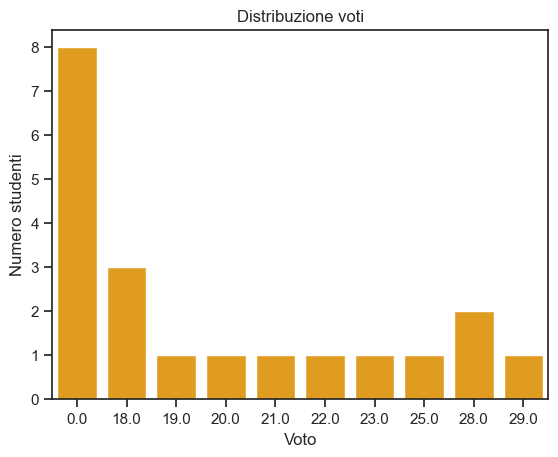

In [21]:

sns.set_theme(style="ticks")
voti_validi = voti_num.dropna()
conteggio = voti_validi.value_counts().sort_index()
conteggio = voti_validi.value_counts().sort_index()

sns.barplot(
    x=conteggio.index,
    y=conteggio.values,
    color="orange"
)

plt.title("Distribuzione voti")
plt.xlabel("Voto")
plt.ylabel("Numero studenti")

plt.show()

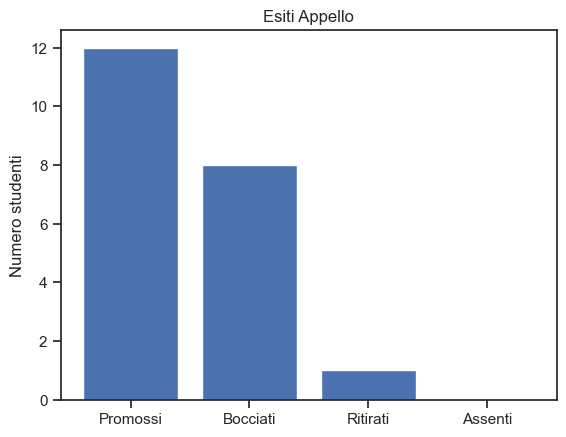

In [22]:
assenti = (serie == "ASS").sum()
ritirati = (serie == "RIT").sum()
promossi = (voti_num >= 18).sum()
bocciati = (voti_num < 18).sum()
categorie = ["Promossi", "Bocciati", "Ritirati", "Assenti"]
valori = [promossi, bocciati, ritirati, assenti]
plt.bar(categorie, valori)
plt.title("Esiti Appello")
plt.ylabel("Numero studenti")

plt.show()

C:\Users\alice\AppData\Local\Temp\ipykernel_31444\708949453.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


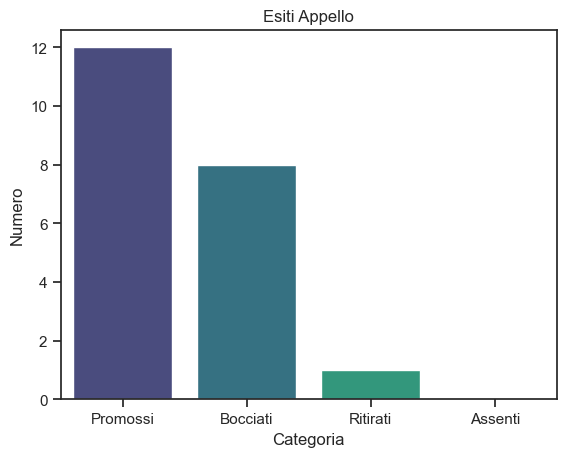

In [23]:
dati = pd.DataFrame({
    "Categoria": ["Promossi", "Bocciati", "Ritirati", "Assenti"],
    "Numero": [promossi, bocciati, ritirati, assenti]
})
sns.barplot(
    data=dati,
    x="Categoria",
    y="Numero",
    palette="viridis"
)

plt.title("Esiti Appello")

plt.show()

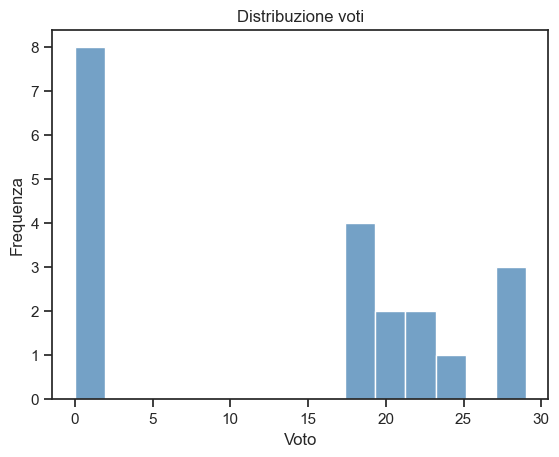

In [24]:
sns.histplot(voti_validi, bins=15, color="steelblue")

plt.title("Distribuzione voti")
plt.xlabel("Voto")
plt.ylabel("Frequenza")

plt.show()

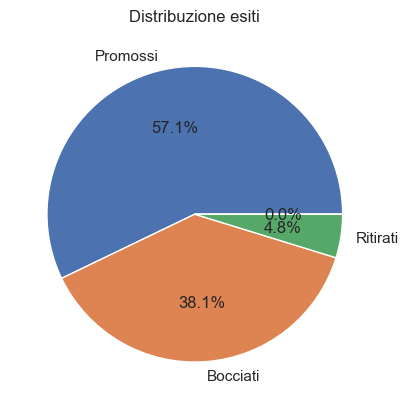

In [41]:
dati = pd.Series({
    "Promossi": promossi,
    "Bocciati": bocciati,
    "Ritirati": ritirati,
    "Assenti": assenti
})

dati.plot(kind="pie", autopct="%1.1f%%")

plt.title("Distribuzione esiti")
plt.ylabel("")
plt.show()

## Statistiche per appelli complessivi

In [26]:
lista_voti_appelli = []
nomi_appelli = []

for f in files:
    # ricava la chiave corta tipo "C1", "C2"
    key = f.split("(")[1].split(")")[0]
    
    df_voti = appelli[key]["voti"]
    
    # pulizia colonna Esito
    serie = df_voti["Esito"].astype(str).str.strip()
    serie = serie.replace("30L", 31)  # 30L → 31
    
    voti_num = pd.to_numeric(serie, errors="coerce").dropna()  # solo numeri
    
    lista_voti_appelli.append(voti_num)
    nomi_appelli.append(key)

In [29]:

files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
    "Esempio_Appello (C3).xlsx"
]

# 1️⃣ Caricamento dati
appelli = {}

for f in files:
    key = f.split("(")[1].split(")")[0]  # C1, C2, ...
    
    df_raw = pd.read_excel(f, header=None)
    inf = df_raw.iloc[:18]
    voti = pd.read_excel(f, header=20)
    voti.columns = voti.columns.str.strip()  # pulizia colonne
    
    appelli[key] = {
        "inf": inf,
        "voti": voti
    }

# 2️⃣ Analisi e preparazione dati per grafico

lista_voti_appelli = []
nomi_appelli = []

for key in appelli.keys():
    print(f"Caricando appello {key}")
    df_voti = appelli[key]["voti"]
    serie = df_voti["Esito"].astype(str).str.strip()
    serie = serie.replace("30L", 31)
    
    voti_num = pd.to_numeric(serie, errors="coerce").dropna()
    print(f"Numero voti per {key}: {len(voti_num)}")
    
    lista_voti_appelli.append(voti_num)
    nomi_appelli.append(key)
    print(f"Appello {key} - voti validi: {len(voti_num)}")

Caricando appello C1
Numero voti per C1: 15
Appello C1 - voti validi: 15
Caricando appello C2
Numero voti per C2: 13
Appello C2 - voti validi: 13
Caricando appello C3
Numero voti per C3: 20
Appello C3 - voti validi: 20


In [33]:
print(appelli.keys())
lista_voti_appelli = []
nomi_appelli = []

for key in appelli.keys():
    print(f"Caricando appello {key}")
    df_voti = appelli[key]["voti"]
    serie = df_voti["Esito"].astype(str).str.strip()
    serie = serie.replace("30L", 31)
    
    voti_num = pd.to_numeric(serie, errors="coerce").dropna()
    
    print(f"Numero voti per {key}: {len(voti_num)}")
    
    lista_voti_appelli.append(voti_num)
    nomi_appelli.append(key)
    for f in files:
        key = f.split("(")[1].split(")")[0]
        df_raw = pd.read_excel(f, header=None)
        inf = df_raw.iloc[:18]
        voti = pd.read_excel(f, header=20)
        voti.columns = voti.columns.str.strip()  # pulizia nomi colonne

    appelli[key] = {
        "inf": inf,
        "voti": voti
    }

dict_keys(['C1', 'C2', 'C3'])
Caricando appello C1
Numero voti per C1: 15
Caricando appello C2
Numero voti per C2: 13
Caricando appello C3
Numero voti per C3: 20


<Axes: >

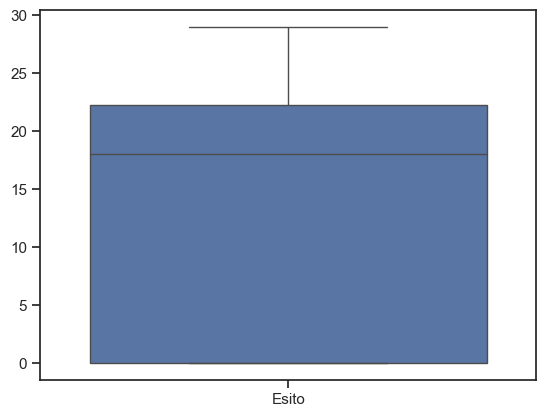

In [18]:
sns.boxplot(data=lista_voti_appelli)


Caricando appello C1
Numero voti trovati: 15

Caricando appello C2
Numero voti trovati: 13

Caricando appello C3
Numero voti trovati: 20


C:\Users\alice\AppData\Local\Temp\ipykernel_31444\1161499701.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


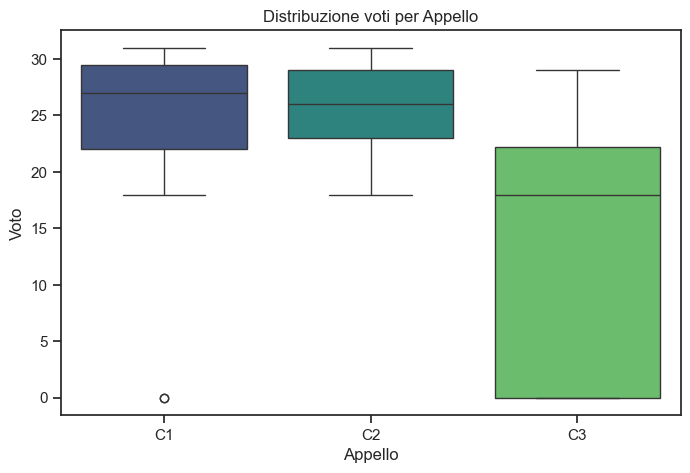

In [35]:
dati = []

for key in appelli:

    print(f"\nCaricando appello {key}")
    
    df_voti = appelli[key]["voti"]

    if "esito" not in df_voti.columns:
        print("Colonna 'esito' non trovata")
        continue

    serie = df_voti["esito"].astype(str).str.strip()

    serie = serie.replace("30L", 31)

    voti_num = pd.to_numeric(serie, errors="coerce").dropna()

    print(f"Numero voti trovati: {len(voti_num)}")

    for voto in voti_num:
        dati.append({
            "Appello": key,
            "Voto": voto
        })


df_finale = pd.DataFrame(dati)

# grafico
sns.set_theme(style="ticks")

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_finale,
    x="Appello",
    y="Voto",
    palette="viridis"
)

plt.title("Distribuzione voti per Appello")

plt.show()

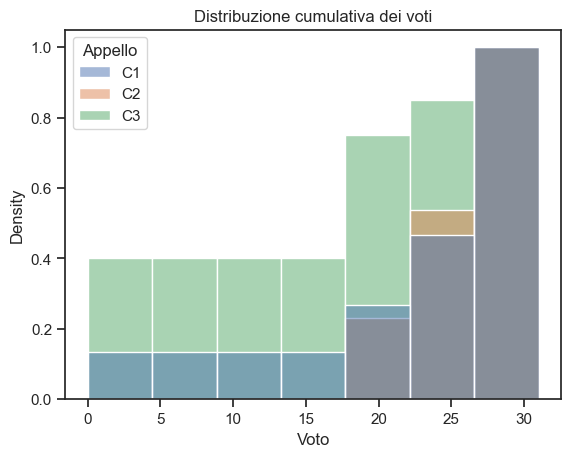

In [21]:
sns.histplot(
    data=df_finale,
    x="Voto",
    hue="Appello",
    cumulative=True,
    stat="density",
    common_norm=False
)

plt.title("Distribuzione cumulativa dei voti")
plt.show()

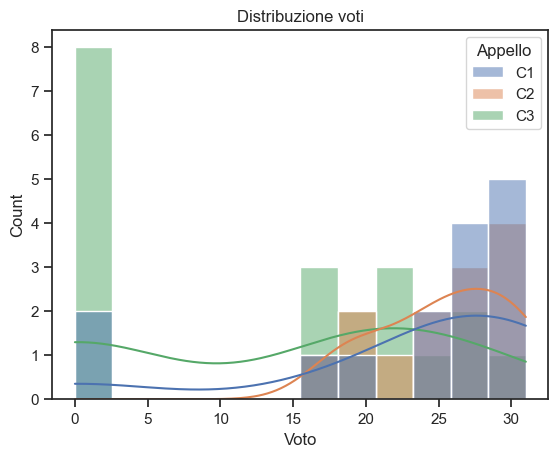

In [22]:
sns.histplot(
    data=df_finale,
    x="Voto",
    hue="Appello",
    bins=12,
    kde=True
)

plt.title("Distribuzione voti")
plt.show()

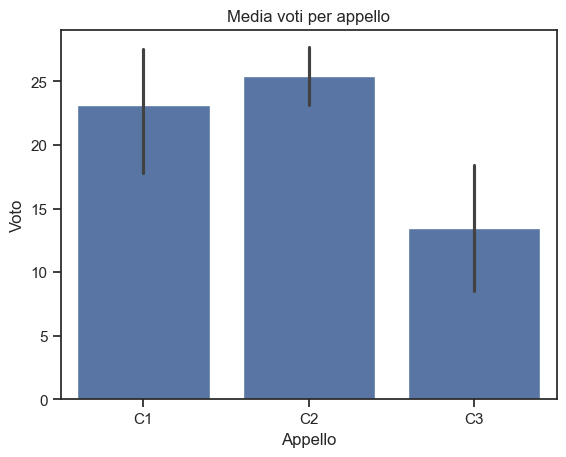

In [23]:
sns.barplot(
    data=df_finale,
    x="Appello",
    y="Voto"
)

plt.title("Media voti per appello")
plt.show()

## Algoritmo per individuazione del genere
Prova di varie librerie

In [24]:
%pip install names-dataset
%pip install genderize
%pip install gender_guesser.dedector

Note: you may need to restart the kernel to use updated packages.

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement gender_guesser.dedector (from versions: none)
ERROR: No matching distribution found for gender_guesser.dedector


In [ ]:
from genderize import Genderize

Genderize().get(["Giulia","Marco"])

[{'count': 252065, 'name': 'Giulia', 'gender': 'female', 'probability': 0.99},
 {'count': 1342963, 'name': 'Marco', 'gender': 'male', 'probability': 1.0}]

In [ ]:
from names_dataset import NameDataset

nd = NameDataset()

nd.search("Giulia")

{'first_name': {'country': {'Belgium': 0.002,
   'Brazil': 0.005,
   'Switzerland': 0.003,
   'Germany': 0.002,
   'Spain': 0.001,
   'France': 0.005,
   'United Kingdom': 0.003,
   'Italy': 0.974,
   'Netherlands': 0.001,
   'United States': 0.003},
  'gender': {'Female': 0.994, 'Male': 0.006},
  'rank': {'Belgium': 982,
   'Brazil': 1015,
   'Switzerland': 229,
   'Germany': 1116,
   'Spain': 2390,
   'France': 1831,
   'United Kingdom': 1358,
   'Italy': 32,
   'Netherlands': 1849,
   'United States': 4933}},
 'last_name': {'country': {'Belgium': 0.011,
   'Brazil': 0.009,
   'Switzerland': 0.006,
   'Germany': 0.009,
   'Spain': 0.005,
   'France': 0.045,
   'United Kingdom': 0.006,
   'Italy': 0.902,
   'Netherlands': 0.003,
   'United States': 0.005},
  'gender': {},
  'rank': {'Belgium': 12415,
   'Brazil': 11183,
   'Switzerland': 8504,
   'France': 17052,
   'Italy': 1563,
   'Germany': None,
   'Spain': None,
   'United Kingdom': None,
   'Netherlands': None,
   'United State

## Prove con gender guesser


Conteggio generi totali:
Genere
M    55
Name: count, dtype: int64


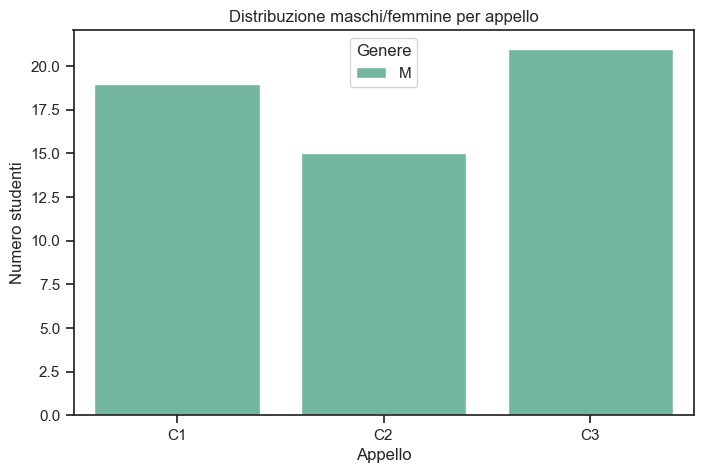

In [ ]:

detector = gender.Detector()
sns.set_theme(style="ticks")

# Lista dei file Excel (modifica se vuoi aggiungere altri appelli)
files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
     "Esempio_Appello (C3).xlsx"
]

# Preparazione dataframe cumulativo
dati = []

for f in files:
    # ricava il nome appello (C1, C2...)
    key = f.split("(")[1].split(")")[0]
    
    # legge solo la colonna E (Nome) a partire da riga 19
    df = pd.read_excel(
        f,
        usecols="E",     # colonna E
        skiprows=20,     # salta prime 18 righe
        names=["Nome"]   # rinomina colonna
    )
    
    # funzione robusta per stimare il genere
    def stima_genere(nome_completo):
        if not isinstance(nome_completo, str) or nome_completo.strip() == "":
            return "?"
        
        # pulizia: rimuove spazi e caratteri strani
        nome = nome_completo.strip().split()[0]              # primo nome
        nome = re.sub(r"[^A-Za-zÀ-ÖØ-öø-ÿ]", "", nome)      # solo lettere
        nome = nome.capitalize()                             # capitalizza
        
        g = detector.get_gender(nome)
        if "male" in g:
            return "M"
        elif "female" in g:
            return "F"
        else:
            return "?"
    
    df["Genere"] = df["Nome"].apply(stima_genere)
    df["Appello"] = key  # aggiunge colonna appello
    
    dati.append(df)

# unisce tutti gli appelli
df_finale = pd.concat(dati, ignore_index=True)

# 5Conteggio maschi/femmine totali
print("Conteggio generi totali:")
print(df_finale["Genere"].value_counts())

# Grafico maschi/femmine per appello
plt.figure(figsize=(8,5))
sns.countplot(data=df_finale, x="Appello", hue="Genere", palette="Set2")
plt.title("Distribuzione maschi/femmine per appello")
plt.ylabel("Numero studenti")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from genderize import Genderize
import gender_guesser
import gender_guesser.detector as gender
import re


          Nome   Nome_norm Appello        name  gender  probability Genere
0       MATTEO      Matteo      C1      Matteo    male         1.00      M
1         LUCA        Luca      C1        Luca    male         0.97      M
2     GIOVANNI    Giovanni      C1    Giovanni    male         0.99      M
3       ANDREA      Andrea      C1      Andrea  female         0.69      F
4      ALESSIA     Alessia      C1     Alessia  female         0.99      F
5   ALESSANDRO  Alessandro      C1  Alessandro    male         1.00      M
6         CIRO        Ciro      C1        Ciro    male         0.99      M
7     FEDERICO    Federico      C1    Federico    male         1.00      M
8        LUCIA       Lucia      C1       Lucia  female         0.99      F
9        ALICE       Alice      C1       Alice  female         0.99      F
10      BIANCA      Bianca      C1      Bianca  female         0.99      F
11     LORENZO     Lorenzo      C1     Lorenzo    male         1.00      M
12    EMANUELE    Emanuel

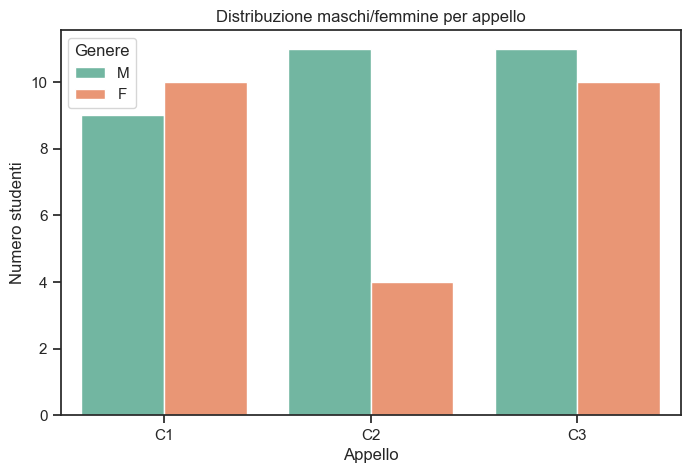

In [45]:

sns.set_theme(style="ticks")
# Funzione helper per normalizzare i nomi
def normalize_name(nome):
    if not isinstance(nome, str) or nome.strip() == "":
        return ""
    nome = nome.strip().split()[0]  # prende primo nome
    # rimuove caratteri non alfabetici
    nome = re.sub(r"[^A-Za-zÀ-ÖØ-öø-ÿ]", "", nome)
    # capitalizza solo la prima lettera
    return nome.capitalize()

# 4Lista dei file Excel
files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
    "Esempio_Appello (C3).xlsx"
    # aggiungi qui altri appelli se ci sono
]

# Prepara dataset finale
df_finale = pd.DataFrame()

for f in files:
    key = f.split("(")[1].split(")")[0]
    
    # legge colonna E a partire da riga 19
    df = pd.read_excel(
        f,
        usecols="E",
        skiprows=20,
        names=["Nome"]
    )
    
    # normalizza i nomi
    df["Nome_norm"] = df["Nome"].apply(normalize_name)
    
    # salva appello
    df["Appello"] = key
    df_finale = pd.concat([df_finale, df], ignore_index=True)

# Chiama l'API Genderize per tutti i nomi unici
nomi_unici = list(df_finale["Nome_norm"].dropna().unique())
# rimuove stringhe vuote
nomi_unici = [n for n in nomi_unici if n != ""]

gender_results = Genderize().get(nomi_unici)

# trasforma in DataFrame
df_gender = pd.DataFrame(gender_results)

# Associa il genere stimato al dataset
df_finale = df_finale.merge(
    df_gender[["name","gender","probability"]],
    left_on="Nome_norm",
    right_on="name",
    how="left"
)

#pulisce e mappa genere
df_finale["Genere"] = df_finale["gender"].map({
    "male": "M",
    "female": "F"
}).fillna("?")

# Mostra un’anteprima
print(df_finale.head(15))

# Conteggio generi
print("\nConteggio generi totali:")
print(df_finale["Genere"].value_counts())

#Grafico maschi/femmine per appello
plt.figure(figsize=(8,5))
sns.countplot(data=df_finale, x="Appello", hue="Genere", palette="Set2")
plt.title("Distribuzione maschi/femmine per appello")
plt.ylabel("Numero studenti")
plt.show()

In [48]:


# 2️⃣ Import librerie
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from genderize import Genderize

sns.set_theme(style="ticks")

# 3️⃣ Funzione per normalizzare i nomi
def normalize_name(nome):
    if not isinstance(nome, str) or nome.strip() == "":
        return ""
    nome = nome.strip().split()[0]
    nome = re.sub(r"[^A-Za-zÀ-ÖØ-öø-ÿ]", "", nome)
    return nome.capitalize()

# 4️⃣ Lista dei file Excel
files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
    "Esempio_Appello (C3).xlsx"
    # aggiungi altri appelli se ci sono
]

# 5️⃣ Preparazione dataset cumulativo
df_finale = pd.DataFrame()

for f in files:
    key = f.split("(")[1].split(")")[0]
    
    # legge colonne E (Nome) e H (Esito) a partire dalla riga 21
    df = pd.read_excel(
        f,
        usecols="E,i",    # colonne Nome e Esito
        skiprows=20,      # salta prime 20 righe
        names=["Nome", "Esito"]
    )
    
    # normalizza i nomi
    df["Nome_norm"] = df["Nome"].apply(normalize_name)
    
    # aggiunge colonna appello
    df["Appello"] = key
    
    df_finale = pd.concat([df_finale, df], ignore_index=True)

# 6️⃣ Genderize su tutti i nomi unici
nomi_unici = list(df_finale["Nome_norm"].dropna().unique())
nomi_unici = [n for n in nomi_unici if n != ""]

gender_results = Genderize().get(nomi_unici)
df_gender = pd.DataFrame(gender_results)

# 7️⃣ Associa genere al dataset
df_finale = df_finale.merge(
    df_gender[["name","gender","probability"]],
    left_on="Nome_norm",
    right_on="name",
    how="left"
)

df_finale["Genere"] = df_finale["gender"].map({
    "male": "M",
    "female": "F"
}).fillna("?")

# 8️⃣ Normalizza Esito in numerico
df_finale["Voto"] = pd.to_numeric(df_finale["Esito"], errors="coerce")

# Promosso = voto >=18, Bocciato = voto <18
df_finale["Esito_promozione"] = df_finale["Voto"].apply(lambda x: "Promosso" if x >= 18 else ("Bocciato" if not pd.isna(x) else "?"))

# 9️⃣ Conteggio maschi/femmine per esito
conteggio = df_finale.groupby(["Genere","Esito_promozione"]).size().unstack(fill_value=0)
print("Conteggio maschi/femmine per esito:")
print(conteggio)

# 10️⃣ Grafico maschi/femmine Promossi/Bocciati
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_finale[df_finale["Esito_promozione"]!="?"],
    x="Esito_promozione",
    hue="Genere",
    palette="Set2"
)
plt.title("Promossi e bocciati per genere")
plt.ylabel("Numero studenti")
plt.show()

GenderizeException: ('Request limit too low to process request', 429, {'Server': 'nginx/1.16.1', 'Date': 'Thu, 19 Mar 2026 10:53:07 GMT', 'Content-Type': 'application/json', 'Content-Length': '52', 'Connection': 'keep-alive', 'vary': 'accept-encoding', 'cache-control': 'max-age=0, private, must-revalidate', 'x-request-id': 'GJ44pZWexPi7gL0G9LXD', 'access-control-allow-credentials': 'true', 'access-control-allow-origin': '*', 'access-control-expose-headers': 'x-rate-limit-limit,x-rate-limit-remaining,x-rate-limit-reset', 'x-rate-limit-limit': '100', 'x-rate-limit-remaining': '2', 'x-rate-limit-reset': '47213'})

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Assumiamo df_finale già pronto con colonne:
# Nome, Nome_norm, Genere, Esito, Voto, Esito_promozione, Appello

# Filtra solo i valori validi
df_plot = df_finale[df_finale["Esito_promozione"].isin(["Promosso", "Bocciato"])]

# 2️⃣ Conta numero totale di maschi e femmine per appello
totali_appello = df_plot.groupby(["Appello","Genere"]).size().reset_index(name="Totale_genere")

# 3️⃣ Conta promossi/bocciati per genere e appello
conteggio = df_plot.groupby(["Appello","Genere","Esito_promozione"]).size().reset_index(name="Count")

# 4️⃣ Unisce totali per calcolare percentuale
df_plot_norm = conteggio.merge(totali_appello, on=["Appello","Genere"])
df_plot_norm["Percentuale"] = df_plot_norm["Count"] / df_plot_norm["Totale_genere"] * 100

# 5️⃣ Grafico percentuale
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_plot_norm,
    x="Appello",
    y="Percentuale",
    hue="Genere",
    ci=None,
    palette="Set2"
)

plt.title("Percentuale maschi/femmine promossi e bocciati per appello")
plt.ylabel("Percentuale (%)")
plt.xlabel("Appello")
plt.legend(title="Genere")
plt.show()

KeyError: 'Esito_promozione'

C:\Users\alice\AppData\Local\Temp\ipykernel_24120\512313244.py:79: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


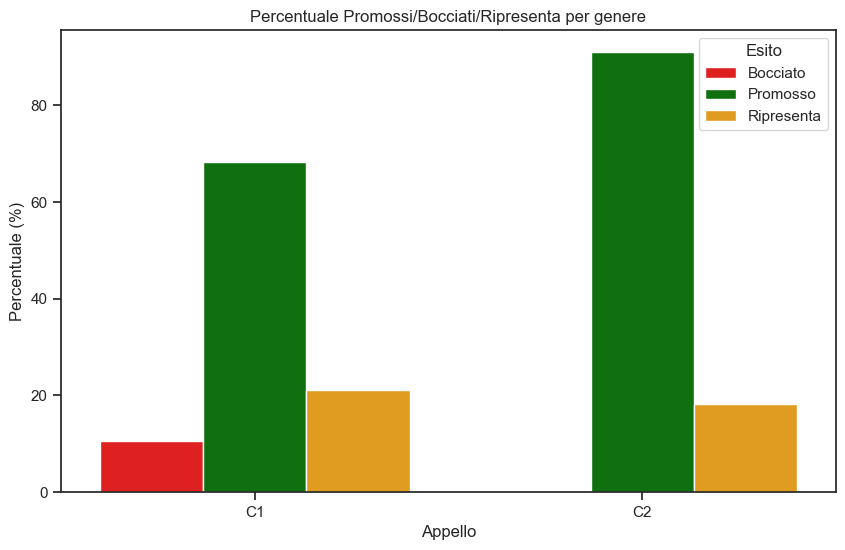

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from genderize import Genderize

sns.set_theme(style="ticks")

# Funzione normalizza nomi
def normalize_name(nome):
    if not isinstance(nome, str) or nome.strip() == "":
        return ""
    nome = nome.strip().split()[0]
    nome = re.sub(r"[^A-Za-zÀ-ÖØ-öø-ÿ]", "", nome)
    return nome.capitalize()

# Lista file Excel
files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
]

df_finale = pd.DataFrame()

for f in files:
    key = f.split("(")[1].split(")")[0]
    
    # Legge colonne E (Nome) e H (Esito)
    df = pd.read_excel(f, usecols="E,i", skiprows=20, names=["Nome","Esito"])
    
    df["Nome_norm"] = df["Nome"].apply(normalize_name)
    df["Appello"] = key
    
    df_finale = pd.concat([df_finale, df], ignore_index=True)

# Genderize su nomi unici
nomi_unici = [n for n in df_finale["Nome_norm"].dropna().unique() if n != ""]
gender_results = Genderize().get(nomi_unici)
df_gender = pd.DataFrame(gender_results)

df_finale = df_finale.merge(
    df_gender[["name","gender","probability"]],
    left_on="Nome_norm",
    right_on="name",
    how="left"
)
df_finale["Genere"] = df_finale["gender"].map({"male":"M","female":"F"}).fillna("?")

# Normalizza Esito
df_finale["Esito_num"] = df_finale["Esito"].astype(str).str.strip().replace("30L","31")
df_finale["Voto"] = pd.to_numeric(df_finale["Esito_num"], errors="coerce")

# Definisce esito promozione
def esito_finale(v):
    if pd.isna(v):
        return "Ripresenta"  # chi non ha voti o rifiuta
    elif v >= 18:
        return "Promosso"
    else:
        return "Bocciato"

df_finale["Esito_promozione"] = df_finale["Voto"].apply(esito_finale)

# Percentuale maschi/femmine per esito
df_plot = df_finale[df_finale["Esito_promozione"].isin(["Promosso","Bocciato","Ripresenta"])]

# Totale iscritti per genere e appello
totali_appello = df_plot.groupby(["Appello","Genere"]).size().reset_index(name="Totale_genere")

# Conteggio esiti per genere e appello
conteggio = df_plot.groupby(["Appello","Genere","Esito_promozione"]).size().reset_index(name="Count")

# Merge per percentuale
df_plot_norm = conteggio.merge(totali_appello, on=["Appello","Genere"])
df_plot_norm["Percentuale"] = df_plot_norm["Count"] / df_plot_norm["Totale_genere"] * 100

# Grafico stacked percentuale
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_plot_norm,
    x="Appello",
    y="Percentuale",
    hue="Esito_promozione",
    ci=None,
    palette={"Promosso":"green","Bocciato":"red","Ripresenta":"orange"}
)
plt.title("Percentuale Promossi/Bocciati/Ripresenta per genere")
plt.ylabel("Percentuale (%)")
plt.xlabel("Appello")
plt.legend(title="Esito")
plt.show()

In [50]:
# 1️⃣ Installazione libreria
try:
    from genderize import Genderize
except ImportError:
    %pip install genderize

# 2️⃣ Import librerie
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from genderize import Genderize

sns.set_theme(style="ticks")

# 3️⃣ Inserisci qui la tua API key di Genderize
GENDERIZE_API_KEY = "1b9b277c71374cfb9ecb9383ee5abbbd"

detector = Genderize(api_key=GENDERIZE_API_KEY)

# 4️⃣ Funzione per normalizzare i nomi
def normalize_name(nome):
    if not isinstance(nome, str) or nome.strip() == "":
        return ""
    nome = nome.strip().split()[0]                 # prende primo nome
    nome = re.sub(r"[^A-Za-zÀ-ÖØ-öø-ÿ]", "", nome) # rimuove caratteri strani
    return nome.capitalize()

# 5️⃣ Lista file Excel
files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
    "Esempio_Appello (C3).xlsx"
    # aggiungi altri appelli se necessario
]

# 6️⃣ Caricamento dati
df_finale = pd.DataFrame()

for f in files:
    key = f.split("(")[1].split(")")[0]
    
    # legge colonne Nome (E) e Esito (H) a partire dalla riga 21
    df = pd.read_excel(f, usecols="E,i", skiprows=20, names=["Nome","Esito"])
    
    df["Nome_norm"] = df["Nome"].apply(normalize_name)
    df["Appello"] = key
    
    df_finale = pd.concat([df_finale, df], ignore_index=True)

# 7️⃣ Genderize su nomi unici in batch da 10
nomi_unici = [n for n in df_finale["Nome_norm"].dropna().unique() if n != ""]
results = []

batch_size = 10
for i in range(0, len(nomi_unici), batch_size):
    batch = nomi_unici[i:i+batch_size]
    res = detector.get(batch)
    results.extend(res)

df_gender = pd.DataFrame(results)

# 8️⃣ Associa genere al dataset
df_finale = df_finale.merge(
    df_gender[["name","gender","probability"]],
    left_on="Nome_norm",
    right_on="name",
    how="left"
)

df_finale["Genere"] = df_finale["gender"].map({"male":"M","female":"F"}).fillna("?")

# 9️⃣ Normalizza Esito
df_finale["Esito_num"] = df_finale["Esito"].astype(str).str.strip().replace("30L","31")
df_finale["Voto"] = pd.to_numeric(df_finale["Esito_num"], errors="coerce")

# 10️⃣ Definizione esito finale: Promosso, Bocciato, Ripresenta
def esito_finale(v):
    if pd.isna(v):
        return "Ripresenta"
    elif v >= 18:
        return "Promosso"
    else:
        return "Bocciato"

df_finale["Esito_promozione"] = df_finale["Voto"].apply(esito_finale)

# 11️⃣ Percentuali maschi/femmine per esito e appello
df_plot = df_finale[df_finale["Esito_promozione"].isin(["Promosso","Bocciato","Ripresenta"])]

# Totale iscritti per genere e appello
totali_appello = df_plot.groupby(["Appello","Genere"]).size().reset_index(name="Totale_genere")

# Conteggio esiti per genere e appello
conteggio = df_plot.groupby(["Appello","Genere","Esito_promozione"]).size().reset_index(name="Count")

# Merge per percentuale
df_plot_norm = conteggio.merge(totali_appello, on=["Appello","Genere"])
df_plot_norm["Percentuale"] = df_plot_norm["Count"] / df_plot_norm["Totale_genere"] * 100

# 12️⃣ Grafico stacked percentuale
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_plot_norm,
    x="Appello",
    y="Percentuale",
    hue="Esito_promozione",
    ci=None,
    palette={"Promosso":"green","Bocciato":"red","Ripresenta":"orange"}
)
plt.title("Percentuale Promossi/Bocciati/Ripresenta per genere")
plt.ylabel("Percentuale (%)")
plt.xlabel("Appello")
plt.legend(title="Esito")
plt.show()

GenderizeException: ('No active subscription', 402, {'Server': 'nginx/1.16.1', 'Date': 'Tue, 17 Mar 2026 09:41:52 GMT', 'Content-Type': 'application/json', 'Content-Length': '34', 'Connection': 'keep-alive', 'vary': 'accept-encoding', 'cache-control': 'max-age=0, private, must-revalidate', 'x-request-id': 'GJ2XmTn4hlxvabK4awsC', 'access-control-allow-credentials': 'true', 'access-control-allow-origin': '*', 'access-control-expose-headers': 'x-rate-limit-limit,x-rate-limit-remaining,x-rate-limit-reset'})

C:\Users\alice\AppData\Local\Temp\ipykernel_24120\2530127687.py:72: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


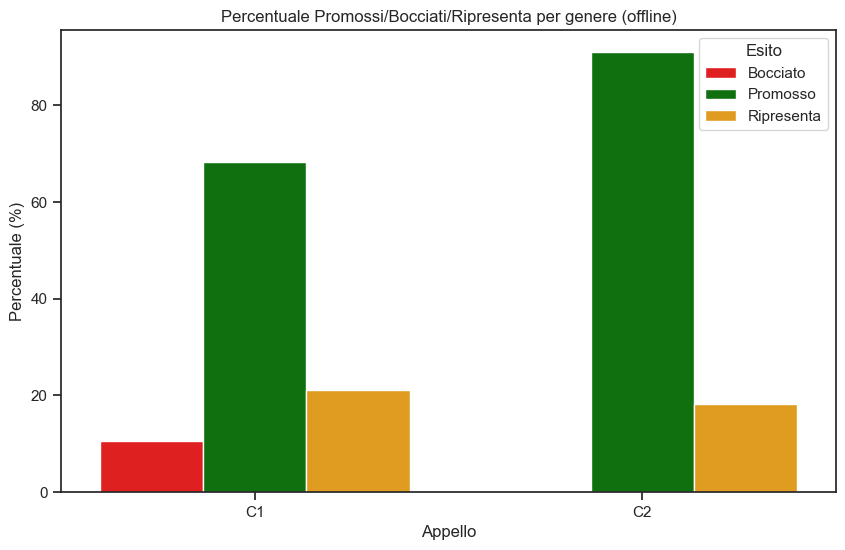

In [49]:
# 1️⃣ Installazione gender-guesser
try:
    import gender_guesser.detector as gender
except ImportError:
    %pip install gender-guesser

# 2️⃣ Import
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

sns.set_theme(style="ticks")

# 3️⃣ Normalizzazione nomi
def normalize_name(nome):
    if not isinstance(nome, str) or nome.strip() == "":
        return ""
    nome = nome.strip().split()[0]
    nome = re.sub(r"[^A-Za-zÀ-ÖØ-öø-ÿ]", "", nome)
    return nome.capitalize()

# 4️⃣ Lista dei file
files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
    # aggiungi altri appelli
]

# 5️⃣ Caricamento dati
df_finale = pd.DataFrame()

for f in files:
    key = f.split("(")[1].split(")")[0]
    df = pd.read_excel(f, usecols="E,i", skiprows=20, names=["Nome","Esito"])
    df["Nome_norm"] = df["Nome"].apply(normalize_name)
    df["Appello"] = key
    df_finale = pd.concat([df_finale, df], ignore_index=True)

# 6️⃣ Stima genere con gender-guesser
d = gender.Detector(case_sensitive=False)
df_finale["Genere"] = df_finale["Nome_norm"].apply(lambda x: 
    "M" if d.get_gender(x) in ["male","mostly_male"] else 
    ("F" if d.get_gender(x) in ["female","mostly_female"] else "?")
)

# 7️⃣ Normalizza Esito
df_finale["Esito_num"] = df_finale["Esito"].astype(str).str.strip().replace("30L","31")
df_finale["Voto"] = pd.to_numeric(df_finale["Esito_num"], errors="coerce")

# 8️⃣ Definisce esito finale
def esito_finale(v):
    if pd.isna(v):
        return "Ripresenta"
    elif v >= 18:
        return "Promosso"
    else:
        return "Bocciato"

df_finale["Esito_promozione"] = df_finale["Voto"].apply(esito_finale)

# 9️⃣ Percentuali maschi/femmine per esito e appello
df_plot = df_finale[df_finale["Esito_promozione"].isin(["Promosso","Bocciato","Ripresenta"])]

totali_appello = df_plot.groupby(["Appello","Genere"]).size().reset_index(name="Totale_genere")
conteggio = df_plot.groupby(["Appello","Genere","Esito_promozione"]).size().reset_index(name="Count")
df_plot_norm = conteggio.merge(totali_appello, on=["Appello","Genere"])
df_plot_norm["Percentuale"] = df_plot_norm["Count"] / df_plot_norm["Totale_genere"] * 100

# 10️⃣ Grafico stacked percentuale
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_plot_norm,
    x="Appello",
    y="Percentuale",
    hue="Esito_promozione",
    ci=None,
    palette={"Promosso":"green","Bocciato":"red","Ripresenta":"orange"}
)
plt.title("Percentuale Promossi/Bocciati/Ripresenta per genere (offline)")
plt.ylabel("Percentuale (%)")
plt.xlabel("Appello")
plt.legend(title="Esito")
plt.show()

C:\Users\alice\AppData\Local\Temp\ipykernel_24120\2712600249.py:68: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


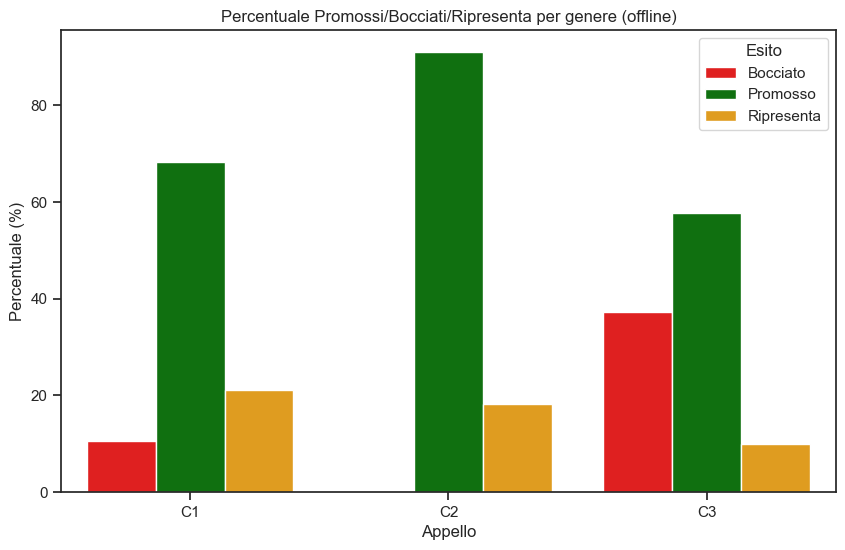

In [46]:
# 1️⃣ Import librerie
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import gender_guesser.detector as gender

sns.set_theme(style="ticks")

# 2️⃣ Funzione per normalizzare i nomi
def normalize_name(nome):
    if not isinstance(nome, str) or nome.strip() == "":
        return ""
    nome = nome.strip().split()[0]                 # prende primo nome
    nome = re.sub(r"[^A-Za-zÀ-ÖØ-öø-ÿ]", "", nome) # rimuove caratteri strani
    return nome.capitalize()

# 3️⃣ Lista dei file
files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
    "Esempio_Appello (C3).xlsx"
    # aggiungi altri appelli se necessario
]

# 4️⃣ Caricamento dati
df_finale = pd.DataFrame()
for f in files:
    key = f.split("(")[1].split(")")[0]
    df = pd.read_excel(f, usecols="E,i", skiprows=20, names=["Nome","Esito"])
    df["Nome_norm"] = df["Nome"].apply(normalize_name)
    df["Appello"] = key
    df_finale = pd.concat([df_finale, df], ignore_index=True)

# 5️⃣ Stima genere con gender-guesser
d = gender.Detector(case_sensitive=False)
df_finale["Genere"] = df_finale["Nome_norm"].apply(lambda x: 
    "M" if d.get_gender(x) in ["male","mostly_male"] else 
    ("F" if d.get_gender(x) in ["female","mostly_female"] else "?")
)

# 6️⃣ Normalizza Esito
df_finale["Esito_str"] = df_finale["Esito"].astype(str).str.strip()
df_finale["Esito_str"] = df_finale["Esito_str"].replace("30L","31")
df_finale["Voto"] = pd.to_numeric(df_finale["Esito_str"], errors="coerce")

# 7️⃣ Definizione esito finale
def esito_finale(v):
    if pd.isna(v):
        return "Ripresenta"  # voti vuoti o rifiutati
    elif v >= 18:
        return "Promosso"
    else:
        return "Bocciato"

df_finale["Esito_promozione"] = df_finale["Voto"].apply(esito_finale)

# 8️⃣ Percentuali maschi/femmine per esito e appello
df_plot = df_finale[df_finale["Esito_promozione"].isin(["Promosso","Bocciato","Ripresenta"])]

totali_appello = df_plot.groupby(["Appello","Genere"]).size().reset_index(name="Totale_genere")
conteggio = df_plot.groupby(["Appello","Genere","Esito_promozione"]).size().reset_index(name="Count")
df_plot_norm = conteggio.merge(totali_appello, on=["Appello","Genere"])
df_plot_norm["Percentuale"] = df_plot_norm["Count"] / df_plot_norm["Totale_genere"] * 100

# 9️⃣ Grafico stacked percentuale
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_plot_norm,
    x="Appello",
    y="Percentuale",
    hue="Esito_promozione",
    ci=None,
    palette={"Promosso":"green","Bocciato":"red","Ripresenta":"orange"}
)
plt.title("Percentuale Promossi/Bocciati/Ripresenta per genere (offline)")
plt.ylabel("Percentuale (%)")
plt.xlabel("Appello")
plt.legend(title="Esito")
plt.show()

C:\Users\alice\AppData\Local\Temp\ipykernel_24120\1043588270.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


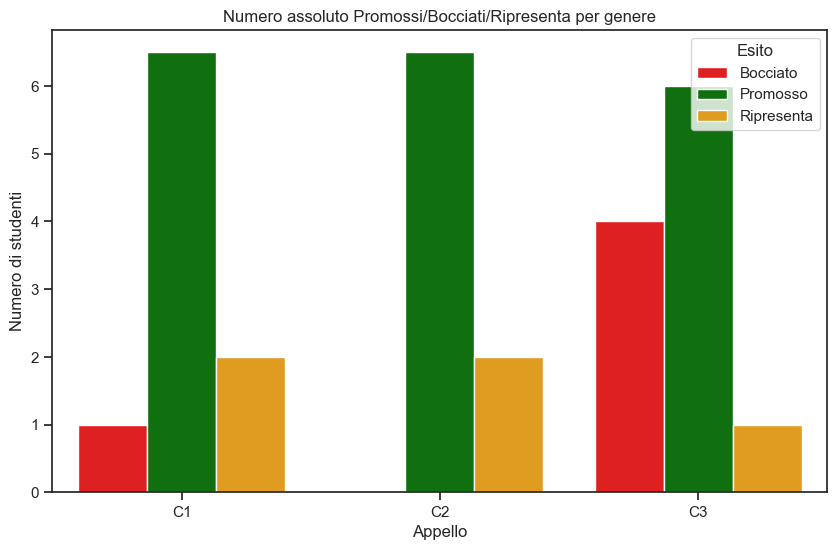

In [47]:
# 1️⃣ Calcolo conteggi assoluti
df_plot = df_finale[df_finale["Esito_promozione"].isin(["Promosso","Bocciato","Ripresenta"])]

# Conteggio assoluto per genere e appello
conteggio_assoluto = df_plot.groupby(["Appello","Genere","Esito_promozione"]).size().reset_index(name="Count")

# 2️⃣ Grafico stacked con numeri assoluti
plt.figure(figsize=(10,6))
sns.barplot(
    data=conteggio_assoluto,
    x="Appello",
    y="Count",
    hue="Esito_promozione",
    ci=None,
    palette={"Promosso":"green","Bocciato":"red","Ripresenta":"orange"}
)
plt.title("Numero assoluto Promossi/Bocciati/Ripresenta per genere")
plt.ylabel("Numero di studenti")
plt.xlabel("Appello")
plt.legend(title="Esito")
plt.show()

C:\Users\alice\AppData\Local\Temp\ipykernel_24120\1489806926.py:36: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


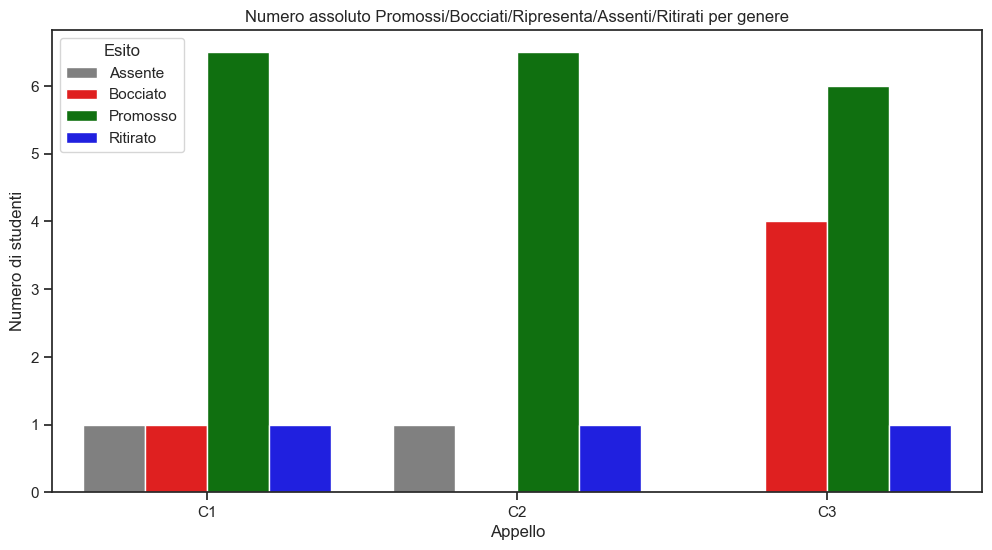

In [48]:
# 1️⃣ Conteggio assoluto considerando tutti i casi
def esito_finale(v):
    if pd.isna(v):
        return "Ripresenta"  # nel caso ci siano celle vuote
    elif isinstance(v, str):
        v = v.strip().upper()
        if v == "ASS":
            return "Assente"
        elif v == "RIT":
            return "Ritirato"
        elif v == "0":
            return "Bocciato"
        else:
            # prova a convertire in numero
            try:
                n = float(v.replace("30L","31"))
                return "Promosso" if n >= 18 else "Bocciato"
            except:
                return "Ripresenta"
    else:  # numerico
        return "Promosso" if v >= 18 else "Bocciato"

# Applica alla colonna Esito
df_finale["Esito_promozione"] = df_finale["Esito"].apply(esito_finale)

# 2️⃣ Conteggio assoluto per genere e appello
df_plot = df_finale[df_finale["Esito_promozione"].isin(
    ["Promosso","Bocciato","Ripresenta","Assente","Ritirato"]
)]

conteggio_assoluto = df_plot.groupby(["Appello","Genere","Esito_promozione"])\
    .size().reset_index(name="Count")

# 3️⃣ Grafico stacked con numeri assoluti
plt.figure(figsize=(12,6))
sns.barplot(
    data=conteggio_assoluto,
    x="Appello",
    y="Count",
    hue="Esito_promozione",
    ci=None,
    palette={"Promosso":"green","Bocciato":"red","Ripresenta":"orange",
             "Assente":"grey","Ritirato":"blue"}
)
plt.title("Numero assoluto Promossi/Bocciati/Ripresenta/Assenti/Ritirati per genere")
plt.ylabel("Numero di studenti")
plt.xlabel("Appello")
plt.legend(title="Esito")
plt.show()

C:\Users\alice\AppData\Local\Temp\ipykernel_24120\1555000658.py:87: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


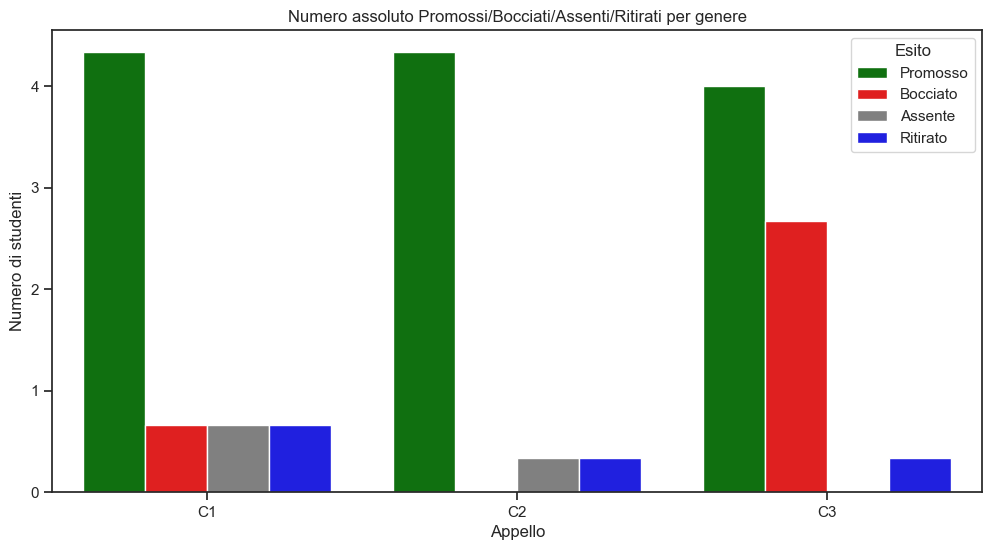

In [45]:
import itertools
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import gender_guesser.detector as gender

sns.set_theme(style="ticks")

# Funzione per normalizzare i nomi
def normalize_name(nome):
    if not isinstance(nome, str) or nome.strip() == "":
        return ""
    nome = nome.strip().split()[0]
    nome = re.sub(r"[^A-Za-zÀ-ÖØ-öø-ÿ]", "", nome)
    return nome.capitalize()

# Lista dei file
files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
    "Esempio_Appello (C3).xlsx",
    # aggiungi altri se vuoi
]

# Caricamento dati
df_finale = pd.DataFrame()
for f in files:
    key = f.split("(")[1].split(")")[0]
    df = pd.read_excel(f, usecols="E,i", skiprows=20, names=["Nome","Esito"])
    df["Nome_norm"] = df["Nome"].apply(normalize_name)
    df["Appello"] = key
    df_finale = pd.concat([df_finale, df], ignore_index=True)

# Stima genere
d = gender.Detector(case_sensitive=False)
df_finale["Genere"] = df_finale["Nome_norm"].apply(lambda x:
    "M" if d.get_gender(x) in ["male","mostly_male"] else
    ("F" if d.get_gender(x) in ["female","mostly_female"] else "?")
)

# Funzione per assegnare esito finale
def esito_finale(v):
    if isinstance(v, str):
        v = v.strip().upper()
        if v == "ASS":
            return "Assente"
        elif v == "RIT":
            return "Ritirato"
        elif v == "0":
            return "Bocciato"
        else:
            # prova a convertire in numero
            try:
                n = float(v.replace("30L","31"))
                return "Promosso" if n >= 18 else "Bocciato"
            except:
                return "Assente"  # se non riconosciamo consideriamo assente
    else:
        if pd.isna(v):
            return "Assente"
        else:
            return "Promosso" if v >= 18 else "Bocciato"

# Applichiamo la funzione
df_finale["Esito_promozione"] = df_finale["Esito"].apply(esito_finale)

# Creiamo tutte le combinazioni possibili (senza "Ripresenta")
appelli = df_finale["Appello"].unique()
generi = ["M", "F", "?"]
esiti_possibili = ["Promosso","Bocciato","Assente","Ritirato"]

tutte_combo = pd.DataFrame(
    list(itertools.product(appelli, generi, esiti_possibili)),
    columns=["Appello","Genere","Esito_promozione"]
)

conteggio_assoluto = df_finale.groupby(["Appello","Genere","Esito_promozione"])\
    .size().reset_index(name="Count")

df_completo = tutte_combo.merge(conteggio_assoluto, how="left",
                               on=["Appello","Genere","Esito_promozione"])
df_completo["Count"] = df_completo["Count"].fillna(0).astype(int)

# Grafico stacked
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_completo,
    x="Appello",
    y="Count",
    hue="Esito_promozione",
    ci=None,
    palette={"Promosso":"green","Bocciato":"red","Assente":"grey","Ritirato":"blue"}
)
plt.title("Numero assoluto Promossi/Bocciati/Assenti/Ritirati per genere")
plt.ylabel("Numero di studenti")
plt.xlabel("Appello")
plt.legend(title="Esito")
plt.show()

In [ ]:
import pandas as pd

# Supponiamo che df sia il tuo DataFrame con la colonna "Esito"
# Per esempio:
# df = pd.DataFrame({"Esito": ["30", "30L", "0", "RIT", "ASS", 25, 17, None]})

def conteggio_esiti(df):
    # Inizializziamo il dizionario dei totali
    totali = {"Promosso":0, "Bocciato":0, "Assente":0, "Ritirato":0}
    
    for i, v in enumerate(df["Esito"]):
        if pd.isna(v):
            totali["Assente"] += 1
        else:
            v_str = str(v).strip().upper()
            
            if v_str == "RIT":
                totali["Ritirato"] += 1
            elif v_str == "ASS":
                totali["Assente"] += 1
            elif v_str == "0":
                totali["Bocciato"] += 1
            else:
                # proviamo a convertire in numero
                try:
                    voto = float(v_str.replace("30L","31"))
                    if voto >= 18:
                        totali["Promosso"] += 1
                    else:
                        totali["Bocciato"] += 1
                except:
                    totali["Assente"] += 1
        
        # Stampo ogni passaggio per debug
        print(f"Riga {i}: '{v}' → {totali}")
    
    return totali

# Usiamo la funzione
totali_debug = conteggio_esiti(df)
print("Totali finali:", totali_debug)
# Supponiamo che la funzione conteggio_esiti sia stata applicata
totali_debug = conteggio_esiti(df)  # df è il tuo DataFrame con colonna "Esito"

# Stampa chiara dei totali
print("Totale studenti per categoria:")
for categoria, numero in totali_debug.items():
    print(f"{categoria}: {numero}")


Riga 0: '224183.0' → {'Promosso': 1, 'Bocciato': 0, 'Assente': 0, 'Ritirato': 0}
Riga 1: '224375.0' → {'Promosso': 2, 'Bocciato': 0, 'Assente': 0, 'Ritirato': 0}
Riga 2: '212383.0' → {'Promosso': 3, 'Bocciato': 0, 'Assente': 0, 'Ritirato': 0}
Riga 3: '223243.0' → {'Promosso': 4, 'Bocciato': 0, 'Assente': 0, 'Ritirato': 0}
Riga 4: '224981.0' → {'Promosso': 5, 'Bocciato': 0, 'Assente': 0, 'Ritirato': 0}
Riga 5: '225616.0' → {'Promosso': 6, 'Bocciato': 0, 'Assente': 0, 'Ritirato': 0}
Riga 6: '226295.0' → {'Promosso': 7, 'Bocciato': 0, 'Assente': 0, 'Ritirato': 0}
Riga 7: '215477.0' → {'Promosso': 8, 'Bocciato': 0, 'Assente': 0, 'Ritirato': 0}
Riga 8: '223989.0' → {'Promosso': 9, 'Bocciato': 0, 'Assente': 0, 'Ritirato': 0}
Riga 9: '204444.0' → {'Promosso': 10, 'Bocciato': 0, 'Assente': 0, 'Ritirato': 0}
Riga 10: '223221.0' → {'Promosso': 11, 'Bocciato': 0, 'Assente': 0, 'Ritirato': 0}
Riga 11: '227190.0' → {'Promosso': 12, 'Bocciato': 0, 'Assente': 0, 'Ritirato': 0}
Riga 12: '224968.0' → {

# Errore
Sta leggendo probabilmente gli id degli studenti non i voti, probabile errore gestito male anche nel sito  
TODO: fixa mettendo come parametro la colonna esito (21I)

Totale studenti per categoria:
Promosso: 38
Bocciato: 10
Assente: 3
Ritirato: 4


C:\Users\alice\AppData\Local\Temp\ipykernel_24120\1813128182.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(totali_debug.keys()), y=list(totali_debug.values()),


<Axes: >

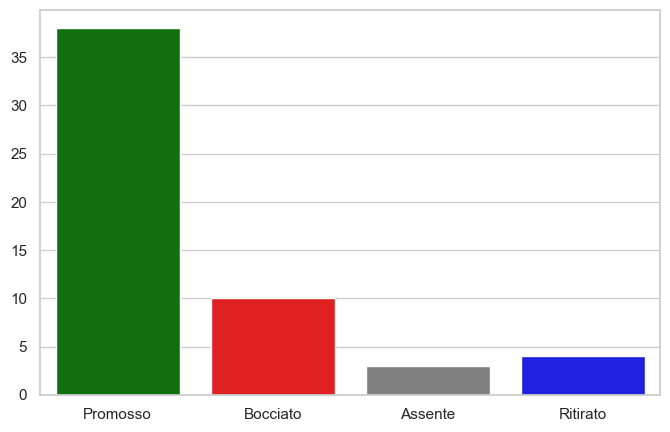

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
    "Esempio_Appello (C3).xlsx",
]

df = pd.DataFrame()

for f in files:
    temp = pd.read_excel(f, usecols="E,I", skiprows=20, names=["Nome", "Esito"])
    df = pd.concat([df, temp], ignore_index=True)

def conteggio_esiti(df, colonna_esito):
    totali = {
        "Promosso": 0,
        "Bocciato": 0,
        "Assente": 0,
        "Ritirato": 0
    }
    
    for i, v in enumerate(df[colonna_esito]):
        if pd.isna(v):
            totali["Assente"] += 1
        else:
            v_str = str(v).strip().upper()
            
            if v_str == "RIT":
                totali["Ritirato"] += 1
            elif v_str == "ASS":
                totali["Assente"] += 1
            elif v_str == "0":
                totali["Bocciato"] += 1
            else:
                try:
                    voto = float(v_str.replace("30L", "31"))
                    if voto >= 18:
                        totali["Promosso"] += 1
                    else:
                        totali["Bocciato"] += 1
                except:
                    totali["Assente"] += 1
    
    return totali

# ✅ CHIAMATA CORRETTA
totali_debug = conteggio_esiti(df, "Esito")

print("Totale studenti per categoria:")
for categoria, numero in totali_debug.items():
    print(f"{categoria}: {numero}")
# Grafico
plt.figure(figsize=(8,5))
sns.barplot(x=list(totali_debug.keys()), y=list(totali_debug.values()),
            palette={
                "Promosso": "green",
                "Bocciato": "red",
                "Assente": "grey",
                "Ritirato": "blue"
            })


['GRUPPO_GIUD_COD', 'VOTO_1', 'SUBSET', '19', 'FLD_LIV_LINGUE', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17']


In [73]:
import pandas as pd
import numpy as np

# --- Funzione per caricare i dati correttamente dai file Excel ---
def carica_dati(files, nome_colonna_nome="Nome", nome_colonna_voti="Esito", skiprows=20):
    df = pd.DataFrame()
    for f in files:
        temp = pd.read_excel(f, skiprows=skiprows)
        temp.columns = temp.columns.str.strip()  # rimuove spazi
        # Prendi solo colonne Nome e Esito (voti)
        temp = temp[[nome_colonna_nome, nome_colonna_voti]]
        df = pd.concat([df, temp], ignore_index=True)
    return df

# --- Funzione per pulire i voti (crea colonna numerica) ---
def pulisci_voti(df, colonna_voti="Esito"):
    def converti(v):
        if pd.isna(v):
            return np.nan
        v = str(v).strip().upper()
        if v == "ASS":
            return np.nan
        if v == "RIT":
            return -1  # ritirato
        if v == "0":
            return 0
        if v == "30L":
            return 31  # 30 con lode
        try:
            return float(v)
        except:
            return np.nan
    df["Voto_num"] = df[colonna_voti].apply(converti)
    return df

# --- Funzione per ottenere voti validi (>=0) ---
def voti_validi(df):
    return df[df["Voto_num"] >= 0]["Voto_num"]

# --- Funzione per calcolare media, mediana e deviazione standard ---
def statistiche_voti(df):
    voti = voti_validi(df)
    return {
        "media": voti.mean(),
        "mediana": voti.median(),
        "dev_std": voti.std()
    }

In [75]:
files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
    "Esempio_Appello (C3).xlsx",
]

# 1. Carica dati
df = carica_dati(files, nome_colonna_nome="Nome", nome_colonna_voti="Esito", skiprows=20)

# 2. Pulisci voti
df = pulisci_voti(df, colonna_voti="Esito")

# 3. Calcola statistiche
stat = statistiche_voti(df)
print(f"Media: {stat['media']:.2f}, Mediana: {stat['mediana']:.2f}, Deviazione standard: {stat['dev_std']:.2f}")

Media: 19.73, Mediana: 23.50, Deviazione standard: 10.99


In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# --- Funzione per classificare esiti ---
def categoria_esito(v):
    if pd.isna(v):
        return "Assente"
    elif v == -1:
        return "Ritirato"
    elif v >= 18:
        return "Promosso"
    else:
        return "Bocciato"

# --- Istogramma distribuzione voti ---
def grafico_distribuzione(df):
    voti = voti_validi(df)
    plt.figure(figsize=(10,6))
    sns.histplot(voti, bins=13, kde=False, color="skyblue")
    plt.title("Distribuzione voti (>=18)")
    plt.xlabel("Voto")
    plt.ylabel("Numero studenti")
    plt.show()

# --- Bar chart esiti ---
def grafico_categorie(df):
    df["Categoria"] = df["Voto_num"].apply(categoria_esito)
    conteggi = df["Categoria"].value_counts()
    plt.figure(figsize=(8,5))
    sns.barplot(x=conteggi.index, y=conteggi.values, palette="pastel")
    plt.title("Distribuzione esiti")
    plt.ylabel("Numero studenti")
    plt.show()

# --- Pie chart percentuali ---
def grafico_torta(df):
    conteggi = df["Categoria"].value_counts()
    plt.figure(figsize=(6,6))
    conteggi.plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
    plt.title("Percentuale esiti")
    plt.ylabel("")
    plt.show()

# --- Boxplot voti ---
def grafico_boxplot(df):
    voti = voti_validi(df)
    plt.figure(figsize=(6,8))
    sns.boxplot(y=voti, color="lightblue")
    plt.title("Boxplot della distribuzione voti")
    plt.ylabel("Voto")
    plt.show()

# --- Grafico media, mediana, deviazione standard ---
def grafico_statistiche(df):
    stat = statistiche_voti(df)
    plt.figure(figsize=(8,5))
    valori = [stat["media"], stat["mediana"]]
    etichette = ["Media", "Mediana"]
    plt.bar(etichette, valori, yerr=[stat["dev_std"], stat["dev_std"]], capsize=10, color=["skyblue", "lightgreen"])
    plt.title("Media, Mediana e Deviazione Standard dei Voti")
    plt.ylabel("Voto")
    plt.ylim(0, 32)
    plt.show()

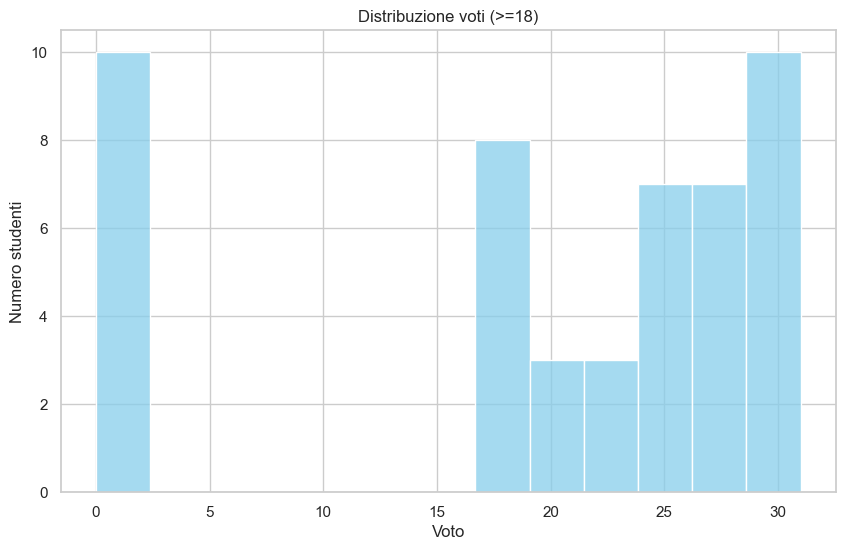

C:\Users\alice\AppData\Local\Temp\ipykernel_24120\2671896098.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteggi.index, y=conteggi.values, palette="pastel")


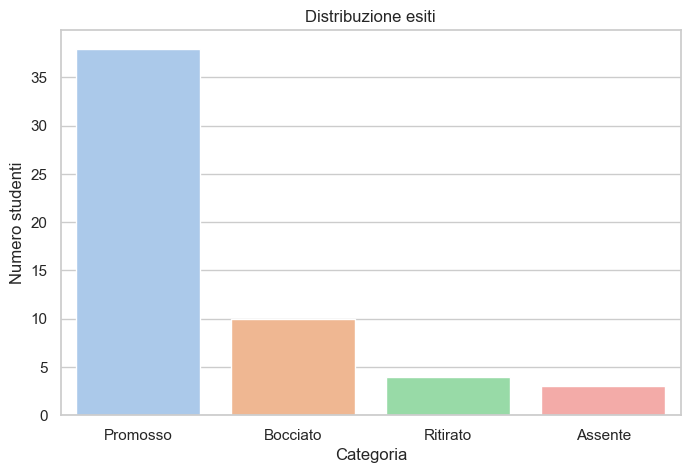

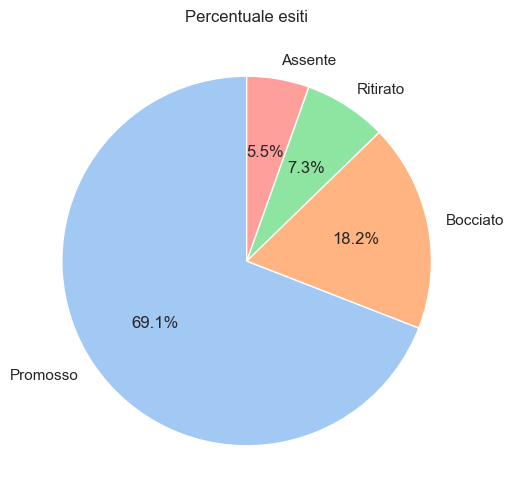

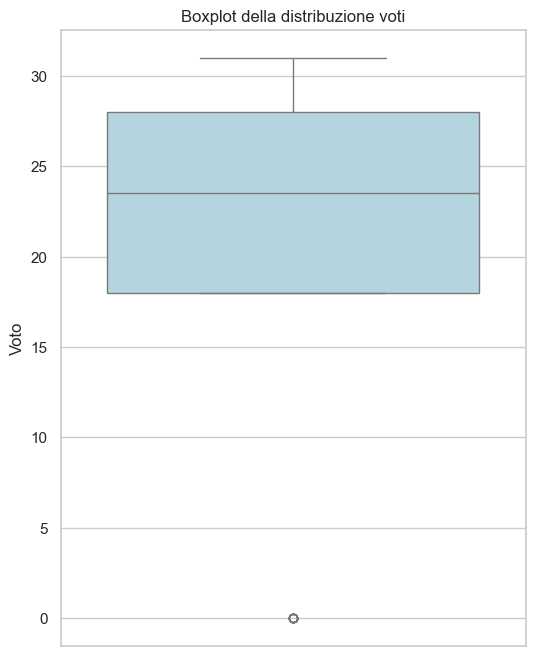

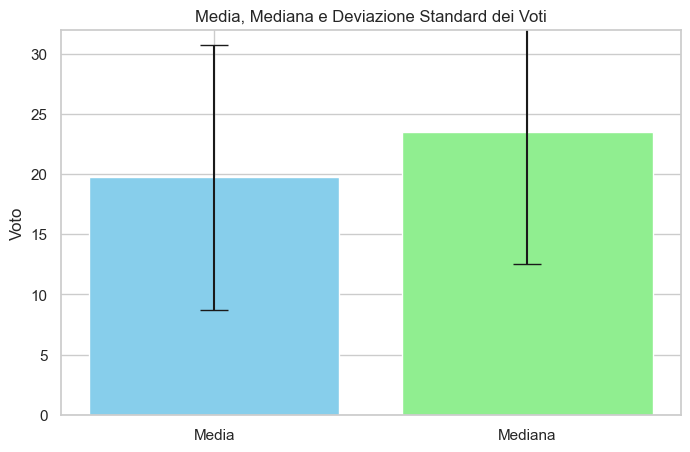

In [77]:
# Distribuzione voti
grafico_distribuzione(df)

# Bar chart categorie
grafico_categorie(df)

# Pie chart percentuali
grafico_torta(df)

# Boxplot voti
grafico_boxplot(df)

# Media, mediana e deviazione standard
grafico_statistiche(df)

In [86]:
# Prepariamo un DataFrame con nome file (appello) e voti
def df_per_appello(files, nome_colonna_nome="Nome", nome_colonna_voti="Esito", skiprows=20):
    df_appelli = pd.DataFrame()
    for f in files:
        temp = pd.read_excel(f, skiprows=skiprows)
        temp.columns = temp.columns.str.strip()
        temp = temp[[nome_colonna_nome, nome_colonna_voti]]
        temp = pulisci_voti(temp, colonna_voti=nome_colonna_voti)
        temp["Appello"] = f.split("(")[-1].split(")")[0]  # estrae C1, C2, C3
        df_appelli = pd.concat([df_appelli, temp], ignore_index=True)
    return df_appelli

df_appelli = df_per_appello(files)


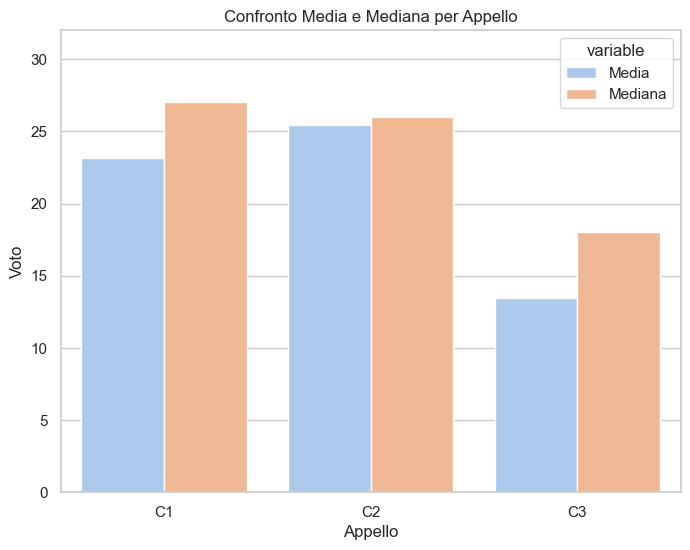

In [ ]:
# Grafico comparativo media e mediana per appello
def grafico_appelli(df_appelli):
    import matplotlib.pyplot as plt
    import seaborn as sns

    stat_list = []
    for appello in df_appelli["Appello"].unique():
        voti = voti_validi(df_appelli[df_appelli["Appello"] == appello])
        stat_list.append({
            "Appello": appello,
            "Media": voti.mean(),
            "Mediana": voti.median()
        })
    df_stat = pd.DataFrame(stat_list)

    plt.figure(figsize=(8,6))
    sns.barplot(x="Appello", y="value", hue="variable",
                data=pd.melt(df_stat, id_vars="Appello"), palette="pastel")
    plt.title("Confronto Media e Mediana per Appello")
    plt.ylabel("Voto")
    plt.ylim(0, 32)
    plt.show()

grafico_appelli(df_appelli)
#


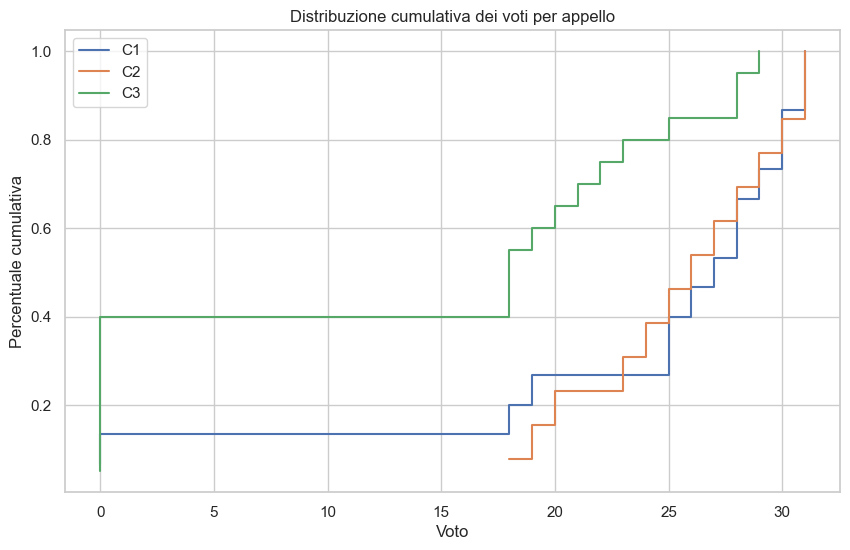

In [ ]:
def cumulative_voti(df_appelli):
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(10,6))
    for appello in df_appelli["Appello"].unique():
        voti = voti_validi(df_appelli[df_appelli["Appello"] == appello]).sort_values()
        cumulativa = np.arange(1, len(voti)+1) / len(voti)
        plt.step(voti, cumulativa, where='post', label=appello)
    plt.title("Distribuzione cumulativa dei voti per appello")
    plt.xlabel("Voto")
    plt.ylabel("Percentuale cumulativa")
    plt.legend()
    plt.grid(True)
    plt.show()
cumulative_voti(df_appelli)
#

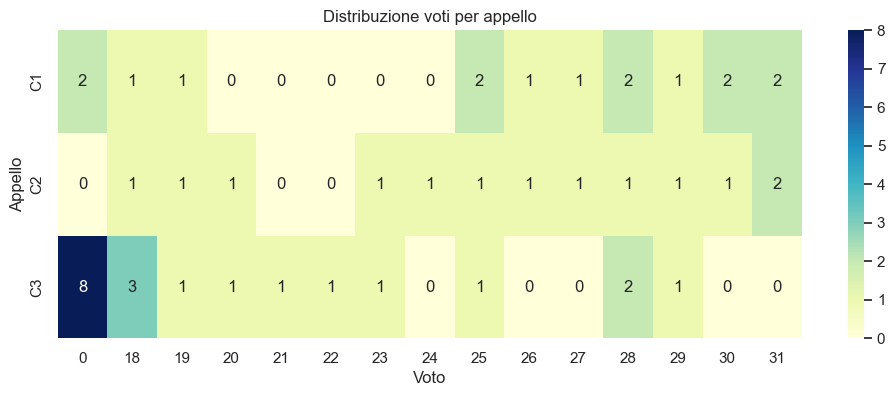

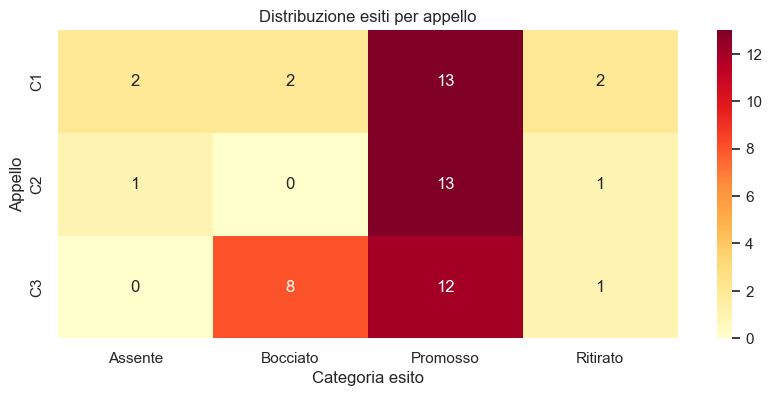

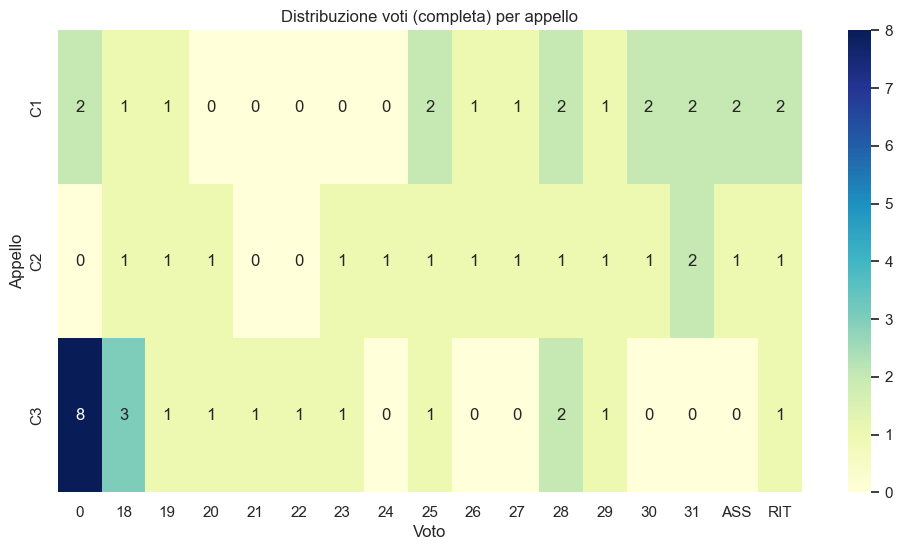

In [92]:
def heatmap_voti(df_appelli):
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Pivot: righe = Appello, colonne = Voti, valori = numero studenti
    df_heat = df_appelli[df_appelli["Voto_num"] >= 0].copy()
    df_heat["Voto_num"] = df_heat["Voto_num"].astype(int)
    df_heat = df_heat.groupby(["Appello", "Voto_num"]).size().reset_index(name="Conteggio")
    df_pivot = df_heat.pivot(index="Appello", columns="Voto_num", values="Conteggio").fillna(0)

    plt.figure(figsize=(12,4))
    sns.heatmap(df_pivot, annot=True, fmt=".0f", cmap="YlGnBu")
    plt.title("Distribuzione voti per appello")
    plt.xlabel("Voto")
    plt.ylabel("Appello")
    plt.show()
heatmap_voti(df_appelli)
# possiamo farlo anche con gli assenti e ritirati
def heatmap_esiti(df_appelli):
    import matplotlib.pyplot as plt
    import seaborn as sns

    df_heat = df_appelli.copy()
    df_heat["Categoria"] = df_heat["Voto_num"].apply(categoria_esito)
    df_heat = df_heat.groupby(["Appello", "Categoria"]).size().reset_index(name="Conteggio")
    df_pivot = df_heat.pivot(index="Appello", columns="Categoria", values="Conteggio").fillna(0)

    plt.figure(figsize=(10,4))
    sns.heatmap(df_pivot, annot=True, fmt=".0f", cmap="YlOrRd")
    plt.title("Distribuzione esiti per appello")
    plt.xlabel("Categoria esito")
    plt.ylabel("Appello")
    plt.show()
heatmap_esiti(df_appelli)
# e infine possiamo farlo con tutti i voti come nel primo caso e in piu una colonna per i ritirati e una per gli assenti
# TODO: NON con chi passa e non ma proprio con i voti effettivi quindi i dati grezzi, senza categorizzare in promosso o bocciato, ma con i voti reali e poi una colonna a parte per i ritirati e una per gli assenti
def heatmap_voti_completa(df_appelli):
    import matplotlib.pyplot as plt
    import seaborn as sns

    df_heat = df_appelli.copy()
    df_heat["Voto_str"] = df_heat["Voto_num"].apply(lambda x: str(int(x)) if pd.notna(x) and x >= 0 else ("RIT" if x == -1 else "ASS"))
    df_heat = df_heat.groupby(["Appello", "Voto_str"]).size().reset_index(name="Conteggio")
    df_pivot = df_heat.pivot(index="Appello", columns="Voto_str", values="Conteggio").fillna(0)     
    plt.figure(figsize=(12,6))
    sns.heatmap(df_pivot, annot=True, fmt=".0f", cmap="YlGnBu")
    plt.title("Distribuzione voti (completa) per appello")
    plt.xlabel("Voto")  
    plt.ylabel("Appello")
    plt.show()
heatmap_voti_completa(df_appelli)


Matricola
162993    3
163000    3
162999    3
163009    3
163011    2
163010    2
163003    2
162994    2
163016    2
163017    2
163018    2
Name: count, dtype: int64
Studenti che hanno ripetuto l'esame:
Matricola
162993    3
163000    3
162999    3
163009    3
163011    2
163010    2
163003    2
162994    2
163016    2
163017    2
163018    2
Name: count, dtype: int64


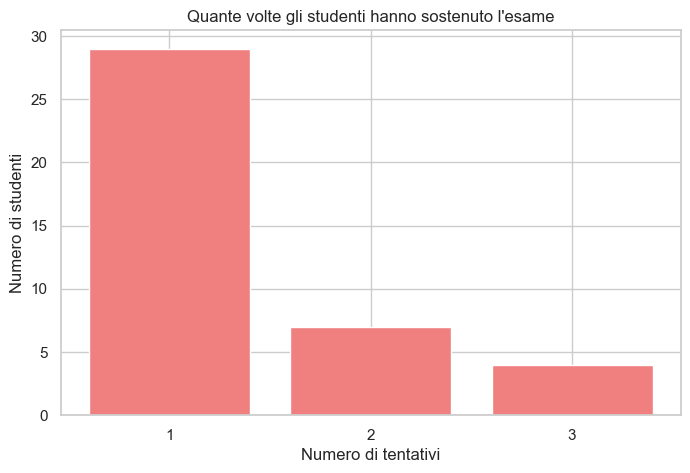

In [96]:
def carica_dati(files, nome_colonna_nome="Nome", nome_colonna_voti="Esito", nome_colonna_matricola="Matricola", skiprows=20):
    df = pd.DataFrame()
    for f in files:
        temp = pd.read_excel(f, skiprows=skiprows)
        temp.columns = temp.columns.str.strip()
        # Prendi colonne: Matricola, Nome, Esito
        temp = temp[[nome_colonna_matricola, nome_colonna_nome, nome_colonna_voti]]
        df = pd.concat([df, temp], ignore_index=True)
    return df
files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
    "Esempio_Appello (C3).xlsx",
]

df_appelli = carica_dati(files, nome_colonna_nome="Nome", nome_colonna_voti="Esito", nome_colonna_matricola="Matricola", skiprows=20)

df_appelli = pulisci_voti(df_appelli, colonna_voti="Esito")
conteggio_ripetizioni = df_appelli["Matricola"].value_counts()
ripetuti = conteggio_ripetizioni[conteggio_ripetizioni > 1]

print(ripetuti)

# Mostriamo solo chi ha ripetuto almeno una volta (comparso più di 1 volta)
ripetuti = conteggio_ripetizioni[conteggio_ripetizioni > 1]

print("Studenti che hanno ripetuto l'esame:")
print(ripetuti)

# Grafico: numero di studenti per numero di tentativi
df_ripetizioni = conteggio_ripetizioni.value_counts().sort_index()

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(df_ripetizioni.index, df_ripetizioni.values, color="lightcoral")
plt.xlabel("Numero di tentativi")
plt.ylabel("Numero di studenti")
plt.title("Quante volte gli studenti hanno sostenuto l'esame")
plt.xticks(df_ripetizioni.index)
plt.show()

C:\Users\alice\AppData\Local\Temp\ipykernel_24120\112192971.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Tipo_ripetizione", y="Delta_voto", data=df_ripetizioni, palette="Set2")


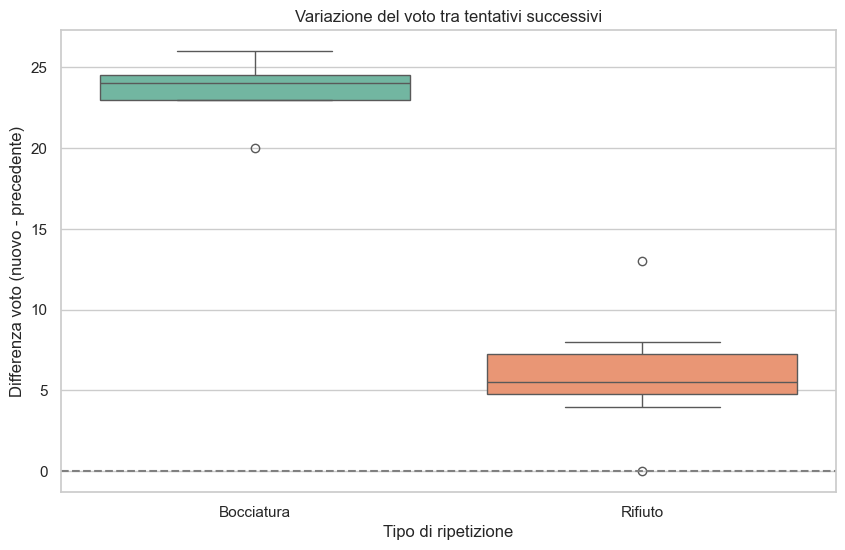

,mean,median,count
Tipo_ripetizione,,,
Bocciatura,23.5,24.0,4
Rifiuto,6.0,5.5,8


In [106]:
def carica_dati(files, nome_colonna_nome="Nome", nome_colonna_voti="Esito", nome_colonna_matricola="Matricola", skiprows=20):
    df = pd.DataFrame()
    for f in files:
        temp = pd.read_excel(f, skiprows=skiprows)
        temp.columns = temp.columns.str.strip()
        # Prendi solo le colonne richieste
        temp = temp[[nome_colonna_matricola, nome_colonna_nome, nome_colonna_voti]]
        # Aggiungi la colonna "Appello" estratta dal nome file
        temp["Appello"] = f.split("(")[-1].split(")")[0]  # es: "C1", "C2", "C3"
        df = pd.concat([df, temp], ignore_index=True)
    return df

# Carica e pulisci i dati
df_appelli = carica_dati(files)
df_appelli = pulisci_voti(df_appelli, colonna_voti="Esito")
# Ordiniamo il DataFrame per matricola e appello (assumendo Appello ordinabile)
df_appelli = df_appelli.sort_values(by=["Matricola", "Appello"]).reset_index(drop=True)
df_appelli["Voto_precedente"] = df_appelli.groupby("Matricola")["Voto_num"].shift(1)
def classifica_ripetizione(row):
    if pd.isna(row["Voto_precedente"]):
        return "Primo tentativo"
    elif row["Voto_precedente"] >= 18:
        return "Rifiuto"
    else:
        return "Bocciatura"

df_appelli["Tipo_ripetizione"] = df_appelli.apply(classifica_ripetizione, axis=1)
df_appelli["Delta_voto"] = df_appelli["Voto_num"] - df_appelli["Voto_precedente"]
import matplotlib.pyplot as plt
import seaborn as sns

# Filtra i dati di ripetizione (esclude primo tentativo)
df_ripetizioni = df_appelli[df_appelli["Tipo_ripetizione"] != "Primo tentativo"].copy()

plt.figure(figsize=(10,6))
sns.boxplot(x="Tipo_ripetizione", y="Delta_voto", data=df_ripetizioni, palette="Set2")

plt.title("Variazione del voto tra tentativi successivi")
plt.xlabel("Tipo di ripetizione")
plt.ylabel("Differenza voto (nuovo - precedente)")
plt.axhline(0, color="gray", linestyle="--")  # linea zero per miglioramenti/peggioramenti
plt.show()


df_ripetizioni.groupby("Tipo_ripetizione")["Delta_voto"].agg(["mean", "median", "count"])

In [105]:
print(df_appelli.columns.tolist())

['Matricola', 'Nome', 'Esito', 'Voto_num']


C:\Users\alice\AppData\Local\Temp\ipykernel_24120\2654605215.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteggio_tipo.index, y=conteggio_tipo.values, palette="pastel")


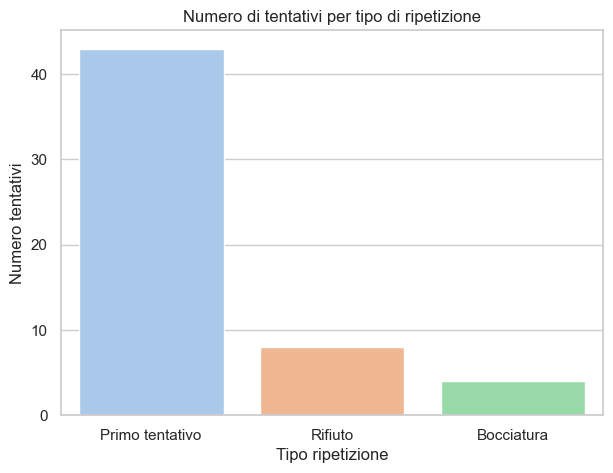

C:\Users\alice\AppData\Local\Temp\ipykernel_24120\2654605215.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Tipo_ripetizione", y="Delta_voto", data=df_ripetizioni, palette="Set2")


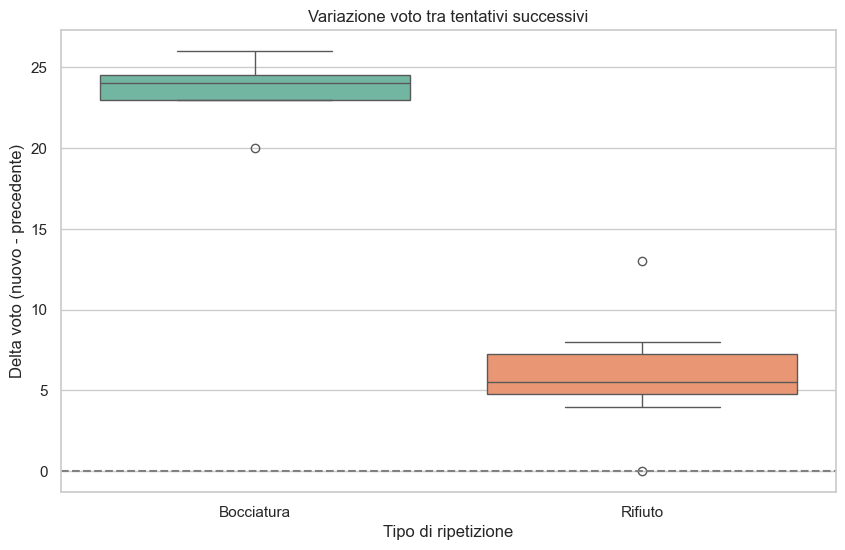

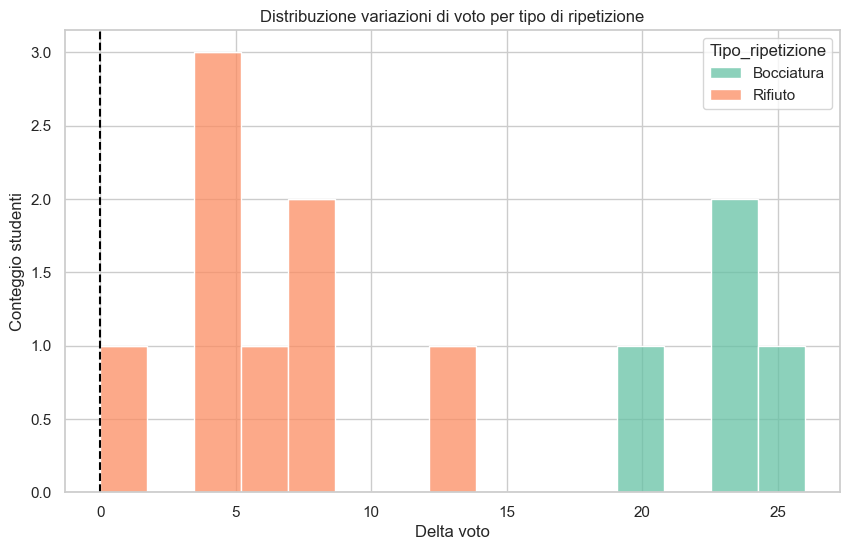

Statistiche variazione voto per tipo di ripetizione:
                   count  mean  median       std
Tipo_ripetizione                               
Bocciatura            4  23.5    24.0  2.516611
Rifiuto               8   6.0     5.5  3.703280


In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assumiamo df_appelli con colonne:
# "Matricola", "Voto_num", "Appello" (ordinato cronologicamente)

# 1. Aggiungiamo colonna voto precedente per ogni matricola
df_appelli["Voto_precedente"] = df_appelli.groupby("Matricola")["Voto_num"].shift(1)

# 2. Classificazione tipo di ripetizione
def classifica_ripetizione(row):
    if pd.isna(row["Voto_precedente"]):
        return "Primo tentativo"
    elif row["Voto_precedente"] >= 18:
        return "Rifiuto"
    else:
        return "Bocciatura"

df_appelli["Tipo_ripetizione"] = df_appelli.apply(classifica_ripetizione, axis=1)

# 3. Differenza voto tra tentativi
df_appelli["Delta_voto"] = df_appelli["Voto_num"] - df_appelli["Voto_precedente"]

# --- Grafico 1: Quanti ripetono e per quale motivo ---
conteggio_tipo = df_appelli["Tipo_ripetizione"].value_counts()
plt.figure(figsize=(7,5))
sns.barplot(x=conteggio_tipo.index, y=conteggio_tipo.values, palette="pastel")
plt.title("Numero di tentativi per tipo di ripetizione")
plt.ylabel("Numero tentativi")
plt.xlabel("Tipo ripetizione")
plt.show()

# --- Grafico 2: Miglioramenti/peggioramenti in base al tipo ---
df_ripetizioni = df_appelli[df_appelli["Tipo_ripetizione"] != "Primo tentativo"].copy()
plt.figure(figsize=(10,6))
sns.boxplot(x="Tipo_ripetizione", y="Delta_voto", data=df_ripetizioni, palette="Set2")
plt.axhline(0, color="gray", linestyle="--")
plt.title("Variazione voto tra tentativi successivi")
plt.xlabel("Tipo di ripetizione")
plt.ylabel("Delta voto (nuovo - precedente)")
plt.show()

# --- Grafico 3: Distribuzione miglioramenti/peggioramenti ---
plt.figure(figsize=(10,6))
sns.histplot(df_ripetizioni, x="Delta_voto", hue="Tipo_ripetizione", multiple="stack", palette="Set2", bins=15)
plt.axvline(0, color="black", linestyle="--")
plt.title("Distribuzione variazioni di voto per tipo di ripetizione")
plt.xlabel("Delta voto")
plt.ylabel("Conteggio studenti")
plt.show()

# --- Statistiche numeriche aggregate ---
statistiche = df_ripetizioni.groupby("Tipo_ripetizione")["Delta_voto"].agg(["count", "mean", "median", "std"])
print("Statistiche variazione voto per tipo di ripetizione:\n", statistiche)

Voti rifiutati dagli studenti:
2     20.0
4     18.0
11    19.0
14    23.0
18    26.0
26    24.0
30    19.0
40    18.0
Name: Voto_precedente, dtype: float64
Statistiche voti rifiutati:
count     8.000000
mean     20.875000
std       3.044316
min      18.000000
25%      18.750000
50%      19.500000
75%      23.250000
max      26.000000
Name: Voto_precedente, dtype: float64


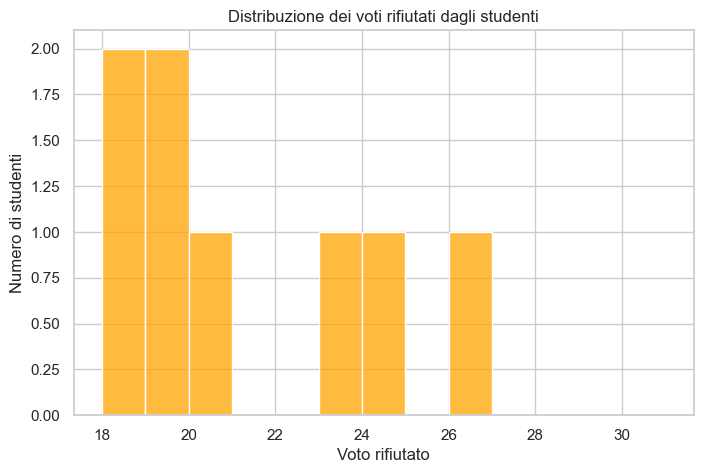

In [110]:
voti_rifiutati = df_appelli[df_appelli["Tipo_ripetizione"] == "Rifiuto"]["Voto_precedente"]
print("Voti rifiutati dagli studenti:")
print(voti_rifiutati)
print("Statistiche voti rifiutati:")
print(voti_rifiutati.describe())
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(voti_rifiutati, bins=range(18,32), kde=False, color="orange")
plt.title("Distribuzione dei voti rifiutati dagli studenti")
plt.xlabel("Voto rifiutato")
plt.ylabel("Numero di studenti")
plt.show()

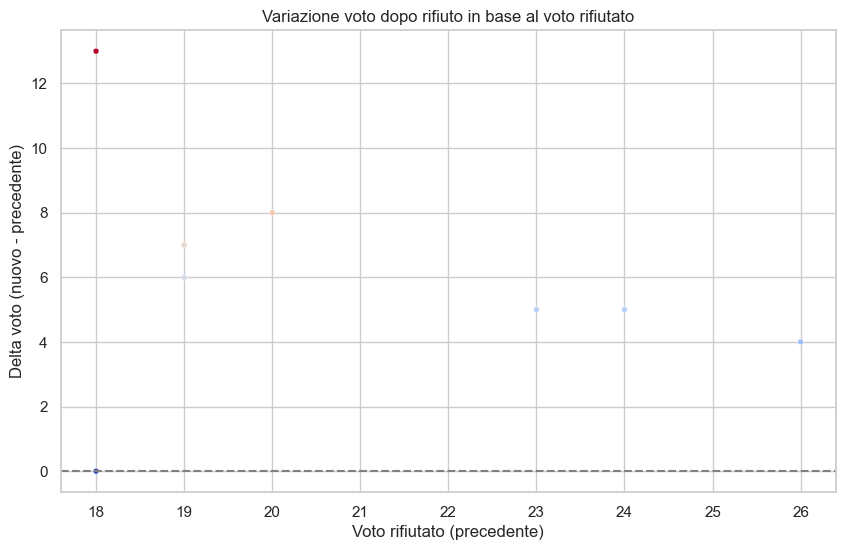

                 count  mean  median  min   max
Voto_precedente                                
18.0                 2   6.5     6.5  0.0  13.0
19.0                 2   6.5     6.5  6.0   7.0
20.0                 1   8.0     8.0  8.0   8.0
23.0                 1   5.0     5.0  5.0   5.0
24.0                 1   5.0     5.0  5.0   5.0
26.0                 1   4.0     4.0  4.0   4.0


In [113]:
# Prendiamo solo le ripetizioni di tipo "Rifiuto"
df_rifiuti = df_appelli[df_appelli["Tipo_ripetizione"] == "Rifiuto"].copy()

# Colonne utili: Voto_precedente e Delta_voto
df_rifiuti = df_rifiuti[["Matricola", "Voto_precedente", "Voto_num", "Delta_voto"]]

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_rifiuti, x="Voto_precedente", y="Delta_voto", hue="Delta_voto",
                palette="coolwarm", size=2, legend=False)
plt.axhline(0, color="gray", linestyle="--")
plt.title("Variazione voto dopo rifiuto in base al voto rifiutato")
plt.xlabel("Voto rifiutato (precedente)")
plt.ylabel("Delta voto (nuovo - precedente)")
plt.grid(True)
plt.show()
stat_rifiuti = df_rifiuti.groupby("Voto_precedente")["Delta_voto"].agg(["count","mean","median","min","max"])
print(stat_rifiuti)

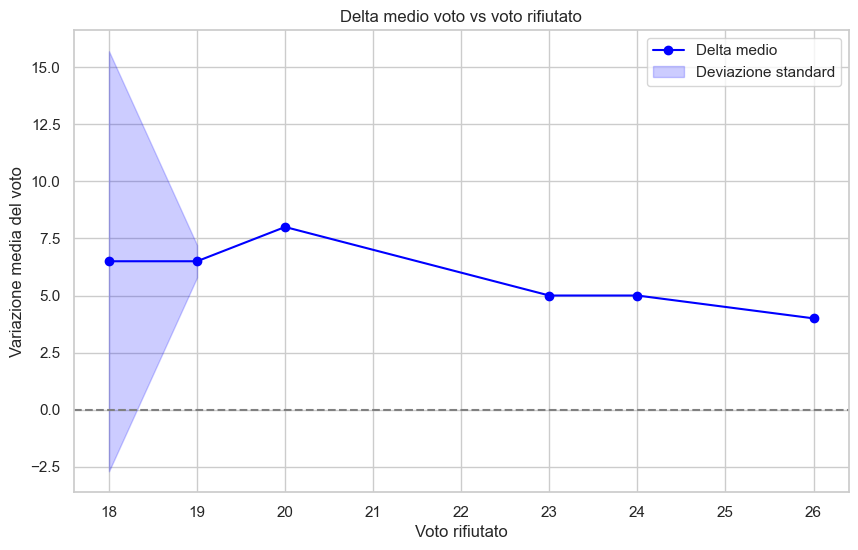

In [114]:
import matplotlib.pyplot as plt

# Calcolo media e deviazione standard del delta per ogni voto rifiutato
stat_line = df_rifiuti.groupby("Voto_precedente")["Delta_voto"].agg(["mean","std"]).reset_index()

plt.figure(figsize=(10,6))
plt.plot(stat_line["Voto_precedente"], stat_line["mean"], marker="o", color="blue", label="Delta medio")
plt.fill_between(stat_line["Voto_precedente"],
                 stat_line["mean"] - stat_line["std"],
                 stat_line["mean"] + stat_line["std"],
                 color="blue", alpha=0.2, label="Deviazione standard")
plt.axhline(0, color="gray", linestyle="--")
plt.title("Delta medio voto vs voto rifiutato")
plt.xlabel("Voto rifiutato")
plt.ylabel("Variazione media del voto")
plt.legend()
plt.grid(True)
plt.show()

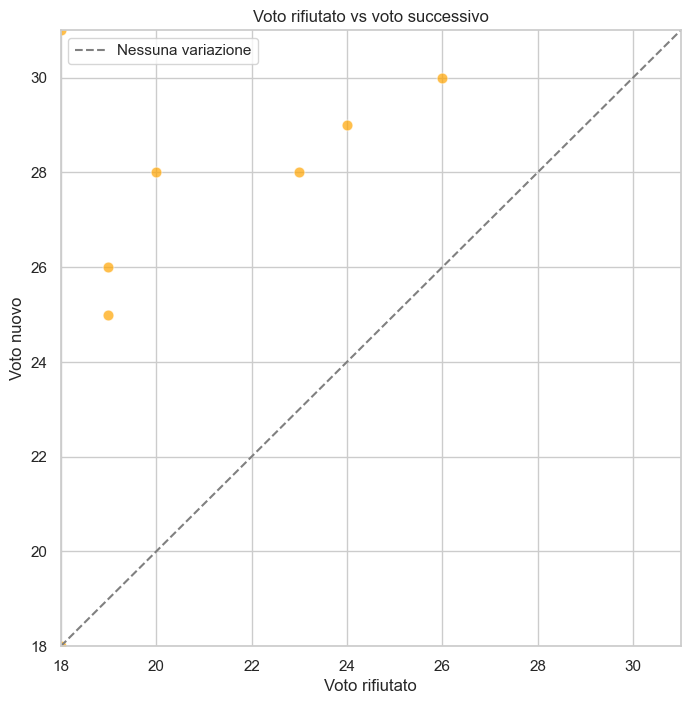

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

# Solo ripetizioni di tipo "Rifiuto"
df_rifiuti = df_appelli[df_appelli["Tipo_ripetizione"] == "Rifiuto"].copy()

plt.figure(figsize=(8,8))
sns.scatterplot(data=df_rifiuti, x="Voto_precedente", y="Voto_num", s=60, color="orange", alpha=0.7)

# Linea y = x per vedere chi migliora e chi peggiora
plt.plot([18,31], [18,31], color="gray", linestyle="--", label="Nessuna variazione")

plt.title("Voto rifiutato vs voto successivo")
plt.xlabel("Voto rifiutato")
plt.ylabel("Voto nuovo")
plt.xlim(18,31)
plt.ylim(18,31)
plt.grid(True)
plt.legend()
plt.show()

C:\Users\alice\AppData\Local\Temp\ipykernel_24120\2736979087.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


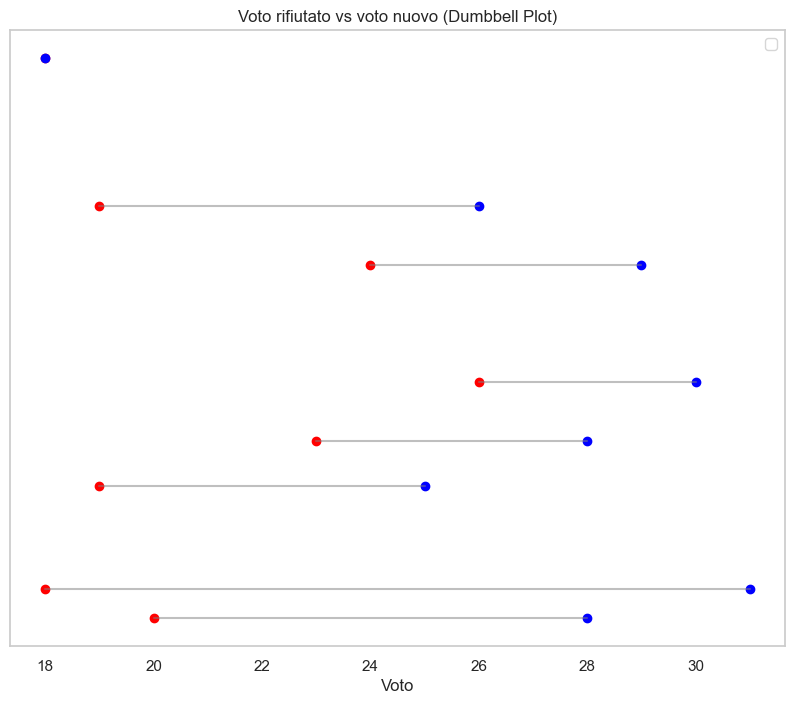

In [116]:
plt.figure(figsize=(10,8))

for i, row in df_rifiuti.iterrows():
    plt.plot([row["Voto_precedente"], row["Voto_num"]], [i, i], color="gray", alpha=0.5)  # linea
    plt.scatter(row["Voto_precedente"], i, color="red", label="Voto rifiutato" if i==0 else "")
    plt.scatter(row["Voto_num"], i, color="blue", label="Voto nuovo" if i==0 else "")

plt.yticks([])  # nasconde l’asse Y, ogni riga = uno studente
plt.xlabel("Voto")
plt.title("Voto rifiutato vs voto nuovo (Dumbbell Plot)")
plt.legend()
plt.grid(axis="x")
plt.show()

C:\Users\alice\AppData\Local\Temp\ipykernel_24120\2736979087.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


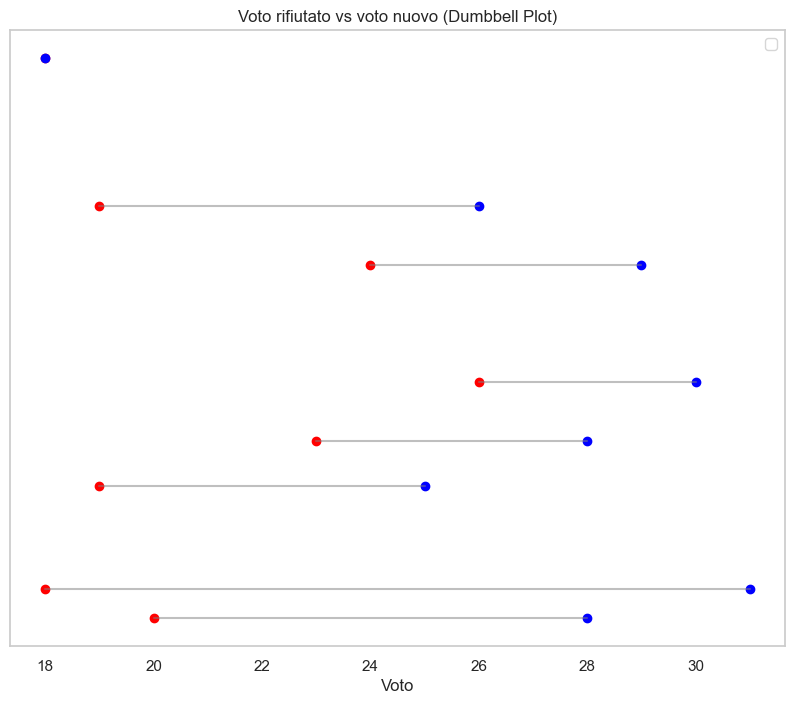

In [117]:
plt.figure(figsize=(10,8))

for i, row in df_rifiuti.iterrows():
    plt.plot([row["Voto_precedente"], row["Voto_num"]], [i, i], color="gray", alpha=0.5)  # linea
    plt.scatter(row["Voto_precedente"], i, color="red", label="Voto rifiutato" if i==0 else "")
    plt.scatter(row["Voto_num"], i, color="blue", label="Voto nuovo" if i==0 else "")

plt.yticks([])  # nasconde l’asse Y, ogni riga = uno studente
plt.xlabel("Voto")
plt.title("Voto rifiutato vs voto nuovo (Dumbbell Plot)")
plt.legend()
plt.grid(axis="x")
plt.show()

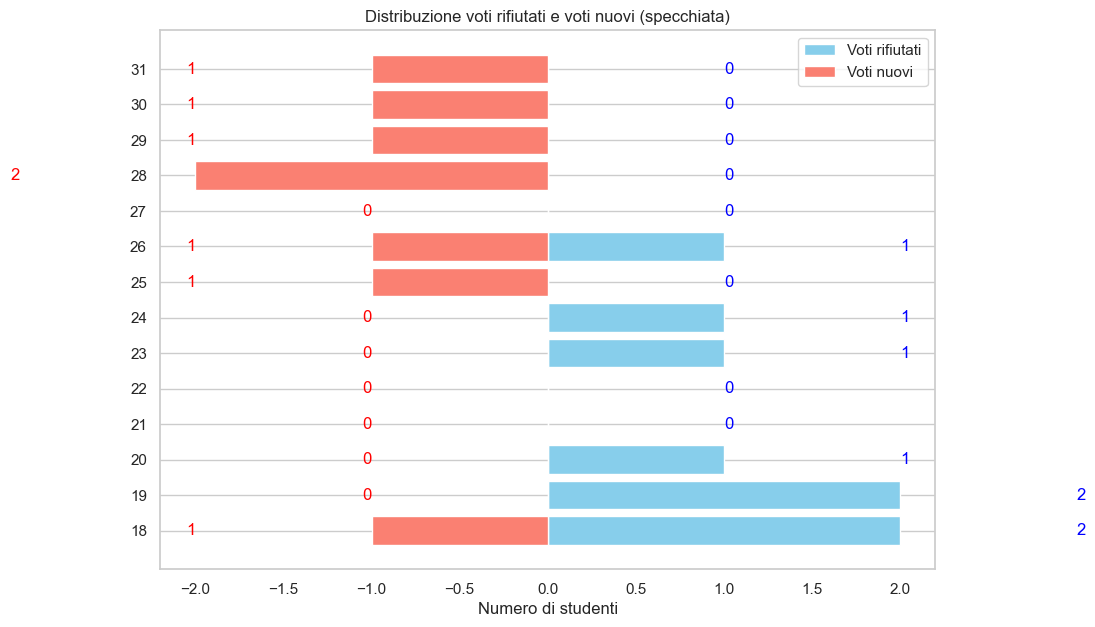

In [ ]:
import numpy as np

# Conteggi voti rifiutati e voti nuovi (dopo rifiuto)
count_pre = df_rifiuti["Voto_precedente"].value_counts().sort_index()
count_new = df_rifiuti["Voto_num"].value_counts().sort_index()

voti_range = np.arange(18, 32)  # voti da 18 a 31

# Prendi valori per tutti i voti (anche se zero)
count_pre_all = [count_pre.get(v, 0) for v in voti_range]
count_new_all = [count_new.get(v, 0) for v in voti_range]

plt.figure(figsize=(10,7))

# Barre a sinistra (voti rifiutati)
plt.barh(voti_range, count_pre_all, color="skyblue", label="Voti rifiutati")

# Barre a destra (voti nuovi), con valori negativi per specchiare
plt.barh(voti_range, [-x for x in count_new_all], color="salmon", label="Voti nuovi")

plt.yticks(voti_range)
plt.xlabel("Numero di studenti")
plt.title("Distribuzione voti rifiutati e voti nuovi (specchiata)")
plt.legend()

# Etichette con valori assoluti
for i, v in enumerate(voti_range):
    plt.text(count_pre_all[i]+1, v, str(count_pre_all[i]), va='center', color='blue')
    plt.text(-count_new_all[i]-1, v, str(count_new_all[i]), va='center', ha='right', color='red')

plt.grid(axis='x')
plt.show()
#se sono entrambi 0 non metterli


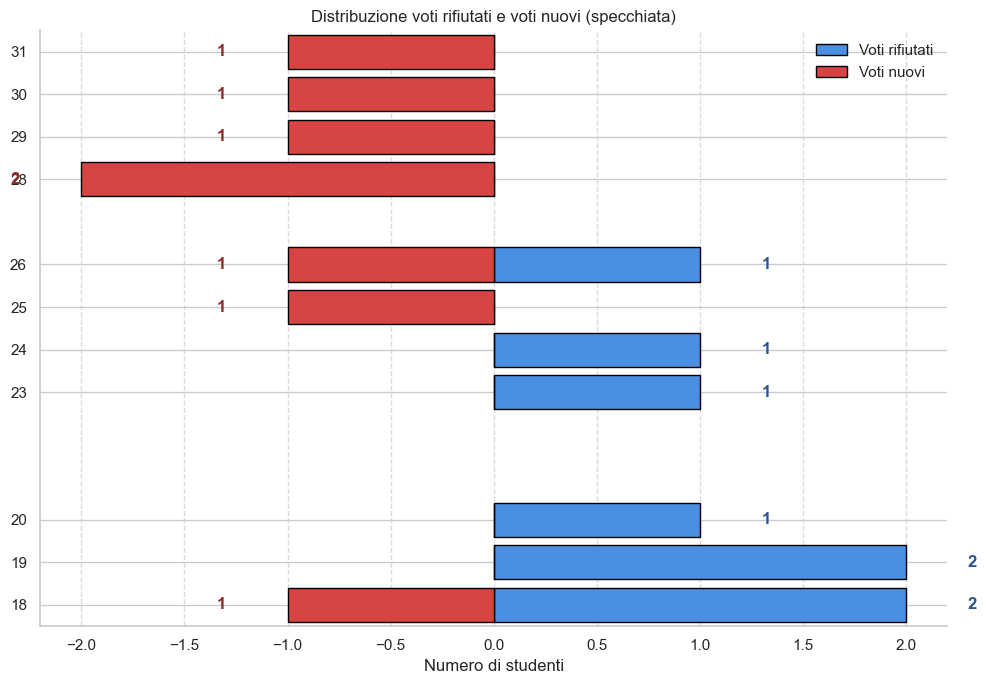

In [123]:
import numpy as np
import matplotlib.pyplot as plt

# Conteggi voti rifiutati e voti nuovi (dopo rifiuto)
count_pre = df_rifiuti["Voto_precedente"].value_counts().sort_index()
count_new = df_rifiuti["Voto_num"].value_counts().sort_index()

voti_range = np.arange(18, 32)  # voti da 18 a 31

# Prepara liste filtrate per escludere voti con zero conteggi su entrambi i lati
filtered_voti = []
filtered_pre = []
filtered_new = []

for v in voti_range:
    pre_val = count_pre.get(v, 0)
    new_val = count_new.get(v, 0)
    if pre_val != 0 or new_val != 0:
        filtered_voti.append(v)
        filtered_pre.append(pre_val)
        filtered_new.append(new_val)

plt.figure(figsize=(10, 7))

# Barre a sinistra (voti rifiutati)
plt.barh(filtered_voti, filtered_pre, color="#4A90E2", label="Voti rifiutati", edgecolor='black')

# Barre a destra (voti nuovi), valori negativi per specchiare
plt.barh(filtered_voti, [-x for x in filtered_new], color="#D64541", label="Voti nuovi", edgecolor='black')

plt.yticks(filtered_voti)
plt.xlabel("Numero di studenti")
plt.title("Distribuzione voti rifiutati e voti nuovi (specchiata)")

# Imposta limiti y più stretti per togliere spazio vuoto
plt.ylim(min(filtered_voti) - 0.5, max(filtered_voti) + 0.5)

# Etichette con valori assoluti sulle barre
for i, v in enumerate(filtered_voti):
    pre_val = filtered_pre[i]
    new_val = filtered_new[i]
    if pre_val > 0:
        plt.text(pre_val + 0.3, v, str(pre_val), va='center', color='#2F5496', fontweight='bold')
    if new_val > 0:
        plt.text(-new_val - 0.3, v, str(new_val), va='center', ha='right', color='#8B2B26', fontweight='bold')

plt.legend(frameon=False)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

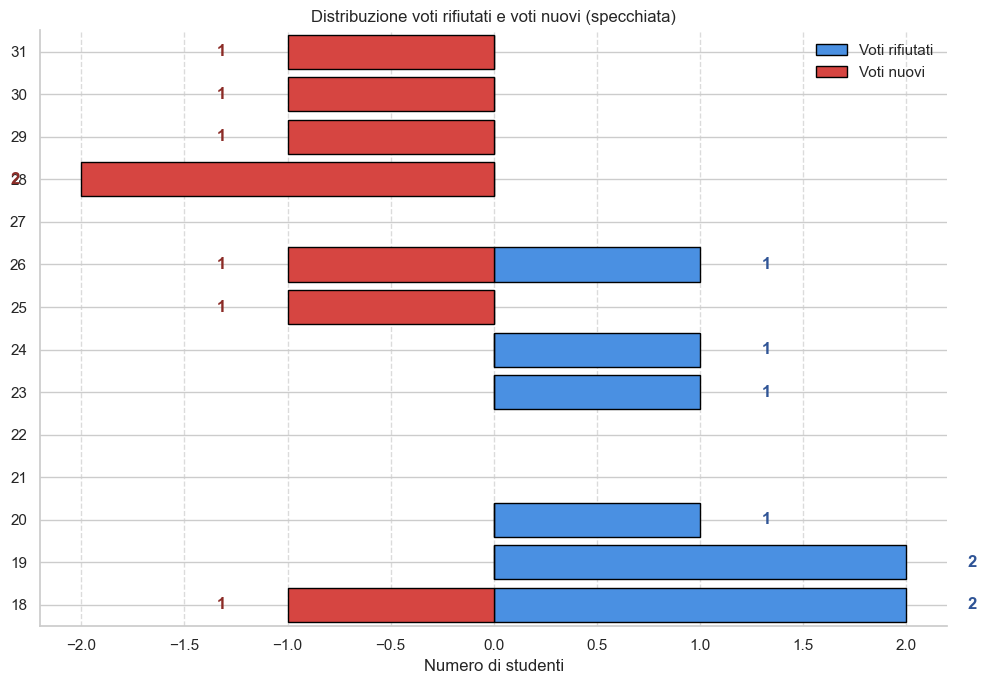

In [124]:
import numpy as np
import matplotlib.pyplot as plt

# Conteggi voti rifiutati e voti nuovi (dopo rifiuto)
count_pre = df_rifiuti["Voto_precedente"].value_counts().sort_index()
count_new = df_rifiuti["Voto_num"].value_counts().sort_index()

voti_range = np.arange(18, 32)  # voti da 18 a 31

# Filtra solo dati per barre, ma mantieni asse Y completo
filtered_voti = []
filtered_pre = []
filtered_new = []

for v in voti_range:
    pre_val = count_pre.get(v, 0)
    new_val = count_new.get(v, 0)
    if pre_val != 0 or new_val != 0:
        filtered_voti.append(v)
        filtered_pre.append(pre_val)
        filtered_new.append(new_val)

plt.figure(figsize=(10, 7))

# Barre a sinistra (voti rifiutati)
plt.barh(filtered_voti, filtered_pre, color="#4A90E2", label="Voti rifiutati", edgecolor='black')

# Barre a destra (voti nuovi), valori negativi per specchiare
plt.barh(filtered_voti, [-x for x in filtered_new], color="#D64541", label="Voti nuovi", edgecolor='black')

# Imposta asse Y con tutta la sequenza senza saltare valori
plt.yticks(voti_range)  # tutta la sequenza

plt.xlabel("Numero di studenti")
plt.title("Distribuzione voti rifiutati e voti nuovi (specchiata)")

# Limiti y stretti attorno alla sequenza
plt.ylim(min(voti_range) - 0.5, max(voti_range) + 0.5)

# Etichette con valori assoluti sulle barre
for i, v in enumerate(filtered_voti):
    pre_val = filtered_pre[i]
    new_val = filtered_new[i]
    if pre_val > 0:
        plt.text(pre_val + 0.3, v, str(pre_val), va='center', color='#2F5496', fontweight='bold')
    if new_val > 0:
        plt.text(-new_val - 0.3, v, str(new_val), va='center', ha='right', color='#8B2B26', fontweight='bold')

plt.legend(frameon=False)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

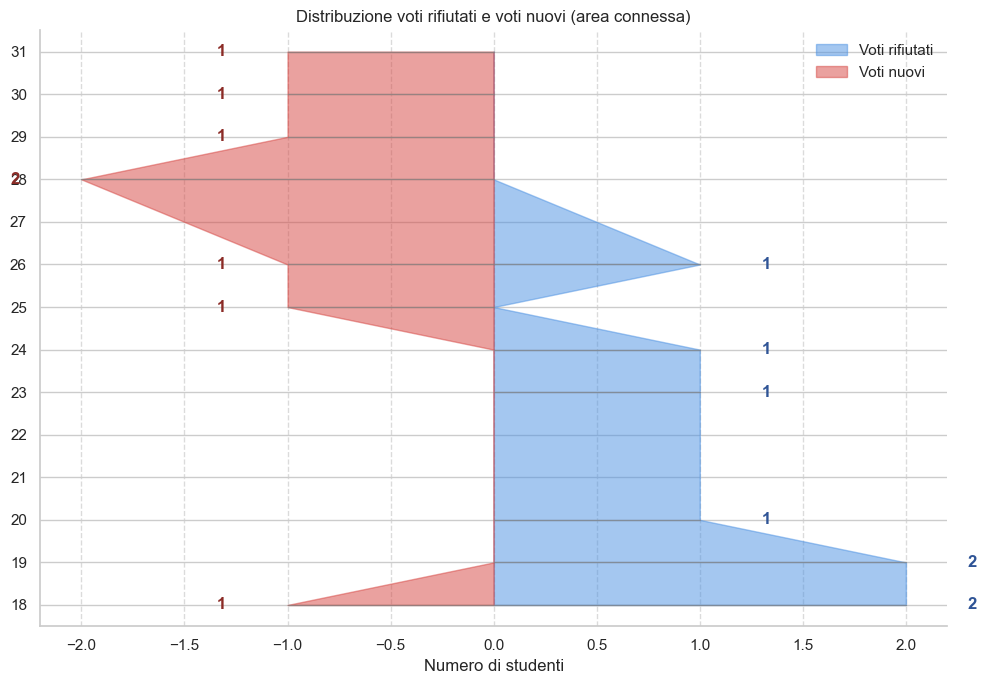

In [125]:
import numpy as np
import matplotlib.pyplot as plt

# Conteggi voti rifiutati e voti nuovi
count_pre = df_rifiuti["Voto_precedente"].value_counts().sort_index()
count_new = df_rifiuti["Voto_num"].value_counts().sort_index()

voti_range = np.arange(18, 32)  # voti da 18 a 31

# Filtra solo dati con almeno un valore >0, ma mantieni asse Y completo
filtered_voti = []
filtered_pre = []
filtered_new = []

for v in voti_range:
    pre_val = count_pre.get(v, 0)
    new_val = count_new.get(v, 0)
    if pre_val != 0 or new_val != 0:
        filtered_voti.append(v)
        filtered_pre.append(pre_val)
        filtered_new.append(new_val)

# Converti in numpy array per comodità
pre_vals = np.array(filtered_pre)
new_vals = np.array(filtered_new)
y_vals = np.array(filtered_voti)

plt.figure(figsize=(10, 7))

# Area dei voti rifiutati
plt.fill_betweenx(y_vals, 0, pre_vals, color="#4A90E2", alpha=0.5, label="Voti rifiutati")

# Area dei voti nuovi (valori negativi per specchiare)
plt.fill_betweenx(y_vals, -new_vals, 0, color="#D64541", alpha=0.5, label="Voti nuovi")

# Linee connesse per evidenziare collegamento
for i in range(len(y_vals)):
    plt.plot([ -new_vals[i], pre_vals[i] ], [ y_vals[i], y_vals[i] ], color="gray", alpha=0.7, linewidth=1)

# Asse Y completo
plt.yticks(np.arange(18, 32))
plt.xlabel("Numero di studenti")
plt.title("Distribuzione voti rifiutati e voti nuovi (area connessa)")

# Limiti y stretti
plt.ylim(17.5, 31.5)

# Etichette valori assoluti sulle aree
for i in range(len(y_vals)):
    if pre_vals[i] > 0:
        plt.text(pre_vals[i]+0.3, y_vals[i], str(pre_vals[i]), va='center', color='#2F5496', fontweight='bold')
    if new_vals[i] > 0:
        plt.text(-new_vals[i]-0.3, y_vals[i], str(new_vals[i]), va='center', ha='right', color='#8B2B26', fontweight='bold')

plt.legend(frameon=False)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

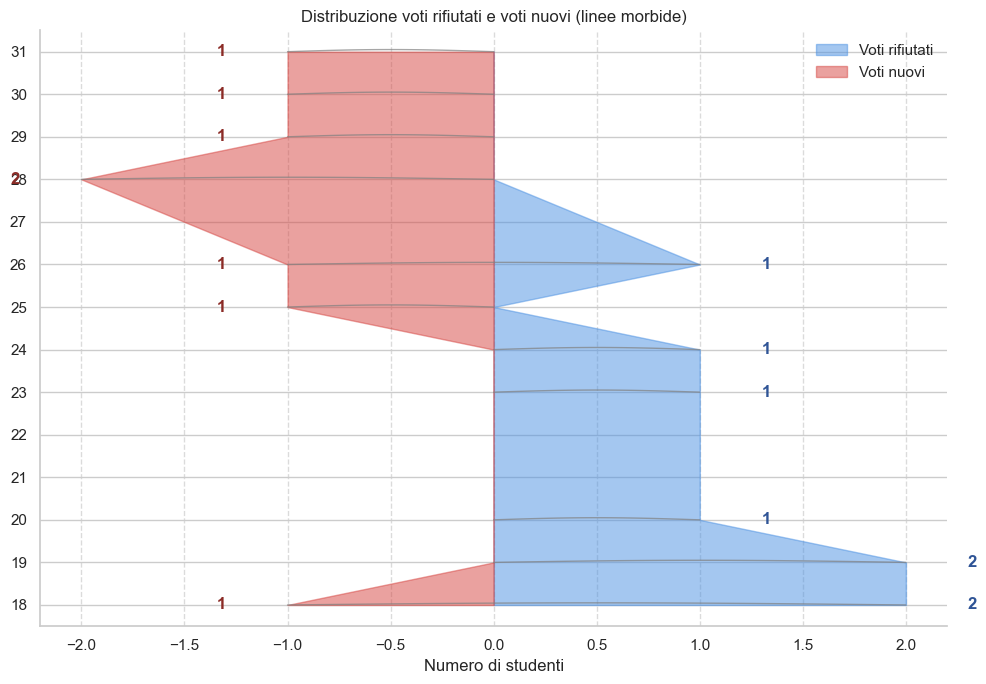

In [127]:
import numpy as np
import matplotlib.pyplot as plt

# Converti dati
y_vals = np.array(filtered_voti)
pre_vals = np.array(filtered_pre)
new_vals = np.array(filtered_new)

plt.figure(figsize=(10,7))

# Area sfumata
plt.fill_betweenx(y_vals, 0, pre_vals, color="#4A90E2", alpha=0.5, label="Voti rifiutati")
plt.fill_betweenx(y_vals, -new_vals, 0, color="#D64541", alpha=0.5, label="Voti nuovi")

# Linee morbide (usiamo piccole curve quadratiche)
for i in range(len(y_vals)):
    x = np.linspace(-new_vals[i], pre_vals[i], 100)
    # Curva leggermente smussata usando seno come oscillazione minima
    y = y_vals[i] + 0.05*np.sin(np.linspace(0, np.pi, 100))
    plt.plot(x, y, color="gray", alpha=0.7, linewidth=1)

# Asse Y continuo
plt.yticks(np.arange(18, 32))
plt.ylim(17.5, 31.5)
plt.xlabel("Numero di studenti")
plt.title("Distribuzione voti rifiutati e voti nuovi (linee morbide)")
plt.legend(frameon=False)

# Etichette valori assoluti
for i in range(len(y_vals)):
    if pre_vals[i] > 0:
        plt.text(pre_vals[i]+0.3, y_vals[i], str(pre_vals[i]), va='center', color='#2F5496', fontweight='bold')
    if new_vals[i] > 0:
        plt.text(-new_vals[i]-0.3, y_vals[i], str(new_vals[i]), va='center', ha='right', color='#8B2B26', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

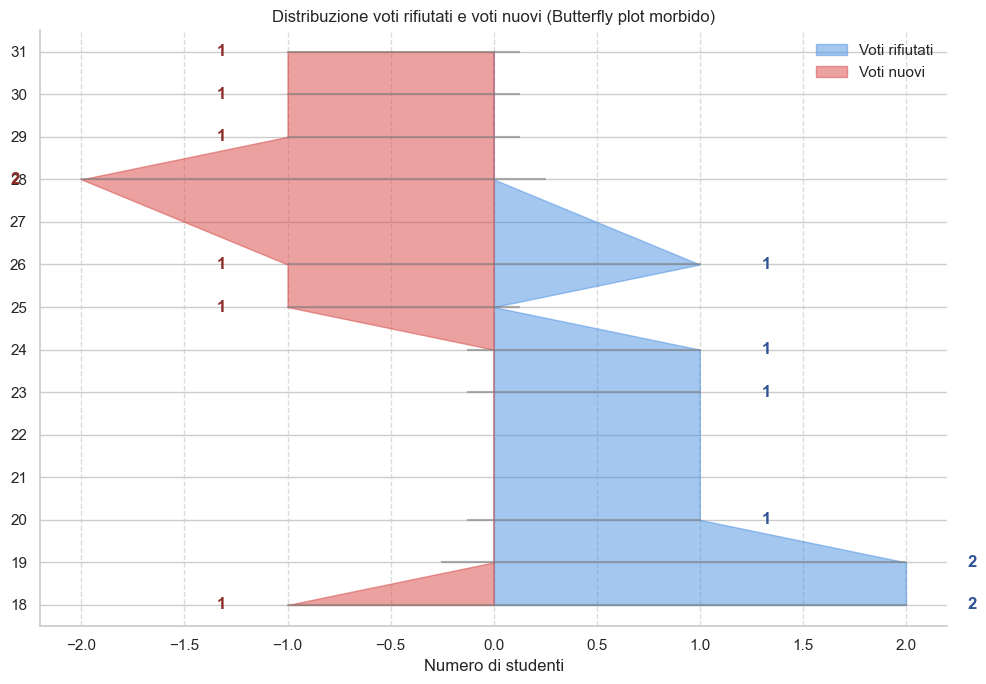

In [131]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

plt.figure(figsize=(10,7))
num_points = 50

for i in range(len(y_vals)):
    x_points = np.array([-new_vals[i], 0, pre_vals[i]])
    
    # Interpolazione quadratica
    f = interp1d(np.arange(3), x_points, kind='quadratic')
    x_smooth = f(np.linspace(0,2,num_points))
    y_smooth = np.full_like(x_smooth, y_vals[i])  # y costante, stessa lunghezza di x_smooth
    
    plt.plot(x_smooth, y_smooth, color='gray', alpha=0.6, linewidth=1.5)

# Aree colorate
plt.fill_betweenx(y_vals, 0, pre_vals, color="#4A90E2", alpha=0.5, label="Voti rifiutati")
plt.fill_betweenx(y_vals, -new_vals, 0, color="#D64541", alpha=0.5, label="Voti nuovi")

plt.yticks(np.arange(18,32))
plt.ylim(17.5,31.5)
plt.xlabel("Numero di studenti")
plt.title("Distribuzione voti rifiutati e voti nuovi (Butterfly plot morbido)")

# Etichette valori assoluti
for i in range(len(y_vals)):
    if pre_vals[i] > 0:
        plt.text(pre_vals[i]+0.3, y_vals[i], str(pre_vals[i]), va='center', color='#2F5496', fontweight='bold')
    if new_vals[i] > 0:
        plt.text(-new_vals[i]-0.3, y_vals[i], str(new_vals[i]), va='center', ha='right', color='#8B2B26', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.legend(frameon=False)
plt.show()

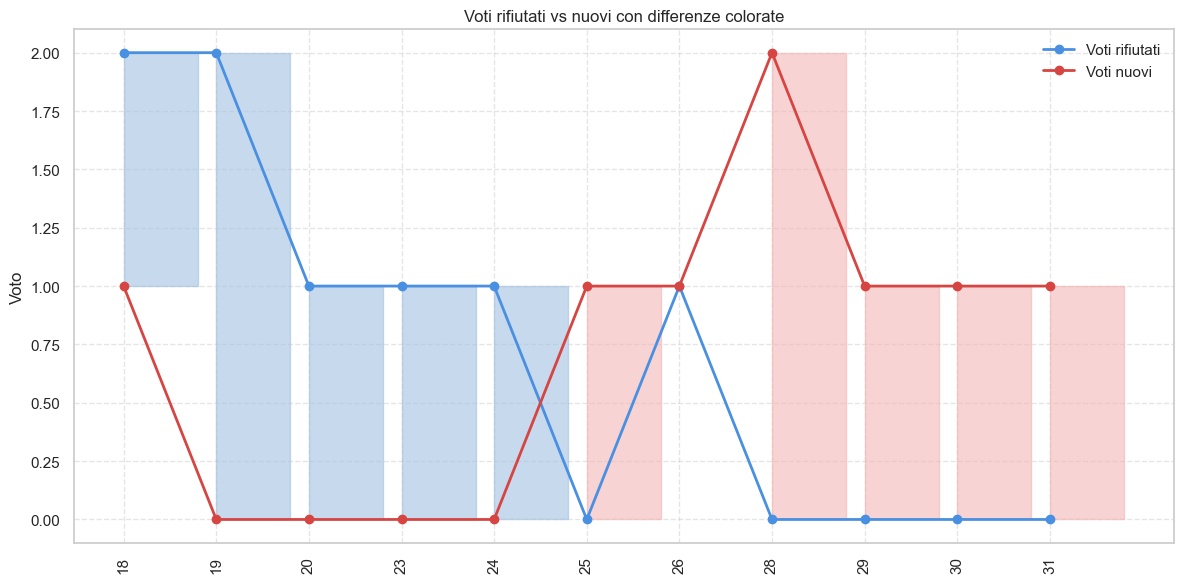

In [132]:
import numpy as np
import matplotlib.pyplot as plt

# Dati
x = np.arange(len(y_vals))  # ogni studente come punto sull'asse X
y_pre = np.array(filtered_pre)   # voti rifiutati
y_new = np.array(filtered_new)   # voti nuovi

plt.figure(figsize=(12,6))

# Linee dei voti
plt.plot(x, y_pre, color="#4A90E2", marker='o', label="Voti rifiutati", linewidth=2)
plt.plot(x, y_new, color="#D64541", marker='o', label="Voti nuovi", linewidth=2)

# Coloriamo l'area tra le linee in base al miglioramento o peggioramento
for i in range(len(x)):
    if y_new[i] > y_pre[i]:
        # Miglioramento → area rosso chiaro (della linea nuova)
        plt.fill_between([x[i], x[i]+0.8], y_pre[i], y_new[i], color="#F4B6B6", alpha=0.6)
    elif y_new[i] < y_pre[i]:
        # Peggioramento → area blu chiaro (della linea precedente)
        plt.fill_between([x[i], x[i]+0.8], y_new[i], y_pre[i], color="#A3C1E0", alpha=0.6)
    # Se uguale → nessuna area

plt.xticks(x, [f"{n}" for n in y_vals], rotation=90)  # opzionale: nomi o matricole
plt.ylabel("Voto")
plt.title("Voti rifiutati vs nuovi con differenze colorate")
plt.legend(frameon=False)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

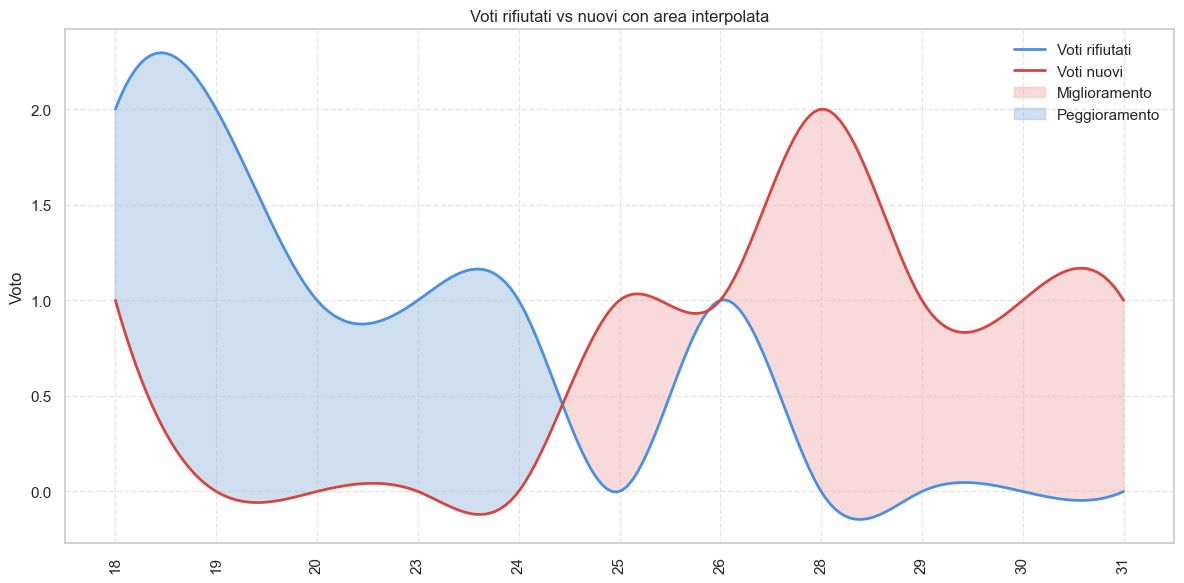

In [133]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Dati
x = np.arange(len(y_vals))  # ogni studente
y_pre = np.array(filtered_pre)
y_new = np.array(filtered_new)

# Interpolazione spline per curve morbide
num_points = 200  # punti interpolati per la curva
x_smooth = np.linspace(x.min(), x.max(), num_points)

spl_pre = make_interp_spline(x, y_pre, k=3)
spl_new = make_interp_spline(x, y_new, k=3)

y_pre_smooth = spl_pre(x_smooth)
y_new_smooth = spl_new(x_smooth)

plt.figure(figsize=(12,6))

# Linee principali
plt.plot(x_smooth, y_pre_smooth, color="#4A90E2", linewidth=2, label="Voti rifiutati")
plt.plot(x_smooth, y_new_smooth, color="#D64541", linewidth=2, label="Voti nuovi")

# Colorazione area interpolata tra le curve
plt.fill_between(x_smooth, y_pre_smooth, y_new_smooth, 
                 where=(y_new_smooth >= y_pre_smooth), 
                 interpolate=True, color="#F4B6B6", alpha=0.5, label="Miglioramento")

plt.fill_between(x_smooth, y_pre_smooth, y_new_smooth, 
                 where=(y_new_smooth < y_pre_smooth), 
                 interpolate=True, color="#A3C1E0", alpha=0.5, label="Peggioramento")

plt.xticks(x, [f"{n}" for n in y_vals], rotation=90)  # opzionale: nomi o matricole
plt.ylabel("Voto")
plt.title("Voti rifiutati vs nuovi con area interpolata")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

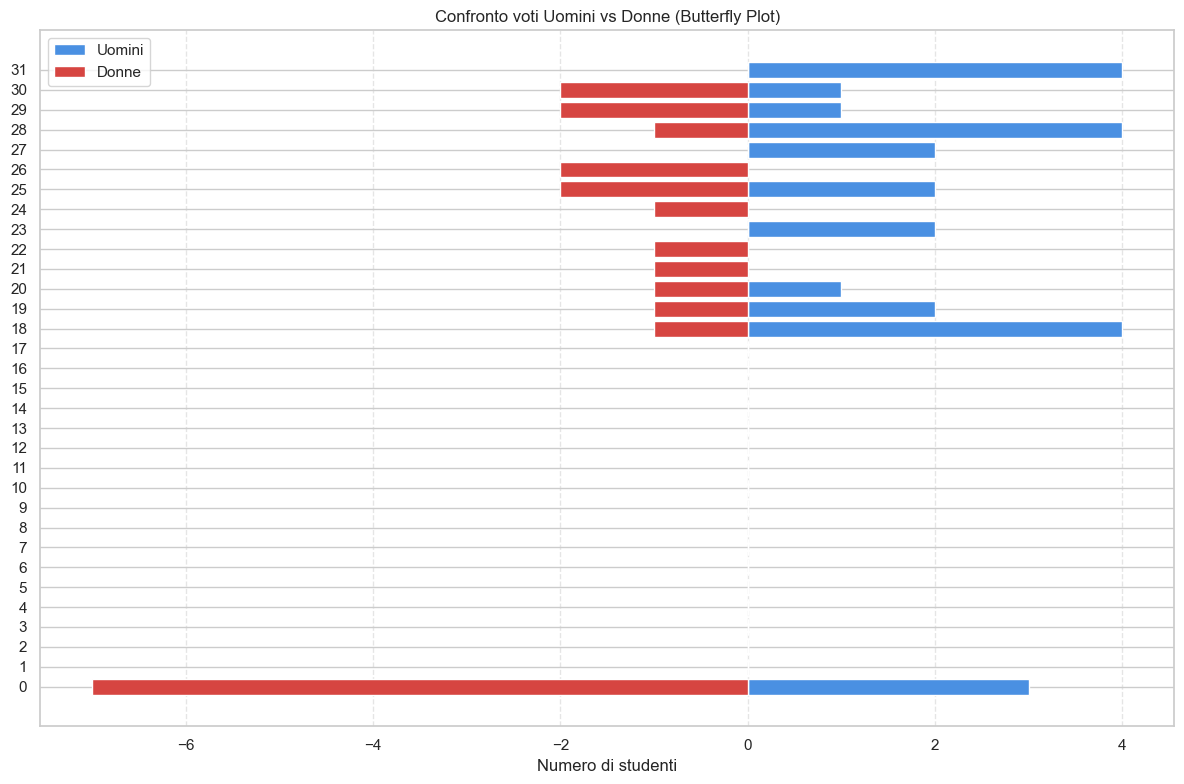

In [134]:
import gender_guesser.detector as gender
import numpy as np
import matplotlib.pyplot as plt

# Creiamo il detector
detector = gender.Detector(case_sensitive=False)

# Funzione per stimare sesso da nome
def get_gender(name):
    # Prendiamo solo il primo nome
    primo = str(name).split()[0]
    g = detector.get_gender(primo)
    if g in ["male", "mostly_male"]:
        return "Uomo"
    elif g in ["female", "mostly_female"]:
        return "Donna"
    else:
        return "Indeterminato"

# Applichiamo al DataFrame
df_appelli["Sesso"] = df_appelli["Nome"].apply(get_gender)

# Filtriamo solo voti validi e non indeterminati
df_gender = df_appelli[
    (df_appelli["Voto_num"] >= 0) &
    (df_appelli["Sesso"].isin(["Uomo", "Donna"]))
].copy()

# Conta voti maschili e femminili
count_uomo = df_gender[df_gender["Sesso"]=="Uomo"]["Voto_num"].value_counts().sort_index()
count_donna = df_gender[df_gender["Sesso"]=="Donna"]["Voto_num"].value_counts().sort_index()

# Range voti
voti_range = np.arange(0, 32)

# Prepariamo i vettori per il butterfly
u_vals = [count_uomo.get(v, 0) for v in voti_range]
d_vals = [count_donna.get(v, 0) for v in voti_range]

plt.figure(figsize=(12,8))

# Barre butterfly (specchiate)
plt.barh(voti_range, u_vals, color="#4A90E2", label="Uomini")
plt.barh(voti_range, [-x for x in d_vals], color="#D64541", label="Donne")

plt.yticks(voti_range)
plt.xlabel("Numero di studenti")
plt.title("Confronto voti Uomini vs Donne (Butterfly Plot)")
plt.legend()

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [141]:
import requests
import pandas as pd

# Estrai solo il primo nome
df_appelli["PrimoNome"] = df_appelli["Nome"].apply(lambda n: str(n).split()[0])

# Prendi solo nomi unici
nomi_unici = df_appelli["PrimoNome"].unique()

# Funzione per chiamare Genderize
def genderize_query(name):
    url = f"https://api.genderize.io?name={name}"
    try:
        r = requests.get(url)
        if r.status_code == 200:
            return r.json()
        else:
            return None
    except:
        return None

# Mappatura dei nomi → sesso
gender_map = {}
for nome in nomi_unici:
    res = genderize_query(nome)
    if res and res["gender"]:
        if float(res["probability"]) >= 0.51:
            gender_map[nome] = "Uomo" if res["gender"]=="male" else "Donna"
        else:
            gender_map[nome] = "Indeterminato"
    else:
        gender_map[nome] = "Indeterminato"

# Applica mappatura al DataFrame
df_appelli["Sesso"] = df_appelli["PrimoNome"].map(gender_map)

# Filtra solo voti validi e sesso determinato
df_gender = df_appelli[(df_appelli["Voto_num"] >= 0) & (df_appelli["Sesso"].isin(["Uomo","Donna"]))]

df_gender.head()

,Matricola,Nome,Esito,Appello,Voto_num,Voto_precedente,Tipo_ripetizione,Delta_voto,Sesso,PrimoNome


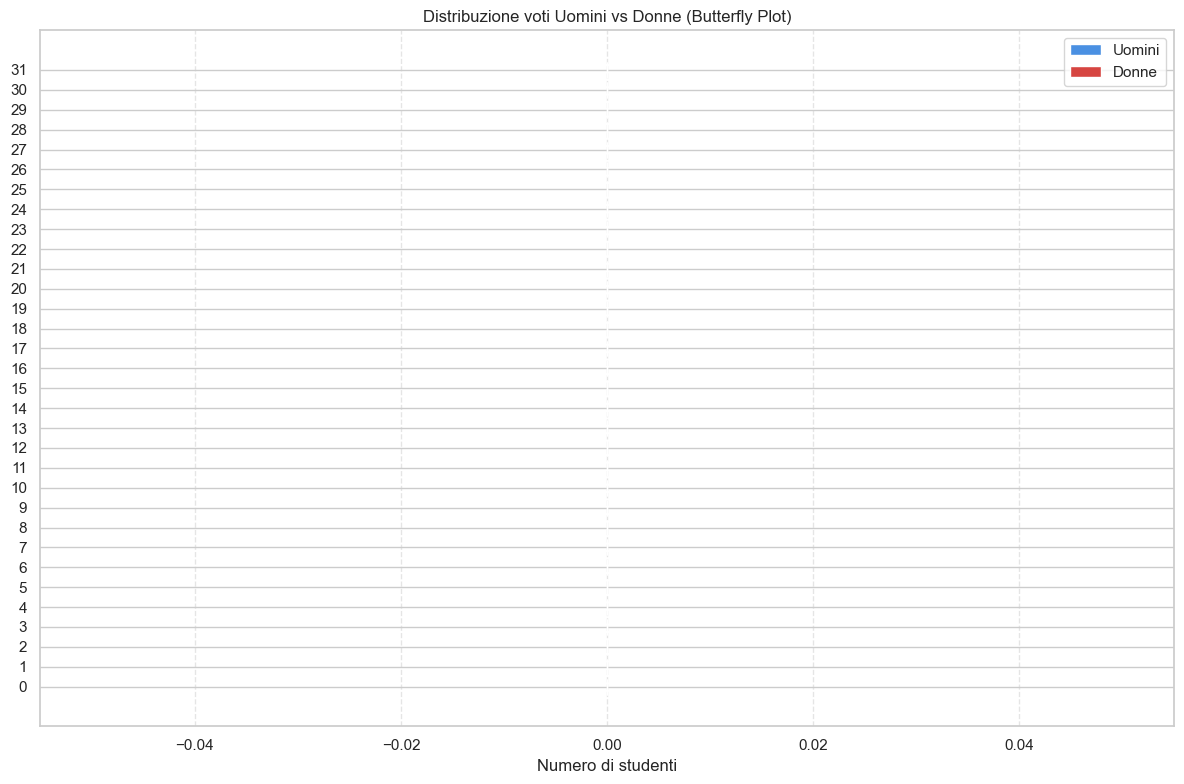

In [139]:
import matplotlib.pyplot as plt

count_uomo = df_gender[df_gender["Sesso"]=="Uomo"]["Voto_num"].value_counts().sort_index()
count_donna = df_gender[df_gender["Sesso"]=="Donna"]["Voto_num"].value_counts().sort_index()

voti_range = np.arange(0, 32)

u_vals = [count_uomo.get(v, 0) for v in voti_range]
d_vals = [count_donna.get(v, 0) for v in voti_range]

plt.figure(figsize=(12,8))

plt.barh(voti_range, u_vals, color="#4A90E2", label="Uomini")
plt.barh(voti_range, [-x for x in d_vals], color="#D64541", label="Donne")

plt.yticks(voti_range)
plt.xlabel("Numero di studenti")
plt.title("Distribuzione voti Uomini vs Donne (Butterfly Plot)")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

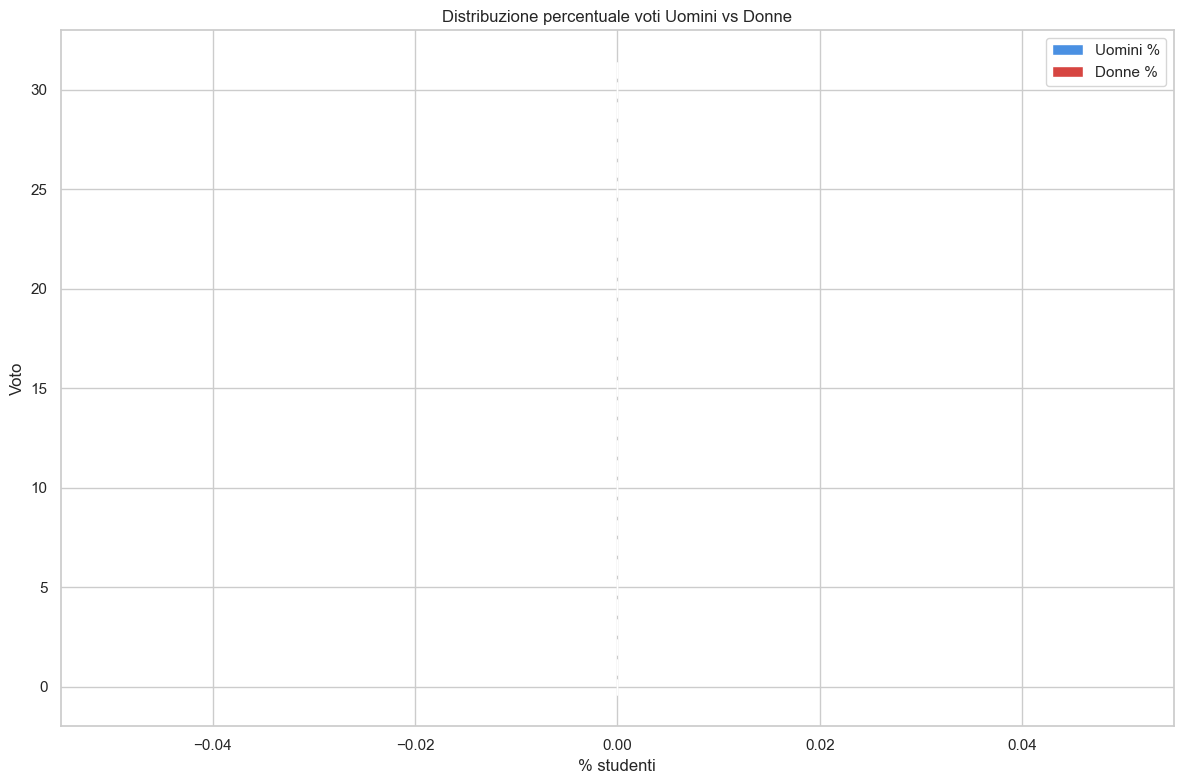

In [140]:
tot_u = sum(u_vals) if sum(u_vals)>0 else 1
tot_d = sum(d_vals) if sum(d_vals)>0 else 1

u_perc = [100*x/tot_u for x in u_vals]
d_perc = [100*x/tot_d for x in d_vals]

plt.figure(figsize=(12,8))
plt.barh(voti_range, u_perc, color="#4A90E2", label="Uomini %")
plt.barh(voti_range, [-x for x in d_perc], color="#D64541", label="Donne %")

plt.ylabel("Voto")
plt.xlabel("% studenti")
plt.title("Distribuzione percentuale voti Uomini vs Donne")
plt.legend()
plt.tight_layout()
plt.show()

In [142]:
# Tutti i nomi unici
print("Nomi unici:", df_appelli["PrimoNome"].unique())

# Mappa dei generi
print("Gender map:", gender_map)

Nomi unici: ['MATTEO' 'LUCA' 'GIOVANNI' 'ANDREA' 'ALESSIA' 'ALESSANDRO' 'CIRO'
 'FEDERICO' 'LUCIA' 'ALICE' 'BIANCA' 'LORENZO' 'EMANUELE' 'CHIARA' 'GIGI'
 'MANUEL' 'MATILDE' 'ANNA' 'EMMA' 'ARTURO' 'GIAN' 'SEBASTIANO' 'MARCO'
 'FRANCO' 'PAOLO' 'ELISA' 'GIULIA' 'MARTA' 'SIMONE' 'NICOLA' 'MIRCO'
 'NOEMI' 'ROSA' 'MARIANNA']
Gender map: {'MATTEO': 'Indeterminato', 'LUCA': 'Indeterminato', 'GIOVANNI': 'Indeterminato', 'ANDREA': 'Indeterminato', 'ALESSIA': 'Indeterminato', 'ALESSANDRO': 'Indeterminato', 'CIRO': 'Indeterminato', 'FEDERICO': 'Indeterminato', 'LUCIA': 'Indeterminato', 'ALICE': 'Indeterminato', 'BIANCA': 'Indeterminato', 'LORENZO': 'Indeterminato', 'EMANUELE': 'Indeterminato', 'CHIARA': 'Indeterminato', 'GIGI': 'Indeterminato', 'MANUEL': 'Indeterminato', 'MATILDE': 'Indeterminato', 'ANNA': 'Indeterminato', 'EMMA': 'Indeterminato', 'ARTURO': 'Indeterminato', 'GIAN': 'Indeterminato', 'SEBASTIANO': 'Indeterminato', 'MARCO': 'Indeterminato', 'FRANCO': 'Indeterminato', 'PAOLO': 'Indete

In [151]:
# --- 1️⃣ Import ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import gender_guesser.detector as gender
from scipy.interpolate import make_interp_spline

sns.set_theme(style="whitegrid")

# --- 2️⃣ Funzione per normalizzare i nomi ---
def normalize_name(nome):
    if not isinstance(nome, str) or nome.strip() == "":
        return ""
    nome = nome.strip().split()[0]
    nome = re.sub(r"[^A-Za-zÀ-ÖØ-öø-ÿ]", "", nome)
    return nome.capitalize()

# --- 3️⃣ Caricamento file Excel ---
files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
    "Esempio_Appello (C3).xlsx"
]

df_finale = pd.DataFrame()
for f in files:
    key = f.split("(")[1].split(")")[0]
    df = pd.read_excel(f, usecols="E,H", skiprows=20, names=["Nome","Voto"])
    df["Nome_norm"] = df["Nome"].apply(normalize_name)
    df["Appello"] = key
    df_finale = pd.concat([df_finale, df], ignore_index=True)

# --- 4️⃣ Debug nomi normalizzati ---
print("Nomi normalizzati unici:", df_finale["Nome_norm"].unique())

# --- 5️⃣ Gender con gender_guesser ---
d = gender.Detector()

def detect_gender(name):
    g = d.get_gender(name)
    return g

df_finale["Genere_raw_debug"] = df_finale["Nome_norm"].apply(detect_gender)

# --- 6️⃣ Debug valori gender_guesser ---
print("\nValori raw gender_guesser:")
print(df_finale[["Nome_norm","Genere_raw_debug"]].drop_duplicates().sort_values("Nome_norm"))

# --- 7️⃣ Mappatura finale con Unknown ---
def map_gender(g):
    if g in ["male","mostly_male"]:
        return "M"
    elif g in ["female","mostly_female"]:
        return "F"
    else:
        return "Unknown"

df_finale["Genere"] = df_finale["Genere_raw_debug"].apply(map_gender)

print("\nConteggio generi dopo mappatura:", df_finale["Genere"].value_counts())

# --- 8️⃣ Colonna voto numerico ---
df_finale["Voto_num"] = pd.to_numeric(df_finale["Voto"], errors="coerce")

# --- 9️⃣ Debug voti e generi validi ---
df_gender_plot = df_finale[df_finale["Voto_num"].notna() & df_finale["Genere"].isin(["M","F"])]
print("\nPrime righe del dataset finale filtrato per grafico:")
print(df_gender_plot.head(15))
print("\nConteggio generi filtrati per grafico:", df_gender_plot["Genere"].value_counts())

Nomi normalizzati unici: ['Matteo' 'Luca' 'Giovanni' 'Andrea' 'Alessia' 'Alessandro' 'Ciro'
 'Federico' 'Lucia' 'Alice' 'Bianca' 'Lorenzo' 'Emanuele' 'Chiara' 'Gigi'
 'Manuel' 'Matilde' 'Anna' 'Emma' 'Arturo' 'Gian' 'Sebastiano' 'Marco'
 'Franco' 'Paolo' 'Elisa' 'Giulia' 'Marta' 'Simone' 'Nicola' 'Mirco'
 'Noemi' 'Rosa' 'Marianna']

Valori raw gender_guesser:
     Nome_norm Genere_raw_debug
5   Alessandro             male
4      Alessia           female
9        Alice           female
3       Andrea           female
17        Anna           female
26      Arturo             male
10      Bianca           female
13      Chiara           female
6         Ciro             male
39       Elisa           female
12    Emanuele             male
18        Emma           female
7     Federico             male
33      Franco             male
28        Gian             male
14        Gigi             male
2     Giovanni             male
41      Giulia           female
11     Lorenzo             mal

M: 27 F: 14

Conteggio finale generi con Unknown gestiti:
Genere_finale
M    27
F    14
Name: count, dtype: int64


C:\Users\alice\AppData\Local\Temp\ipykernel_24120\1998158525.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gender_plot["Genere_finale"] = df_gender_plot["Genere"].apply(fill_unknown)


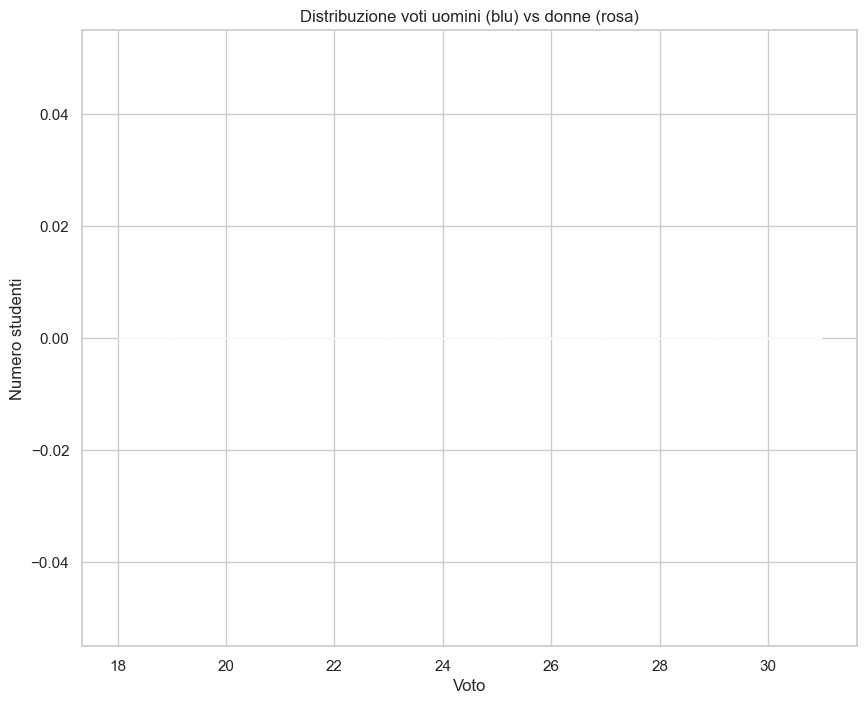

In [152]:
# --- 10️⃣ Gestione Unknown proporzionale ---
df_gender_plot = df_finale[df_finale["Voto_num"].notna()]
m_count = sum(df_gender_plot["Genere"]=="M")
f_count = sum(df_gender_plot["Genere"]=="F")
total_known = m_count + f_count

print("M:", m_count, "F:", f_count)

# soglia maggioranza schiacciante
threshold = 0.6
if total_known > 0:
    m_ratio = m_count/total_known
    f_ratio = f_count/total_known
else:
    m_ratio = f_ratio = 0.5

def fill_unknown(g):
    if g != "Unknown":
        return g
    # caso maggioranza schiacciante
    if m_ratio >= threshold:
        return "M"
    elif f_ratio >= threshold:
        return "F"
    else:
        return np.random.choice(["M","F"])  # quasi pari distribuzione

df_gender_plot["Genere_finale"] = df_gender_plot["Genere"].apply(fill_unknown)

print("\nConteggio finale generi con Unknown gestiti:")
print(df_gender_plot["Genere_finale"].value_counts())

# --- 11️⃣ Grafico farfalla ---
plt.figure(figsize=(10,8))
sns.histplot(df_gender_plot[df_gender_plot["Genere_finale"]=="M"]["Voto_num"],
             color="skyblue", binrange=(18,31), binwidth=1, kde=False)
sns.histplot(df_gender_plot[df_gender_plot["Genere_finale"]=="F"]["Voto_num"],
             color="salmon", binrange=(18,31), binwidth=1, kde=False)
plt.title("Distribuzione voti uomini (blu) vs donne (rosa)")
plt.xlabel("Voto")
plt.ylabel("Numero studenti")
plt.show()

Colonne disponibili: Index(['Nome', 'Voto', 'Nome_norm', 'Appello', 'Genere_raw_debug', 'Genere',
       'Voto_num'],
      dtype='object')
Prime 10 righe:
         Nome      Voto   Nome_norm Appello Genere_raw_debug Genere  Voto_num
0      MATTEO  224183.0      Matteo      C1             male      M  224183.0
1        LUCA  224375.0        Luca      C1             male      M  224375.0
2    GIOVANNI  212383.0    Giovanni      C1             male      M  212383.0
3      ANDREA  223243.0      Andrea      C1           female      F  223243.0
4     ALESSIA  224981.0     Alessia      C1           female      F  224981.0
5  ALESSANDRO  225616.0  Alessandro      C1             male      M  225616.0
6        CIRO  226295.0        Ciro      C1             male      M  226295.0
7    FEDERICO  215477.0    Federico      C1             male      M  215477.0
8       LUCIA  223989.0       Lucia      C1           female      F  223989.0
9       ALICE  204444.0       Alice      C1           female    

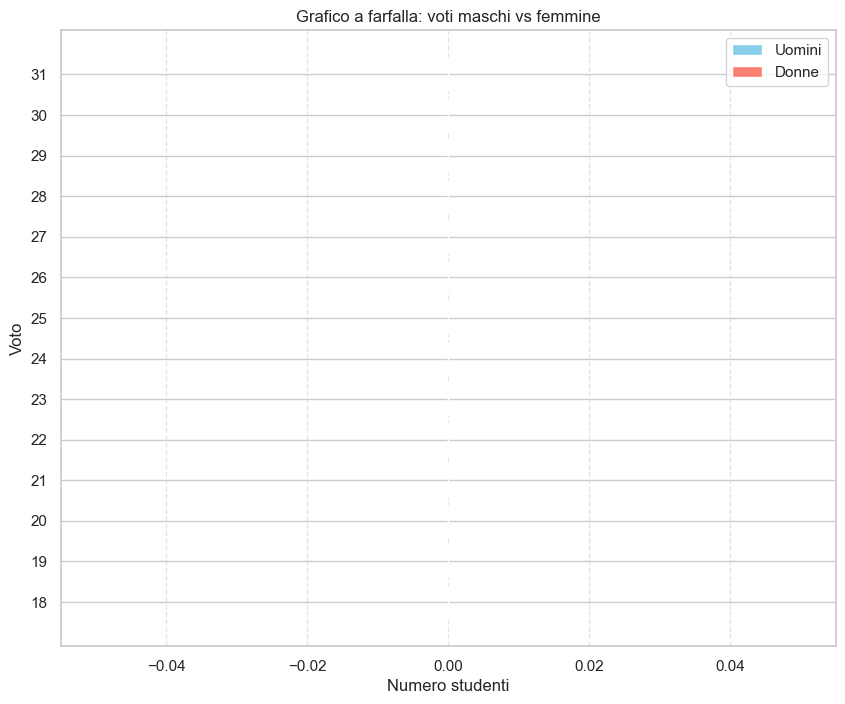

In [154]:
# 1️⃣ Controllo dati
print("Colonne disponibili:", df_finale.columns)
print("Prime 10 righe:")
print(df_finale.head(10))

# Assicurati di avere Voto_num
if "Voto_num" not in df_finale.columns:
    df_finale["Voto_num"] = pd.to_numeric(df_finale["Voto"], errors="coerce")

# 2️⃣ Gestione Unknown proporzionale
df_gender_plot = df_finale[df_finale["Voto_num"].notna()].copy()

m_count = sum(df_gender_plot["Genere"]=="M")
f_count = sum(df_gender_plot["Genere"]=="F")
total_known = m_count + f_count
threshold = 0.6

m_ratio = m_count/total_known if total_known>0 else 0.5
f_ratio = f_count/total_known if total_known>0 else 0.5

def fill_unknown(g):
    if g != "Unknown":
        return g
    if m_ratio >= threshold:
        return "M"
    elif f_ratio >= threshold:
        return "F"
    else:
        return np.random.choice(["M","F"])

df_gender_plot["Genere_finale"] = df_gender_plot["Genere"].apply(fill_unknown)

print("\nConteggio finale generi con Unknown gestiti:")
print(df_gender_plot["Genere_finale"].value_counts())

# 3️⃣ Debug voti
print("\nVoti uomini:")
print(df_gender_plot[df_gender_plot["Genere_finale"]=="M"]["Voto_num"].values)
print("Voti donne:")
print(df_gender_plot[df_gender_plot["Genere_finale"]=="F"]["Voto_num"].values)

# 4️⃣ Grafico farfalla
voti_range = np.arange(18,32)
m_vals = df_gender_plot[df_gender_plot["Genere_finale"]=="M"]["Voto_num"].value_counts().reindex(voti_range, fill_value=0)
f_vals = df_gender_plot[df_gender_plot["Genere_finale"]=="F"]["Voto_num"].value_counts().reindex(voti_range, fill_value=0)

plt.figure(figsize=(10,8))
plt.barh(voti_range, -m_vals, color="skyblue", label="Uomini")
plt.barh(voti_range, f_vals, color="salmon", label="Donne")

plt.yticks(voti_range)
plt.xlabel("Numero studenti")
plt.ylabel("Voto")
plt.title("Grafico a farfalla: voti maschi vs femmine")
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

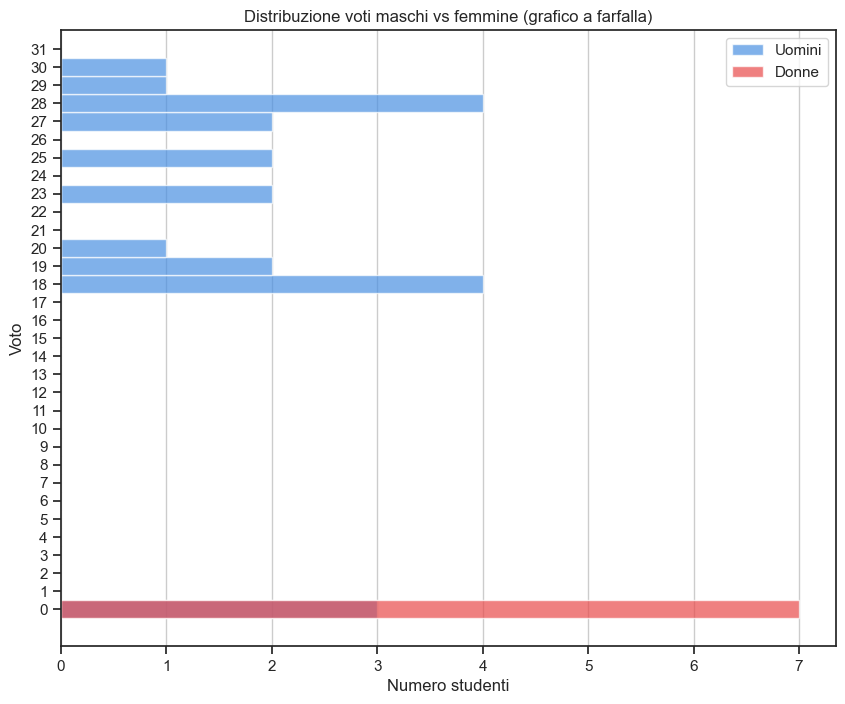

In [155]:
# --- 1️⃣ Import ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from gender_guesser import detector as gender_detector

sns.set_theme(style="ticks")

# --- 2️⃣ Parametri ---
files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
    "Esempio_Appello (C3).xlsx"
]

# Colonne dei dati nel file Excel
colonna_nome = "E"
colonna_voto = "I"
skip_rows = 20

# --- 3️⃣ Funzioni helper ---
def normalize_name(nome):
    """Prende il primo nome, rimuove caratteri strani e capitalizza."""
    if not isinstance(nome, str) or nome.strip() == "":
        return ""
    nome = nome.strip().split()[0]
    nome = re.sub(r"[^A-Za-zÀ-ÖØ-öø-ÿ]", "", nome)
    return nome.capitalize()

def pulisci_voto(v):
    """Converte il voto in numero valido, trasforma 30L->31"""
    try:
        if pd.isna(v):
            return np.nan
        v_str = str(v).strip().upper()
        if v_str in ["RIT", "ASS"]:
            return np.nan
        return float(v_str.replace("30L","31"))
    except:
        return np.nan

# --- 4️⃣ Leggi e concatena tutti i file ---
df_finale = pd.DataFrame()

for f in files:
    key = f.split("(")[1].split(")")[0]  # appello C1, C2...
    df = pd.read_excel(f, usecols=f"{colonna_nome},{colonna_voto}", skiprows=skip_rows, names=["Nome","Voto"])
    df["Nome_norm"] = df["Nome"].apply(normalize_name)
    df["Voto_num"] = df["Voto"].apply(pulisci_voto)
    df["Appello"] = key
    df_finale = pd.concat([df_finale, df], ignore_index=True)

# --- 5️⃣ Determina sesso con gender_guesser ---
detector = gender_detector.Detector(case_sensitive=False)

def gender_guess(name):
    if not name:
        return "Unknown"
    g = detector.get_gender(name)
    if g in ["male","mostly_male"]:
        return "M"
    elif g in ["female","mostly_female"]:
        return "F"
    else:
        return "Unknown"

df_finale["Genere_raw"] = df_finale["Nome_norm"].apply(gender_guess)

# --- 6️⃣ Gestione proporzionale Unknown ---
count_M = (df_finale["Genere_raw"]=="M").sum()
count_F = (df_finale["Genere_raw"]=="F").sum()
total_known = count_M + count_F

if total_known == 0:
    ratio_M = ratio_F = 0.5
else:
    ratio_M = count_M / total_known
    ratio_F = count_F / total_known

def assign_final_genre(g):
    if g != "Unknown":
        return g
    # Unknown distribuiti proporzionalmente
    if ratio_M >= 0.7:  # maggioranza schiacciante
        return "M"
    elif ratio_F >= 0.7:
        return "F"
    else:
        # metà metà
        return np.random.choice(["M","F"])

df_finale["Genere"] = df_finale["Genere_raw"].apply(assign_final_genre)

# --- 7️⃣ Filtra solo voti validi per grafico ---
df_plot = df_finale.dropna(subset=["Voto_num"])
df_plot = df_plot[df_plot["Genere"].isin(["M","F"])]

voti_M = df_plot[df_plot["Genere"]=="M"]["Voto_num"].values
voti_F = df_plot[df_plot["Genere"]=="F"]["Voto_num"].values

# --- 8️⃣ Grafico Farfalla ---
plt.figure(figsize=(10,8))
bins = np.arange(0, 32) - 0.5  # da 0 a 31
plt.hist(voti_M, bins=bins, alpha=0.7, label="Uomini", orientation='horizontal', color="#4A90E2")
plt.hist([-v for v in voti_F], bins=bins, alpha=0.7, label="Donne", orientation='horizontal', color="#E94A4A")  # specchiato

plt.yticks(np.arange(0,32,1))
plt.xlabel("Numero studenti")
plt.ylabel("Voto")
plt.title("Distribuzione voti maschi vs femmine (grafico a farfalla)")
plt.legend()
plt.grid(axis='x')
plt.show()

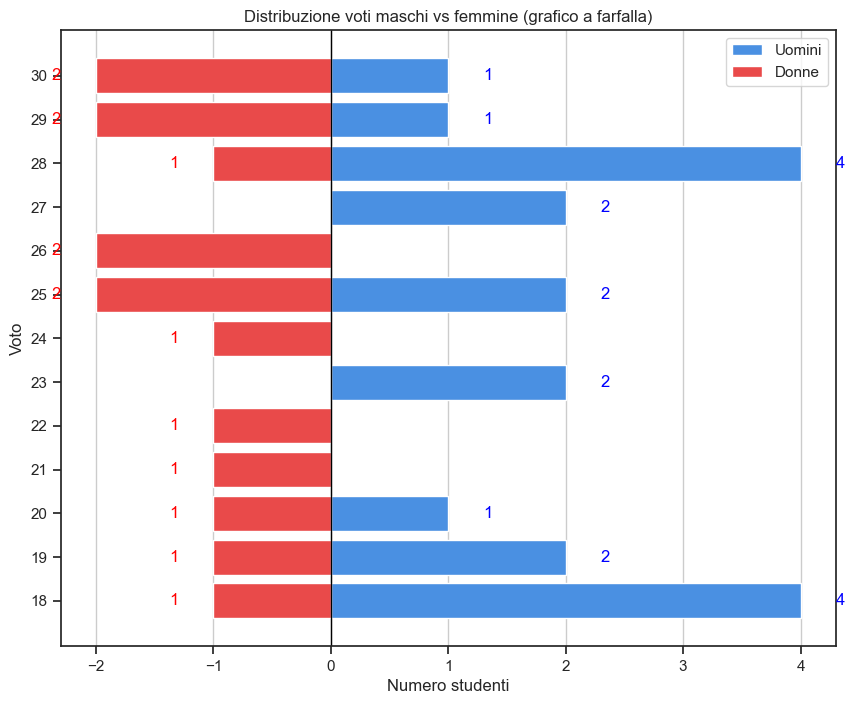

In [156]:
# --- Grafico Farfalla corretto ---
plt.figure(figsize=(10,8))

# Controlliamo range voti
voti_range = np.arange(18,32)

# Conta frequenze
freq_M, _ = np.histogram(voti_M, bins=voti_range-0.5)
freq_F, _ = np.histogram(voti_F, bins=voti_range-0.5)

# Disegna le barre: maschi a destra, femmine a sinistra (negative)
plt.barh(voti_range[:-1], freq_M, color="#4A90E2", label="Uomini")
plt.barh(voti_range[:-1], -freq_F, color="#E94A4A", label="Donne")

# Etichette numeriche
for i, v in enumerate(freq_M):
    if v>0:
        plt.text(v+0.3, voti_range[i], str(v), va='center', color='blue')
for i, v in enumerate(freq_F):
    if v>0:
        plt.text(-v-0.3, voti_range[i], str(v), va='center', ha='right', color='red')

plt.yticks(voti_range[:-1])
plt.xlabel("Numero studenti")
plt.ylabel("Voto")
plt.title("Distribuzione voti maschi vs femmine (grafico a farfalla)")
plt.legend()
plt.grid(axis='x')

# Centratura asse X
plt.axvline(0, color='black', linewidth=1)
plt.show()

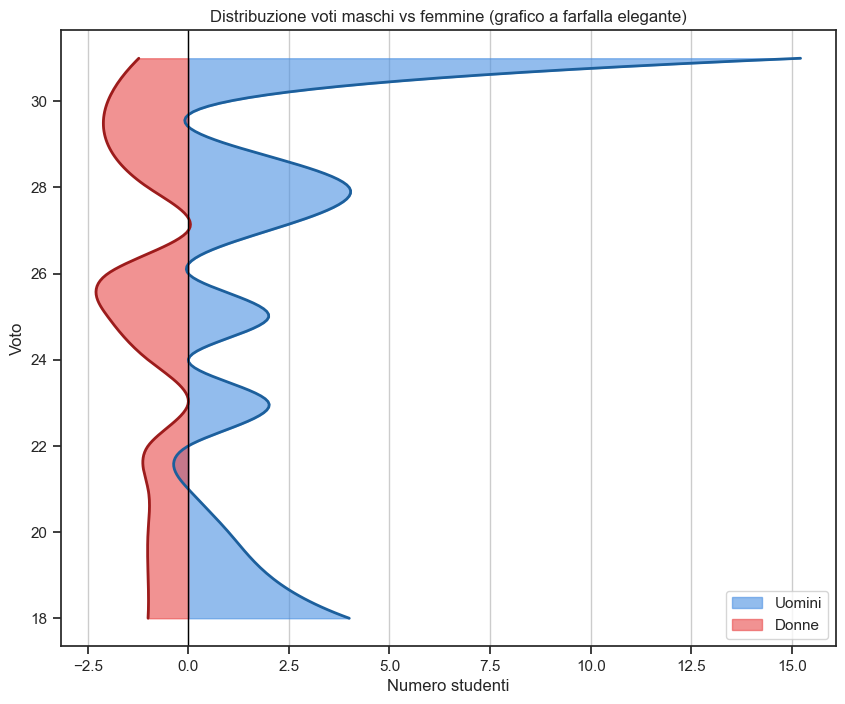

In [157]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# --- Preparazione dati ---
voti_range = np.arange(18,32)  # voti 18-31
freq_M, _ = np.histogram(voti_M, bins=voti_range-0.5)
freq_F, _ = np.histogram(voti_F, bins=voti_range-0.5)

# Assicuriamoci che siano float per interpolazione
freq_M = freq_M.astype(float)
freq_F = freq_F.astype(float)

# --- Interpolazione spline per linee morbide ---
x_new = np.linspace(18,31,200)  # range continuo per smooth
spl_M = make_interp_spline(voti_range[:-1], freq_M, k=3)
spl_F = make_interp_spline(voti_range[:-1], freq_F, k=3)

smooth_M = spl_M(x_new)
smooth_F = spl_F(x_new)

# --- Grafico ---
plt.figure(figsize=(10,8))

# Aree specchiate
plt.fill_betweenx(x_new, 0, smooth_M, color="#4A90E2", alpha=0.6, label="Uomini")
plt.fill_betweenx(x_new, 0, -smooth_F, color="#E94A4A", alpha=0.6, label="Donne")

# Linee di contorno
plt.plot(smooth_M, x_new, color="#1C5F9C", linewidth=2)
plt.plot(-smooth_F, x_new, color="#9C1C1C", linewidth=2)

# Centratura asse X
plt.axvline(0, color='black', linewidth=1)

# Etichette e titolo
plt.xlabel("Numero studenti")
plt.ylabel("Voto")
plt.title("Distribuzione voti maschi vs femmine (grafico a farfalla elegante)")
plt.legend()
plt.grid(axis='x')

plt.show()

In [167]:
df_finale.columns

Index(['Matricola', 'Nome', 'Voto', 'Nome_norm', 'Voto_num', 'Appello'], dtype='object')

In [168]:
# --- 1️⃣ Ordina per studente ---
df_finale = pd.DataFrame()

for f in files:
    key = f.split("(")[1].split(")")[0]

    df = pd.read_excel(
        f,
        usecols="B,D,I",
        skiprows=20,
        names=["Matricola", "Nome", "Voto"]
    )

    df["Nome_norm"] = df["Nome"].apply(normalize_name)
    df["Voto_num"] = df["Voto"].apply(pulisci_voto)
    df["Appello"] = key

    df_finale = pd.concat([df_finale, df], ignore_index=True)
import gender_guesser.detector as gender

d = gender.Detector(case_sensitive=False)

def detect_gender(name):
    if not isinstance(name, str) or name.strip() == "":
        return "Unknown"
    name = name.strip().split()[0].capitalize()
    g = d.get_gender(name)
    
    if g in ["male","mostly_male"]:
        return "M"
    elif g in ["female","mostly_female"]:
        return "F"
    else:
        return "Unknown"

df_finale["Genere"] = df_finale["Nome"].apply(detect_gender)

# Debug
print(df_finale["Genere"].value_counts())
df_ord = df_finale.sort_values(["Matricola", "Appello"]).reset_index(drop=True)


# --- 2️⃣ Voto precedente ---
df_ord["Voto_precedente"] = df_ord.groupby("Matricola")["Voto_num"].shift(1)

# --- 3️⃣ Identifica rifiuto ---
df_ord["Rifiuto"] = (
    (df_ord["Voto_precedente"] >= 18) &  # voto valido
    (df_ord["Voto_num"].notna())         # ha rifatto l'esame
)

# --- 4️⃣ Filtra solo casi con voto precedente valido ---
df_rifiuti = df_ord[df_ord["Voto_precedente"].notna()]

# --- 5️⃣ Conta per genere ---
rifiuti_genere = df_rifiuti.groupby("Genere")["Rifiuto"].sum()
totali_genere = df_rifiuti.groupby("Genere")["Rifiuto"].count()

percentuali = (rifiuti_genere / totali_genere) * 100

print("Rifiuti per genere:")
print(rifiuti_genere)

print("\nTotali per genere:")
print(totali_genere)

print("\nPercentuale rifiuti:")
print(percentuali)

Genere
Unknown    45
F           5
M           5
Name: count, dtype: int64
Rifiuti per genere:
Series([], Name: Rifiuto, dtype: int64)

Totali per genere:
Series([], Name: Rifiuto, dtype: int64)

Percentuale rifiuti:
Series([], Name: Rifiuto, dtype: float64)


Colonne: Index(['Matricola', 'Nome', 'Voto', 'Nome_norm', 'Voto_num', 'Appello',
       'Genere_raw', 'Genere'],
      dtype='object')
   Matricola     Nome Voto Nome_norm  Voto_num Appello Genere_raw Genere
0        NaN    ROSSI    0     Rossi       0.0      C1    Unknown      M
1        NaN  BIANCHI   18   Bianchi      18.0      C1    Unknown      M
2        NaN   GIALLI   25    Gialli      25.0      C1    Unknown      F
3        NaN    DA RE   28        Da      28.0      C1    Unknown      M
4        NaN   PICCIN   30    Piccin      30.0      C1    Unknown      F

Distribuzione genere:
Genere
M    30
F    25
Name: count, dtype: int64

Rifiuti per genere:
Series([], Name: Rifiuto, dtype: int64)

Percentuali:
Series([], Name: Rifiuto, dtype: float64)


IndexError: index 0 is out of bounds for axis 0 with size 0

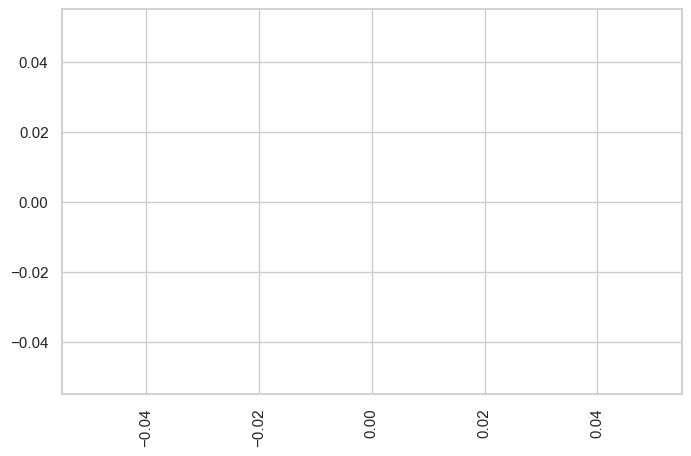

In [170]:
# --- 1️⃣ Import ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import gender_guesser.detector as gender

sns.set_theme(style="whitegrid")

# --- 2️⃣ Parametri ---
files = [
    "Esempio_Appello (C1).xlsx",
    "Esempio_Appello (C2).xlsx",
    "Esempio_Appello (C3).xlsx"
]

# --- 3️⃣ Funzioni helper ---
def normalize_name(nome):
    if not isinstance(nome, str) or nome.strip() == "":
        return ""
    nome = nome.strip().split()[0]
    nome = re.sub(r"[^A-Za-zÀ-ÖØ-öø-ÿ]", "", nome)
    return nome.capitalize()

def pulisci_voto(v):
    try:
        if pd.isna(v):
            return np.nan
        v_str = str(v).strip().upper()
        if v_str in ["RIT", "ASS"]:
            return np.nan
        return float(v_str.replace("30L","31"))
    except:
        return np.nan

# --- 4️⃣ Caricamento dati con Matricola ---
df_finale = pd.DataFrame()

for f in files:
    key = f.split("(")[1].split(")")[0]

    df = pd.read_excel(
        f,
        usecols="B,D,I",  # Matricola, Nome, Voto
        skiprows=20,
        names=["Matricola", "Nome", "Voto"]
    )

    df["Nome_norm"] = df["Nome"].apply(normalize_name)
    df["Voto_num"] = df["Voto"].apply(pulisci_voto)
    df["Appello"] = key

    df_finale = pd.concat([df_finale, df], ignore_index=True)

# --- 5️⃣ Gender ---
d = gender.Detector(case_sensitive=False)

def detect_gender(name):
    if not isinstance(name, str) or name.strip() == "":
        return "Unknown"
    name = name.strip().split()[0].capitalize()
    g = d.get_gender(name)
    
    if g in ["male","mostly_male"]:
        return "M"
    elif g in ["female","mostly_female"]:
        return "F"
    else:
        return "Unknown"

df_finale["Genere_raw"] = df_finale["Nome"].apply(detect_gender)

# --- 6️⃣ Gestione Unknown proporzionale ---
count_M = (df_finale["Genere_raw"]=="M").sum()
count_F = (df_finale["Genere_raw"]=="F").sum()
total_known = count_M + count_F

ratio_M = count_M / total_known if total_known > 0 else 0.5
ratio_F = count_F / total_known if total_known > 0 else 0.5

def assign_genere(g):
    if g != "Unknown":
        return g
    if ratio_M >= 0.7:
        return "M"
    elif ratio_F >= 0.7:
        return "F"
    else:
        return np.random.choice(["M","F"])

df_finale["Genere"] = df_finale["Genere_raw"].apply(assign_genere)

# --- DEBUG ---
print("Colonne:", df_finale.columns)
print(df_finale.head())
print("\nDistribuzione genere:")
print(df_finale["Genere"].value_counts())

# --- 7️⃣ Analisi rifiuti ---
df_ord = df_finale.sort_values(by=["Matricola", "Appello"])

df_ord["Voto_precedente"] = df_ord.groupby("Matricola")["Voto_num"].shift(1)

df_ord["Rifiuto"] = (
    (df_ord["Voto_precedente"] >= 18) &
    (df_ord["Voto_num"].notna())
)

df_rifiuti = df_ord[df_ord["Voto_precedente"].notna()]

# --- 8️⃣ Statistiche ---
rifiuti_genere = df_rifiuti.groupby("Genere")["Rifiuto"].sum()
totali_genere = df_rifiuti.groupby("Genere")["Rifiuto"].count()
percentuali = (rifiuti_genere / totali_genere) * 100

print("\nRifiuti per genere:")
print(rifiuti_genere)

print("\nPercentuali:")
print(percentuali)

# --- 9️⃣ Grafico ---
plt.figure(figsize=(8,5))

percentuali.plot(kind="bar", color=["#4A90E2","#E94A4A"])

plt.title("Chi rifiuta di più (percentuale)")
plt.ylabel("Percentuale (%)")
plt.xlabel("Genere")

for i, v in enumerate(percentuali):
    plt.text(i, v+1, f"{v:.1f}%", ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [171]:
print("\n--- DEBUG ---")
print("Totale righe:", len(df_ord))
print("Righe con voto precedente:", df_ord["Voto_precedente"].notna().sum())
print("Righe rifiuti:", df_ord["Rifiuto"].sum())

print("\ndf_rifiuti:")
print(df_rifiuti.head())

print("\nConteggio per genere:")
print(df_rifiuti["Genere"].value_counts())


--- DEBUG ---
Totale righe: 55
Righe con voto precedente: 0
Righe rifiuti: 0

df_rifiuti:
Empty DataFrame
Columns: [Matricola, Nome, Voto, Nome_norm, Voto_num, Appello, Genere_raw, Genere, Voto_precedente, Rifiuto]
Index: []

Conteggio per genere:
Series([], Name: count, dtype: int64)


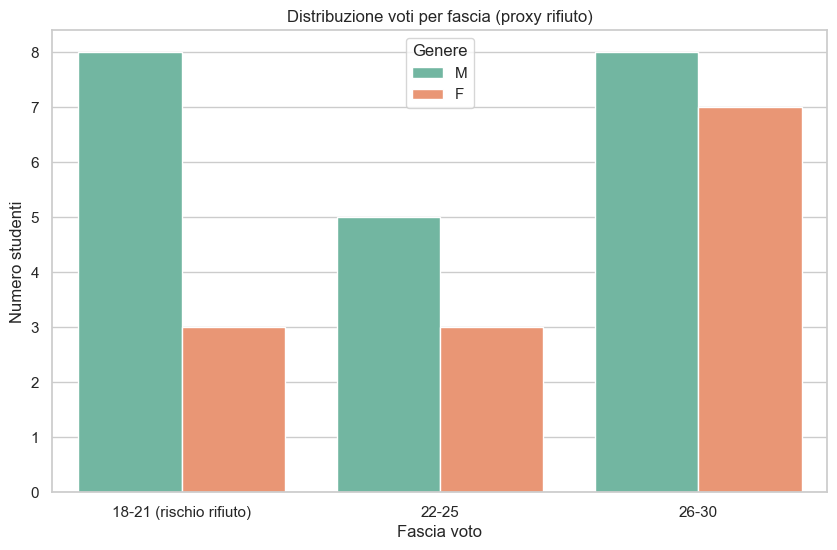

In [172]:
bins = [18, 22, 26, 31]
labels = ["18-21 (rischio rifiuto)", "22-25", "26-30"]

df_validi = df_finale[df_finale["Voto_num"].notna()]
df_validi = df_validi[df_validi["Voto_num"] >= 18]

df_validi["Classe_voto"] = pd.cut(df_validi["Voto_num"], bins=bins, labels=labels, right=False)

plt.figure(figsize=(10,6))
sns.countplot(data=df_validi, x="Classe_voto", hue="Genere", palette="Set2")

plt.title("Distribuzione voti per fascia (proxy rifiuto)")
plt.xlabel("Fascia voto")
plt.ylabel("Numero studenti")
plt.show()

## 19/3
anno in cui si da l'esame

In [173]:
df = pd.read_excel(
    f,
    usecols="B,D,F,I",  # Matricola, Nome, AnnoFreq, Voto
    skiprows=20,
    names=["Matricola", "Nome", "AnnoFreq", "Voto"]
)

In [176]:
def estrai_anno_inizio(anno_str):
    try:
        return int(str(anno_str).split("/")[0])
    except:
        return np.nan

df_finale["Anno_inizio"] = df_finale["Anno Freq."].apply(estrai_anno_inizio)

KeyError: 'Anno Freq.'

In [177]:
ANNO_APPELLO = 2024  # 🔥 CAMBIA SE SERVE

df_finale["Differenza_anni"] = ANNO_APPELLO - df_finale["Anno_inizio"]

KeyError: 'Anno_inizio'

In [178]:
import pandas as pd
import numpy as np
import re

df_finale = pd.DataFrame()

for f in files:
    # --- 1️⃣ Leggi anno appello da D10 ---
    header = pd.read_excel(f, nrows=10, header=None)
    raw_appello = header.iloc[9, 3]  # D10
    
    # DEBUG
    print(f"\nFile: {f}")
    print("Valore D10:", raw_appello)
    
    # --- 2️⃣ Estrai anno numerico ---
    match = re.search(r"\d{4}", str(raw_appello))
    anno_appello = int(match.group()) if match else np.nan
    
    print("Anno appello estratto:", anno_appello)

    # --- 3️⃣ Leggi tabella studenti ---
    df = pd.read_excel(
        f,
        usecols="B,D,F,I",
        skiprows=20,
        names=["Matricola", "Nome", "AnnoFreq", "Voto"]
    )

    # --- 4️⃣ Aggiungi info ---
    df["Anno_appello"] = anno_appello
    df["Nome_norm"] = df["Nome"].apply(normalize_name)
    df["Voto_num"] = df["Voto"].apply(pulisci_voto)
    df["Appello"] = f.split("(")[1].split(")")[0]

    df_finale = pd.concat([df_finale, df], ignore_index=True)

# --- 5️⃣ Estrai anno frequenza ---
def estrai_anno_inizio(anno_str):
    try:
        return int(str(anno_str).split("/")[0])
    except:
        return np.nan

df_finale["Anno_inizio"] = df_finale["AnnoFreq"].apply(estrai_anno_inizio)

# --- 6️⃣ Differenza anni ---
df_finale["Diff_anni"] = df_finale["Anno_appello"] - df_finale["Anno_inizio"]

# --- 7️⃣ Classificazione ---
def classifica(diff):
    if pd.isna(diff):
        return "Sconosciuto"
    elif diff == 0:
        return "In corso"
    elif diff > 0:
        return "In ritardo"
    else:
        return "Anticipo"

df_finale["Stato"] = df_finale["Diff_anni"].apply(classifica)

# --- DEBUG ---
print("\nControllo finale:")
print(df_finale[["AnnoFreq","Anno_appello","Diff_anni","Stato"]].head())

print("\nDistribuzione:")
print(df_finale["Stato"].value_counts())


File: Esempio_Appello (C1).xlsx
Valore D10: SESSIONE UNICA A.A. 2024/2025 [01/10/2024 - 30/04/2026]
Anno appello estratto: 2024

File: Esempio_Appello (C2).xlsx
Valore D10: SESSIONE UNICA A.A. 2024/2025 [01/10/2024 - 30/04/2026]
Anno appello estratto: 2024

File: Esempio_Appello (C3).xlsx
Valore D10: SESSIONE UNICA A.A. 2025/2026 [01/10/2025 - 30/04/2026]
Anno appello estratto: 2025

Controllo finale:
    AnnoFreq  Anno_appello  Diff_anni       Stato
0  2024/2025          2024          0    In corso
1  2024/2025          2024          0    In corso
2  2023/2024          2024          1  In ritardo
3  2024/2025          2024          0    In corso
4  2024/2025          2024          0    In corso

Distribuzione:
Stato
In corso      40
In ritardo    15
Name: count, dtype: int64


C:\Users\alice\AppData\Local\Temp\ipykernel_24120\3185362676.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


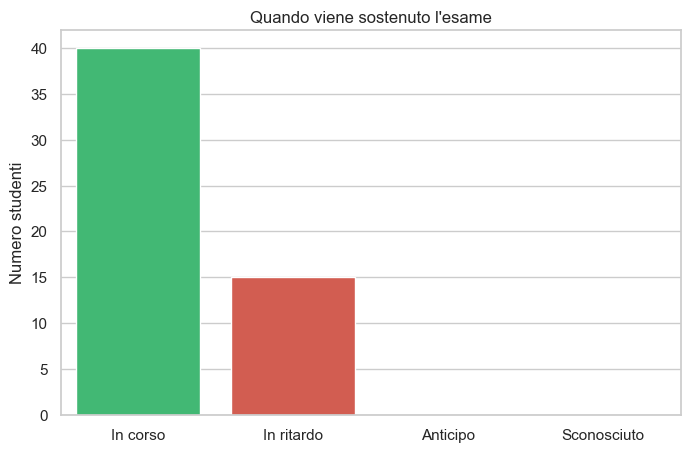

In [179]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    data=df_finale,
    x="Stato",
    order=["In corso","In ritardo","Anticipo","Sconosciuto"],
    palette=["#2ECC71","#E74C3C","#3498DB","#95A5A6"]
)

plt.title("Quando viene sostenuto l'esame")
plt.ylabel("Numero studenti")
plt.xlabel("")

plt.show()

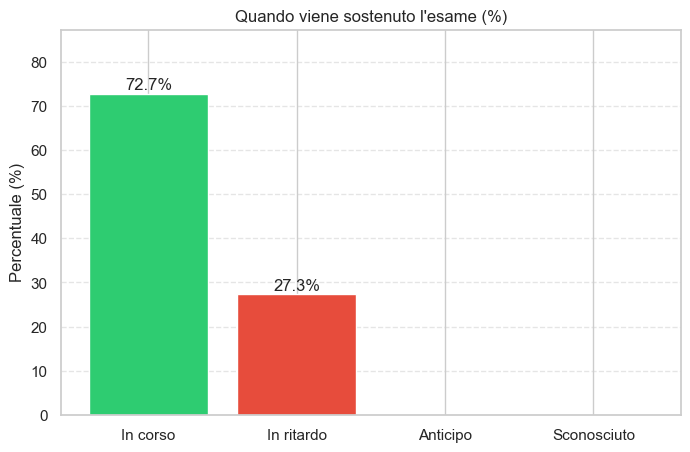

In [180]:
import matplotlib.pyplot as plt

# --- Conteggi ---
counts = df_finale["Stato"].value_counts().reindex(
    ["In corso","In ritardo","Anticipo","Sconosciuto"]
).fillna(0)

# --- Percentuali ---
percentuali = (counts / counts.sum()) * 100

# --- Grafico ---
plt.figure(figsize=(8,5))

bars = plt.bar(
    percentuali.index,
    percentuali.values,
    color=["#2ECC71","#E74C3C","#3498DB","#95A5A6"]
)

plt.title("Quando viene sostenuto l'esame (%)")
plt.ylabel("Percentuale (%)")

# --- Etichette sopra le barre ---
for bar, val in zip(bars, percentuali.values):
    if val > 0:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{val:.1f}%",
            ha='center'
        )

plt.ylim(0, max(percentuali.values)*1.2)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

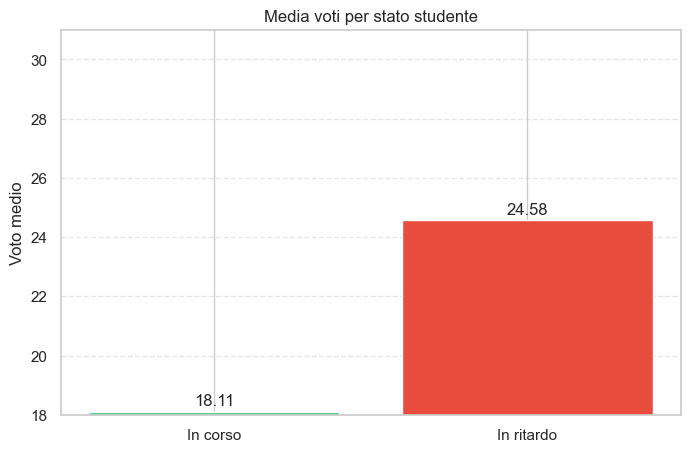

In [181]:
import matplotlib.pyplot as plt

# Filtra solo voti validi
df_validi = df_finale[df_finale["Voto_num"].notna()]

# Media voti
media_voti = df_validi.groupby("Stato")["Voto_num"].mean().reindex(
    ["In corso","In ritardo","Anticipo"]
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    media_voti.index,
    media_voti.values,
    color=["#2ECC71","#E74C3C","#3498DB"]
)

plt.title("Media voti per stato studente")
plt.ylabel("Voto medio")

# Etichette sopra
for bar, val in zip(bars, media_voti.values):
    if not pd.isna(val):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.2,
            f"{val:.2f}",
            ha='center'
        )

plt.ylim(18, 31)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

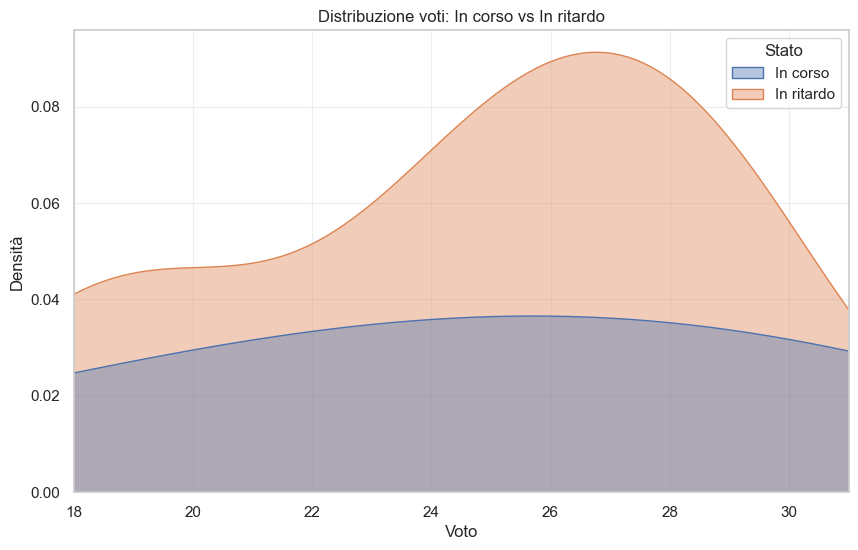

In [182]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df_validi[df_validi["Stato"].isin(["In corso","In ritardo"])],
    x="Voto_num",
    hue="Stato",
    fill=True,
    alpha=0.4,
    common_norm=False
)

plt.title("Distribuzione voti: In corso vs In ritardo")
plt.xlabel("Voto")
plt.ylabel("Densità")

plt.xlim(18,31)
plt.grid(alpha=0.3)

plt.show()

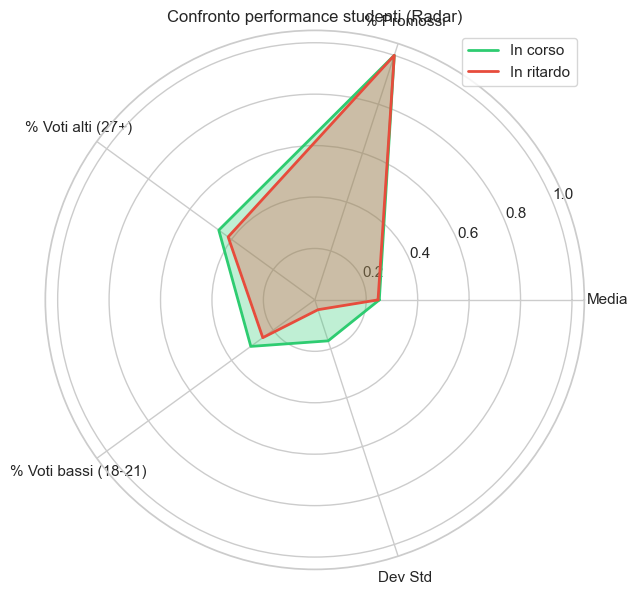

In [183]:
import numpy as np
import matplotlib.pyplot as plt

# --- Filtra voti validi ---
df_validi = df_finale[df_finale["Voto_num"].notna()]

# --- Funzione metriche ---
def calcola_metriche(df):
    voti = df["Voto_num"]
    
    return {
        "Media": voti.mean(),
        "% Promossi": (voti >= 18).mean()*100,
        "% Voti alti (27+)": (voti >= 27).mean()*100,
        "% Voti bassi (18-21)": ((voti >= 18) & (voti <= 21)).mean()*100,
        "Dev Std": voti.std()
    }

metriche_in_corso = calcola_metriche(df_validi[df_validi["Stato"]=="In corso"])
metriche_ritardo = calcola_metriche(df_validi[df_validi["Stato"]=="In ritardo"])

# --- Normalizzazione (importantissimo per radar) ---
def normalizza(diz):
    vals = np.array(list(diz.values()))
    return vals / vals.max()

vals1 = normalizza(metriche_in_corso)
vals2 = normalizza(metriche_ritardo)

labels = list(metriche_in_corso.keys())

# --- Radar setup ---
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.concatenate([angles, [angles[0]]])

vals1 = np.concatenate([vals1, [vals1[0]]])
vals2 = np.concatenate([vals2, [vals2[0]]])

# --- Plot ---
plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

ax.plot(angles, vals1, label="In corso", color="#2ECC71", linewidth=2)
ax.fill(angles, vals1, alpha=0.3, color="#2ECC71")

ax.plot(angles, vals2, label="In ritardo", color="#E74C3C", linewidth=2)
ax.fill(angles, vals2, alpha=0.3, color="#E74C3C")

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Confronto performance studenti (Radar)")
plt.legend(loc="upper right")

plt.show()

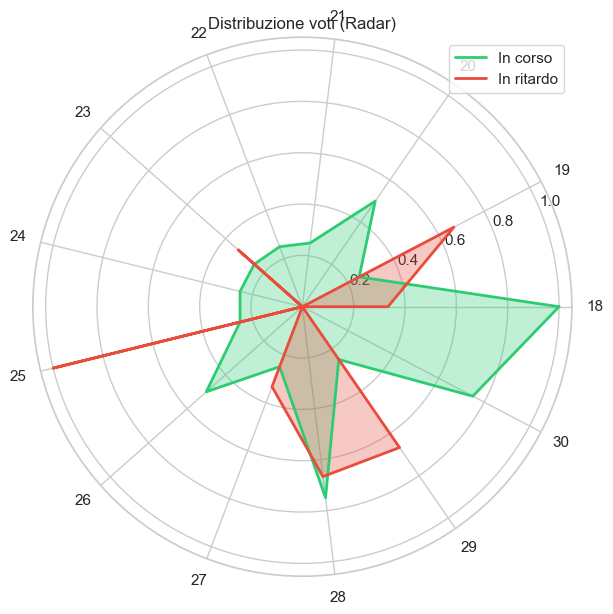

In [184]:
import numpy as np
import matplotlib.pyplot as plt

# --- Filtra voti validi ---
df_validi = df_finale[df_finale["Voto_num"].notna()]

# Range voti
voti_range = np.arange(18,31)

# Conteggi
def distribuzione(df):
    counts = df["Voto_num"].value_counts().sort_index()
    return np.array([counts.get(v, 0) for v in voti_range])

dist_in_corso = distribuzione(df_validi[df_validi["Stato"]=="In corso"])
dist_ritardo = distribuzione(df_validi[df_validi["Stato"]=="In ritardo"])

# --- Normalizzazione per confronto visivo ---
def norm(x):
    return x / x.max() if x.max() > 0 else x

dist_in_corso = norm(dist_in_corso)
dist_ritardo = norm(dist_ritardo)

# --- Setup radar ---
labels = voti_range.astype(str)
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.concatenate([angles, [angles[0]]])

dist_in_corso = np.concatenate([dist_in_corso, [dist_in_corso[0]]])
dist_ritardo = np.concatenate([dist_ritardo, [dist_ritardo[0]]])

# --- Plot ---
plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

ax.plot(angles, dist_in_corso, label="In corso", color="#2ECC71", linewidth=2)
ax.fill(angles, dist_in_corso, alpha=0.3, color="#2ECC71")

ax.plot(angles, dist_ritardo, label="In ritardo", color="#E74C3C", linewidth=2)
ax.fill(angles, dist_ritardo, alpha=0.3, color="#E74C3C")

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Distribuzione voti (Radar)")
plt.legend(loc="upper right")
plt.show()

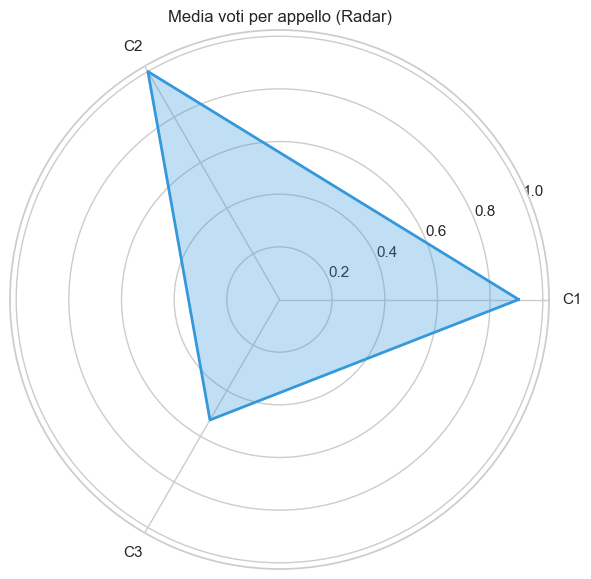

In [185]:
# --- Media per appello ---
media_appelli = df_validi.groupby("Appello")["Voto_num"].mean()

labels = media_appelli.index.tolist()
values = media_appelli.values

# Normalizzazione per radar
values_norm = values / values.max()

# Chiusura cerchio
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.concatenate([angles, [angles[0]]])
values_norm = np.concatenate([values_norm, [values_norm[0]]])

# --- Plot ---
plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

ax.plot(angles, values_norm, color="#3498DB", linewidth=2)
ax.fill(angles, values_norm, alpha=0.3, color="#3498DB")

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Media voti per appello (Radar)")
plt.show()


Conteggio generi grezzi:
Genere
U    45
F     5
M     5
Name: count, dtype: int64

M=5, F=5, U=45

Conteggio generi finale:
Genere
F    28
M    27
Name: count, dtype: int64

Distribuzione M: [3 3 2 1 2 1 0 0 1 1 3 2 0 2 1 3 0]
Distribuzione F: [0 1 8 4 1 1 1 1 1 0 1 0 2 3 2 0 0]


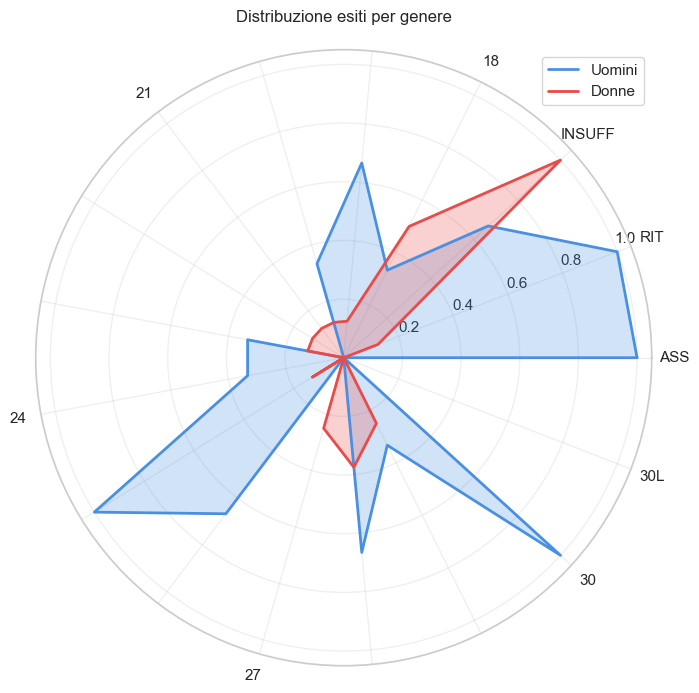

In [191]:
import gender_guesser.detector as gender
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

# --- 1️⃣ Normalizza nome ---
def normalize_name(nome):
    if not isinstance(nome, str) or nome.strip() == "":
        return ""
    nome = nome.strip().split()[0]
    nome = re.sub(r"[^A-Za-zÀ-ÖØ-öø-ÿ]", "", nome)
    return nome.capitalize()

df_tmp = df_finale.copy()
df_tmp["Nome_norm"] = df_tmp["Nome"].apply(normalize_name)

# --- 2️⃣ Gender detection ---
d = gender.Detector()

def get_gender(nome):
    g = d.get_gender(nome)
    if g in ["male", "mostly_male"]:
        return "M"
    elif g in ["female", "mostly_female"]:
        return "F"
    else:
        return "U"  # unknown

df_tmp["Genere"] = df_tmp["Nome_norm"].apply(get_gender)

# --- DEBUG ---
print("\nConteggio generi grezzi:")
print(df_tmp["Genere"].value_counts())

# --- 3️⃣ Gestione UNKNOWN intelligente ---
counts = df_tmp["Genere"].value_counts()
m = counts.get("M", 0)
f = counts.get("F", 0)
u = counts.get("U", 0)

print(f"\nM={m}, F={f}, U={u}")

if u > 0:
    if abs(m - f) > 0.2 * (m + f):  # maggioranza netta
        if m > f:
            df_tmp.loc[df_tmp["Genere"]=="U","Genere"] = "M"
        else:
            df_tmp.loc[df_tmp["Genere"]=="U","Genere"] = "F"
    else:
        # metà e metà
        idx_u = df_tmp[df_tmp["Genere"]=="U"].index
        metà = len(idx_u)//2
        df_tmp.loc[idx_u[:metà],"Genere"] = "M"
        df_tmp.loc[idx_u[metà:],"Genere"] = "F"

print("\nConteggio generi finale:")
print(df_tmp["Genere"].value_counts())

# --- 4️⃣ CATEGORIZZAZIONE ESITI ---
def categorizza_esito(v):
    if pd.isna(v):
        return "ASS"
    
    v_str = str(v).strip().upper()
    
    if v_str == "RIT":
        return "RIT"
    elif v_str == "ASS":
        return "ASS"
    elif v_str == "30L":
        return "30L"
    
    try:
        voto = float(v_str)
        if voto < 18:
            return "INSUFF"
        else:
            return str(int(voto))
    except:
        return "ASS"

df_tmp["Categoria"] = df_tmp["Voto"].apply(categorizza_esito)

# --- 5️⃣ Categorie ordinate ---
categorie = ["ASS", "RIT", "INSUFF"] + [str(i) for i in range(18,31)] + ["30L"]

# --- 6️⃣ Distribuzioni ---
def distribuzione(df):
    counts = df["Categoria"].value_counts()
    return np.array([counts.get(c, 0) for c in categorie])

dist_M = distribuzione(df_tmp[df_tmp["Genere"]=="M"])
dist_F = distribuzione(df_tmp[df_tmp["Genere"]=="F"])

# --- DEBUG ---
print("\nDistribuzione M:", dist_M)
print("Distribuzione F:", dist_F)

# --- 7️⃣ Normalizzazione ---
def norm(x):
    return x / x.max() if x.max() > 0 else x

dist_M = norm(dist_M)
dist_F = norm(dist_F)

# --- 8️⃣ Radar ---
angles = np.linspace(0, 2*np.pi, len(categorie), endpoint=False)

angles = np.concatenate([angles, [angles[0]]])
dist_M = np.concatenate([dist_M, [dist_M[0]]])
dist_F = np.concatenate([dist_F, [dist_F[0]]])

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

ax.plot(angles, dist_M, color="#4A90E2", linewidth=2, label="Uomini")
ax.fill(angles, dist_M, alpha=0.25, color="#4A90E2")

ax.plot(angles, dist_F, color="#E94A4A", linewidth=2, label="Donne")
ax.fill(angles, dist_F, alpha=0.25, color="#E94A4A")

# Etichette pulite
etichette_visive = []
for c in categorie:
    if c in ["ASS","RIT","INSUFF","18","21","24","27","30","30L"]:
        etichette_visive.append(c)
    else:
        etichette_visive.append("")

ax.set_xticks(angles[:-1])
ax.set_xticklabels(etichette_visive)

ax.set_title("Distribuzione esiti per genere", pad=20)
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

plt.show()

In [192]:
df_finale.columns

Index(['Matricola', 'Nome', 'AnnoFreq', 'Voto', 'Anno_appello', 'Nome_norm',
       'Voto_num', 'Appello', 'Anno_inizio', 'Diff_anni', 'Stato'],
      dtype='object')

In [ ]:
df_finale.columns

Index(['Matricola', 'Nome', 'AnnoFreq', 'Voto', 'Anno_appello', 'Nome_norm',
       'Voto_num', 'Appello', 'Anno_inizio', 'Diff_anni', 'Stato'],
      dtype='object')